In [2]:
import os
from datetime import datetime
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F


In [3]:
df = pd.read_csv(f'BTCUSDT-15m-data.csv')
print(df.head())

             timestamp      open_time     open     high      low    close  \
0  2017-08-17 04:00:00  1502942400000  4261.48  4280.56  4261.48  4261.48   
1  2017-08-17 04:15:00  1502943300000  4261.48  4270.41  4261.32  4261.45   
2  2017-08-17 04:30:00  1502944200000  4280.00  4310.07  4267.99  4310.07   
3  2017-08-17 04:45:00  1502945100000  4310.07  4313.62  4291.37  4308.83   
4  2017-08-17 05:00:00  1502946000000  4308.83  4328.69  4304.31  4304.31   

      volume     close_time      quote_av  trades  tb_base_av   tb_quote_av  \
0   2.189061  1502943299999   9333.620962       9    0.489061   2089.104962   
1   9.119865  1502944199999  38891.133046      40    3.447113  14703.934995   
2  21.923552  1502945099999  94080.917568      58   20.421317  87620.977876   
3  13.948531  1502945999999  60060.466816      64   10.803012  46538.460109   
4   5.101153  1502946899999  22006.533111      44    3.496635  15093.783057   

   ignore  
0       0  
1       0  
2       0  
3       0  
4 

In [4]:
df.describe()

df.count()

,0
timestamp,276000
open_time,276000
open,276000
high,276000
low,276000
close,276000
volume,276000
close_time,276000
quote_av,276000
trades,276000


In [5]:
df.tail()

,timestamp,open_time,open,high,low,close,volume,close_time,quote_av,trades,tb_base_av,tb_quote_av,ignore
275995,2025-07-07 00:00:00,1751846400000,109203.85,109273.07,109103.19,109273.06,56.48447,1751847299999,6.166301e+06,26415,26.22332,2.862917e+06,0
275996,2025-07-07 00:15:00,1751847300000,109273.07,109288.02,108972.69,109004.81,75.36437,1751848199999,8.220317e+06,24191,33.56157,3.660548e+06,0
275997,2025-07-07 00:30:00,1751848200000,109004.81,109037.82,108829.17,108847.16,76.72080,1751849099999,8.357724e+06,21368,33.08997,3.605029e+06,0
275998,2025-07-07 00:45:00,1751849100000,108847.17,108922.00,108800.01,108823.07,45.06548,1751849999999,4.906468e+06,15579,22.76836,2.478881e+06,0
275999,2025-07-07 01:00:00,1751850000000,108823.07,108823.08,108679.75,108767.01,75.71845,1751850899999,8.232864e+06,22928,38.85713,4.224608e+06,0


In [6]:
print(df.isnull())
print(f'Counts how many missing values there are in each column: {df.isnull().sum()}')
print(f'Total missing values: {df.isnull().sum().sum()}')

        timestamp  open_time   open   high    low  close  volume  close_time  \
0           False      False  False  False  False  False   False       False   
1           False      False  False  False  False  False   False       False   
2           False      False  False  False  False  False   False       False   
3           False      False  False  False  False  False   False       False   
4           False      False  False  False  False  False   False       False   
...           ...        ...    ...    ...    ...    ...     ...         ...   
275995      False      False  False  False  False  False   False       False   
275996      False      False  False  False  False  False   False       False   
275997      False      False  False  False  False  False   False       False   
275998      False      False  False  False  False  False   False       False   
275999      False      False  False  False  False  False   False       False   

        quote_av  trades  tb_base_av  t

#Training Phase

Splitting data to train/test sets

Practice same pattersn multiple times

Have access to answer key

problems known:
Overfitting
Underfitting

#Testing Phase

Face new Patterns

No access to asnwer key


In [7]:
train_end_idx = 240_000

df_train = df.iloc[:train_end_idx].copy()

df_test = df.iloc[train_end_idx:].copy()

df_test.reset_index(drop=True, inplace=True)

# Instead o preprocessing the data set first
# we split it and then preprocess
# this way we can ensure the test data do not leak into the training data

print(f'Length of training set: {len(df_train)}')
print(f'Length of testing set: {len(df_test)}')

Length of training set: 240000
Length of testing set: 36000


In [8]:
# what is a feature:
# a Mesurable piece of information that describe the data
# help the model to recognize patterns

#always pay attention to the shape of the data

def build_feature(opens, closes):
  fearure1 = (closes - opens) / opens

  features = np.stack([
      fearure1,
  ], axis=-1) # shape: (time_steps, num_features)

  num_features = features.shape[-1] # shape -1: means last dimentsion of the features array that correxpond to the n of features

  return features, num_features

In [9]:
def preprocessing_data(seq_len, df):
  m =len(df)

  opens = np.array(df['open'].values)
  closes = np.array(df['close'].values)

  features, num_features = build_feature(opens, closes)



  # calculate number of samples
  num_samples = m - seq_len

  #create storage for input & targets
  # x the input sequence
  # y the output/target
  X = np.zeros([num_samples, seq_len, num_features], dtype=np.float32)
  Y = np.zeros([num_samples, num_features], dtype=np.float32)

  for i in range(num_samples):
    X[i] = features[i:i+seq_len]
    Y[i] = features[i+seq_len : i+seq_len+1]

  return X, Y, num_features

In [10]:
from re import X
# Sequence Lenght fot the inout sequence equivalent 1 day of 15m candles
seq_len = 96

# Processing data
X_train, Y_train, num_features = preprocessing_data(seq_len, df_train)
X_test, Y_test, num_features = preprocessing_data(seq_len, df_test)

m_train = X_train.shape[0]
m_test = X_test.shape[0]


print(f'Number of training samples (m_train): {m_train}')
print(f'Number of testing samples (m_test): {m_test}')
print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')

Number of training samples (m_train): 239904
Number of testing samples (m_test): 35904
X_train shape: (239904, 96, 1)
Y_train shape: (239904, 1)
X_test shape: (35904, 96, 1)
Y_test shape: (35904, 1)


In [11]:
# pytorch models can only work with tensors

# pytorch and tensorFlow

#what is a tensor: a similar to a numpy array, but it can be on a cpu

# pytorch works best with float 32

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("my device: ", device)

X_train = torch.from_numpy(X_train.astype(np.float32)).to(device, dtype=torch.float32)
Y_train = torch.from_numpy(Y_train.astype(np.float32)).to(device, dtype=torch.float32)

X_test = torch.from_numpy(X_test.astype(np.float32)).to(device, dtype=torch.float32)
Y_test = torch.from_numpy(Y_test.astype(np.float32)).to(device, dtype=torch.float32)

Y_pred_test = torch.zeros([m_test, num_features], device=device, dtype=torch.float32)


my device:  cpu


In [12]:
import numpy as np

#dot product caluculation
x = 82
W_h1 = 0.35
b_h1 = 52

W_h2 = 0.68
b_h2 = 12

W_out = [0.75, 0.46]
b_out = 37

h1 = x * W_h1 + b_h1
h2 = x * W_h2 + b_h2
H = [h1, h2]

Y_hat = np.dot(H, W_out) + b_out
print(f'Prediction: {Y_hat}')



Prediction: 128.6946


In [13]:
class Model(nn.Module):
    def __init__(self):
       super().__init__()

       #work station 1:
       # fc stand to fully connect layer typically linear
       self.fc1 = nn.Linear(in_features=seq_len * num_features, out_features = 20)

       self.act1 = nn.ReLU()

       #word station 2:
       self.fc2 = nn.Linear(in_features=20, out_features = 40)

       self.act2 = nn.ReLU()

       #Head Manager:
       self.fe_out = nn.Linear(in_features=40, out_features = num_features)


    def forward(self, x):
        # x shape: (batch_size, seq_len, num_features)
        x = x.reshape(-1, seq_len*num_features)

        # Pass to Workstation 1
        x = self.fc1(x)
        x = self.act1(x)

        # Pass to Workstation 2
        x = self.fc2(x)
        x = self.act2(x)

        # Get final output
        x = self.fe_out(x)

        return x

In [14]:
# Initialize model
model = Model()

# Transfer model to device
model.to(device)

# Initialize criterion (convention name for loss function)
# Mean Square Error
criterion = nn.MSELoss()

# Choose learning rate
lr = 1e-4

# Create optimizer
# Adam optmizer \ lr = learming rate
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Choose batch size
# 32 stable and nice speed
batch_size = 32

# Lists of train/test losses
train_losses = []
test_losses = []

# Set epoch
num_epochs = 200

In [15]:
def create_minibatches(X, Y, batch_size, shuffle=True):
    mini_batches = []
    m = len(X)

    if shuffle:
        permutation = list(np.random.permutation(m))
        X = X[permutation]
        Y = Y[permutation]

    num_batches = m // batch_size

    for k in range(num_batches):
        mb_X = X[k * batch_size : k * batch_size + batch_size]
        mb_Y = Y[k * batch_size : k * batch_size + batch_size]
        mb_pair = (mb_X, mb_Y)
        mini_batches.append(mb_pair)

    return mini_batches

Epoch: 0, train_losses: 9.074993072405995e-05, test_losses: 7.328242645598948e-06, Duration: 0:00:12.059369


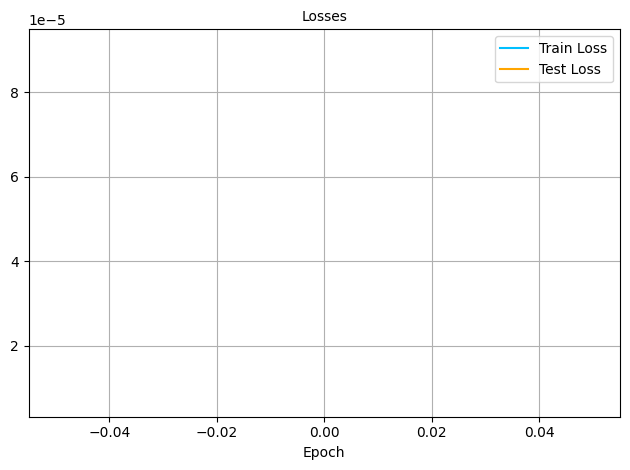

Epoch: 1, train_losses: 1.8604792924811236e-05, test_losses: 7.2840216489566956e-06, Duration: 0:00:12.320358


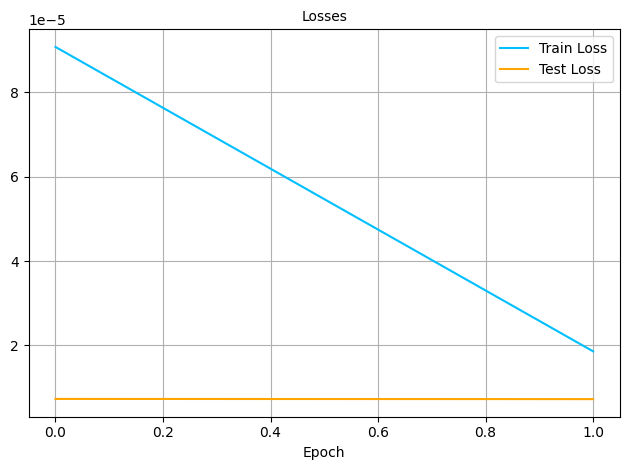

Epoch: 2, train_losses: 1.8576940740626437e-05, test_losses: 8.673167940287385e-06, Duration: 0:00:11.442357


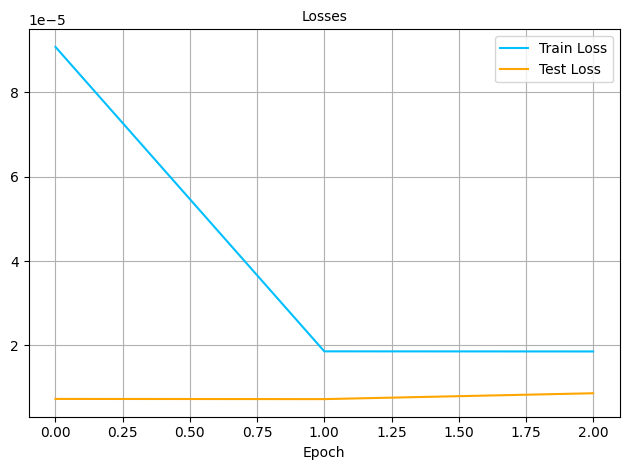

Epoch: 3, train_losses: 1.855374593432386e-05, test_losses: 7.292510417755693e-06, Duration: 0:00:10.464787


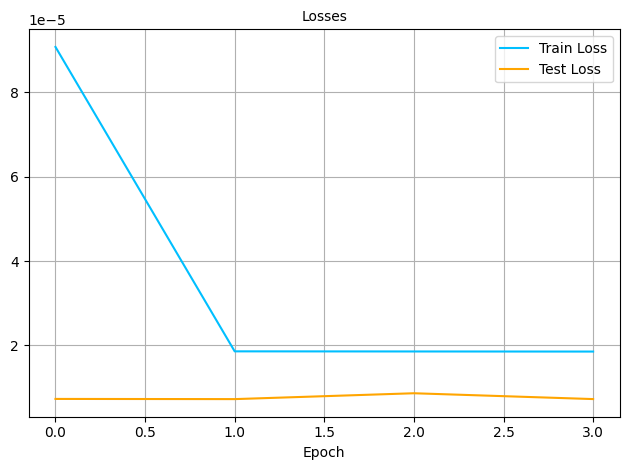

Epoch: 4, train_losses: 1.8535460873562747e-05, test_losses: 7.285636911547044e-06, Duration: 0:00:11.238730


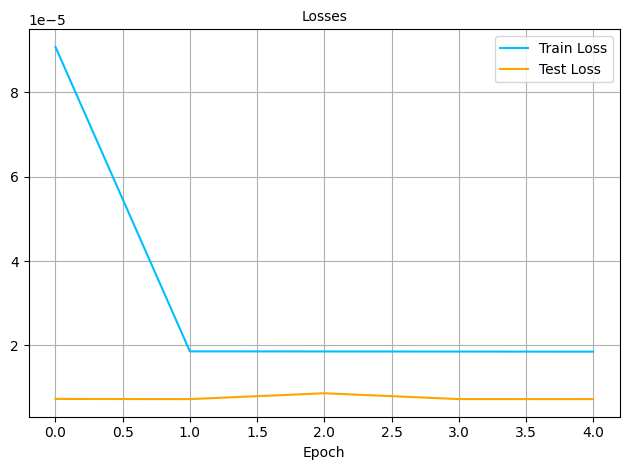

Epoch: 5, train_losses: 1.8509722684418532e-05, test_losses: 7.329410891543375e-06, Duration: 0:00:11.737130


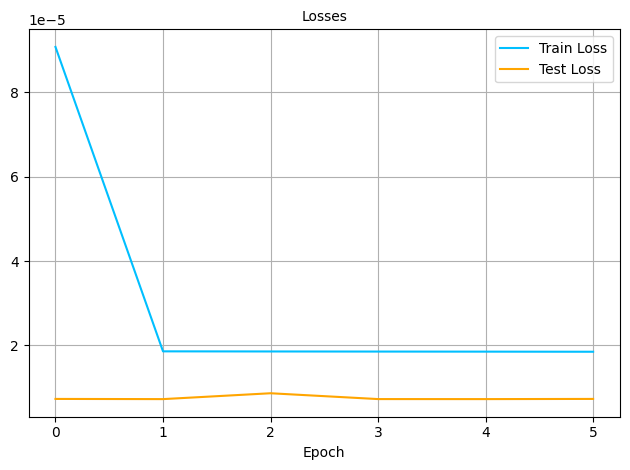

Epoch: 6, train_losses: 1.848638304569465e-05, test_losses: 7.317484687519027e-06, Duration: 0:00:14.125949


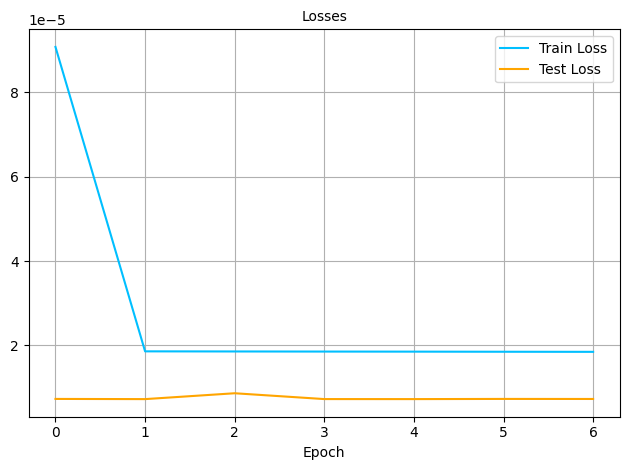

Epoch: 7, train_losses: 1.844210646828987e-05, test_losses: 7.3351015998923685e-06, Duration: 0:00:13.505263


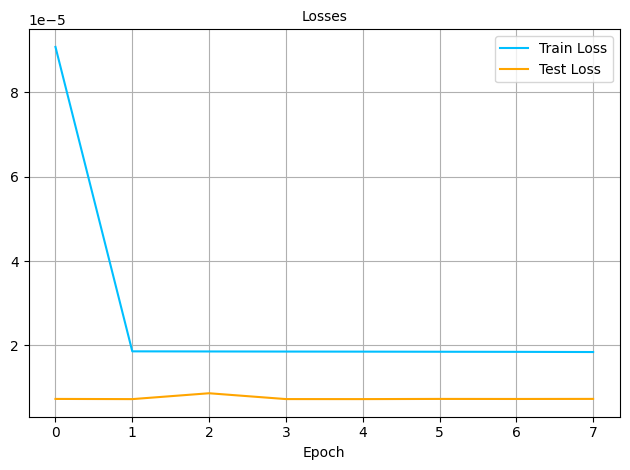

Epoch: 8, train_losses: 1.840921690618595e-05, test_losses: 7.538406407547882e-06, Duration: 0:00:10.902579


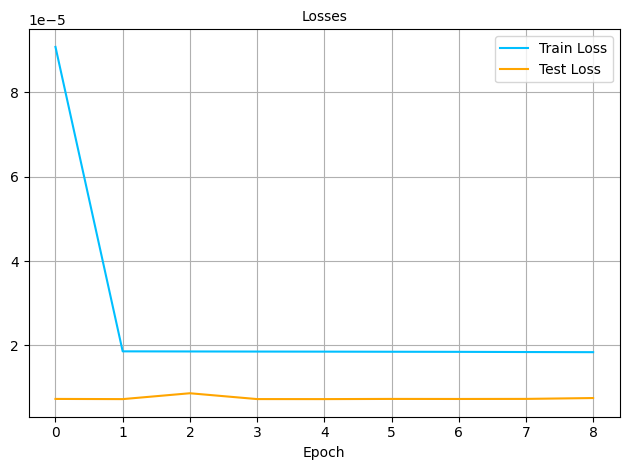

Epoch: 9, train_losses: 1.837611184765585e-05, test_losses: 7.69107100495603e-06, Duration: 0:00:11.497567


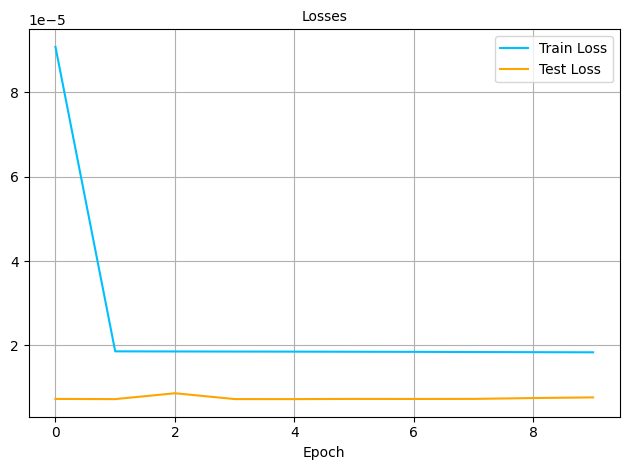

Epoch: 10, train_losses: 1.834009906817483e-05, test_losses: 7.762758286844473e-06, Duration: 0:00:12.003556


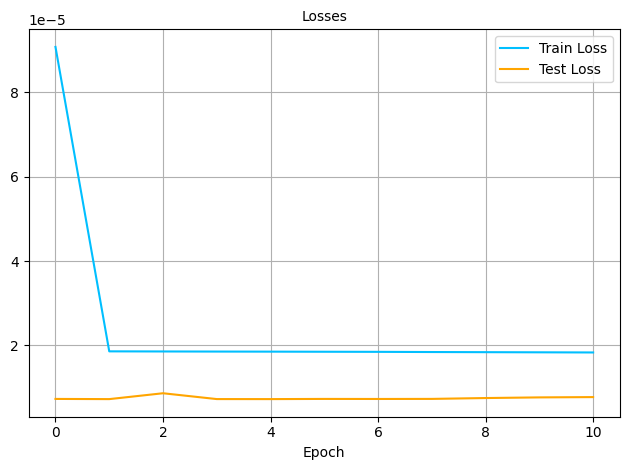

Epoch: 11, train_losses: 1.830584298336657e-05, test_losses: 7.33610249881167e-06, Duration: 0:00:12.210690


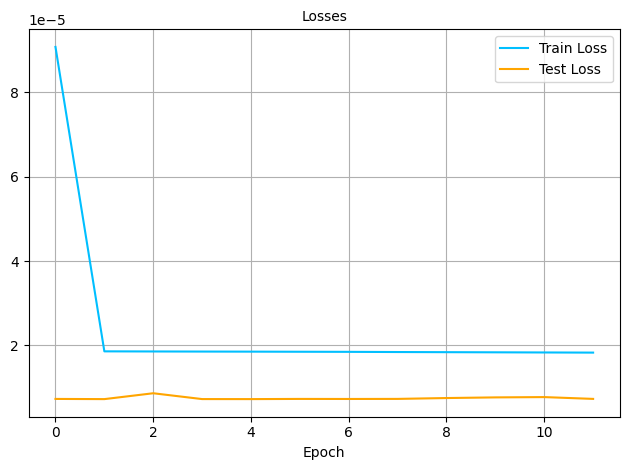

Epoch: 12, train_losses: 1.8266924380748122e-05, test_losses: 7.329079380724579e-06, Duration: 0:00:11.581554


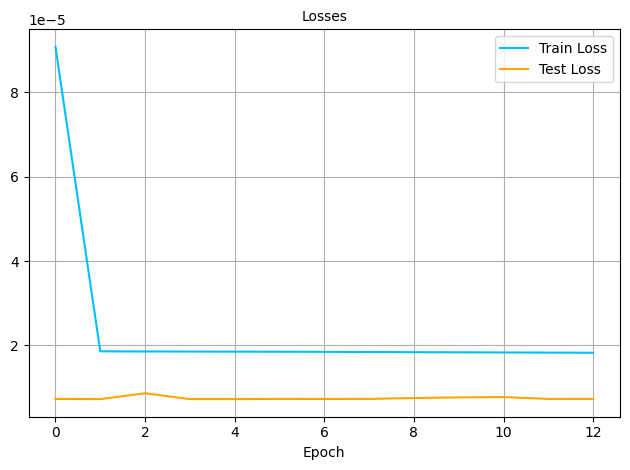

Epoch: 13, train_losses: 1.8217390591914185e-05, test_losses: 7.399657533824211e-06, Duration: 0:00:14.526510


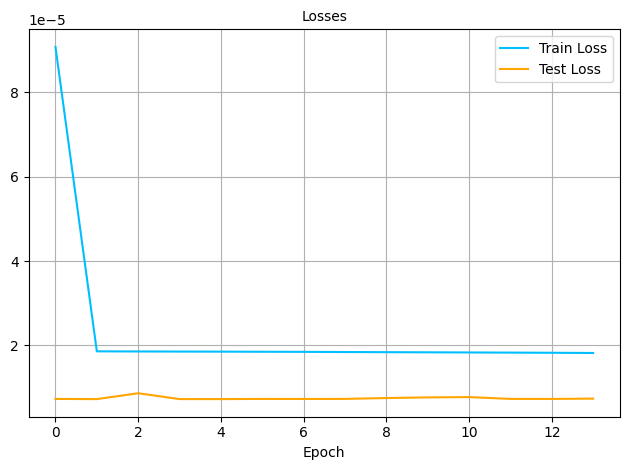

Epoch: 14, train_losses: 1.8188126652600475e-05, test_losses: 7.778549843351357e-06, Duration: 0:00:14.773628


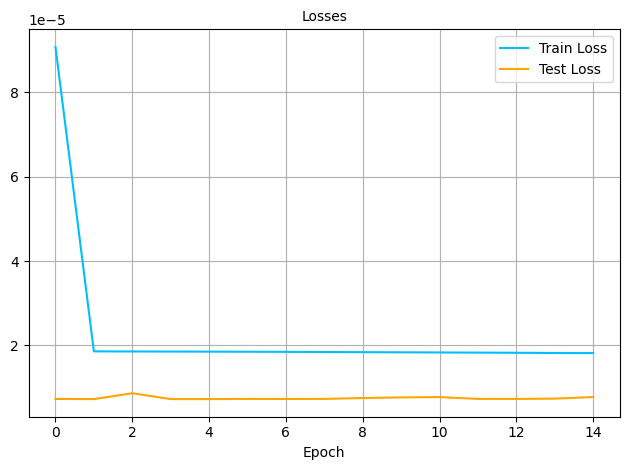

Epoch: 15, train_losses: 1.812259348238246e-05, test_losses: 7.3045089266088326e-06, Duration: 0:00:15.861003


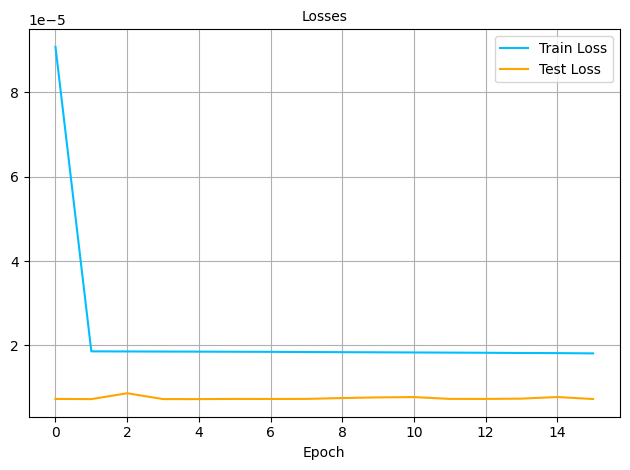

Epoch: 16, train_losses: 1.8081484926918325e-05, test_losses: 7.280954378074966e-06, Duration: 0:00:17.752401


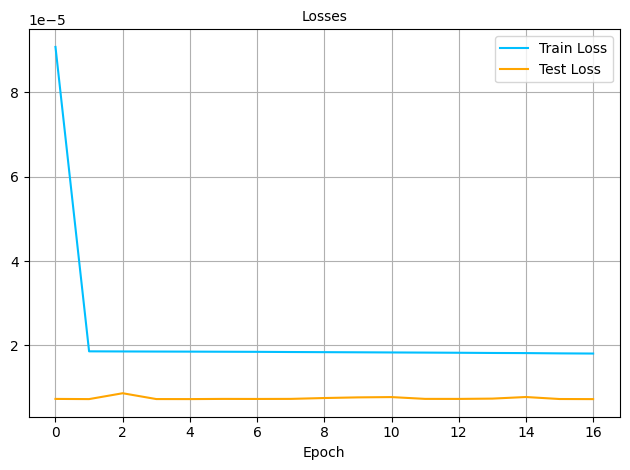

Epoch: 17, train_losses: 1.804437623992578e-05, test_losses: 8.133705705404282e-06, Duration: 0:00:14.105011


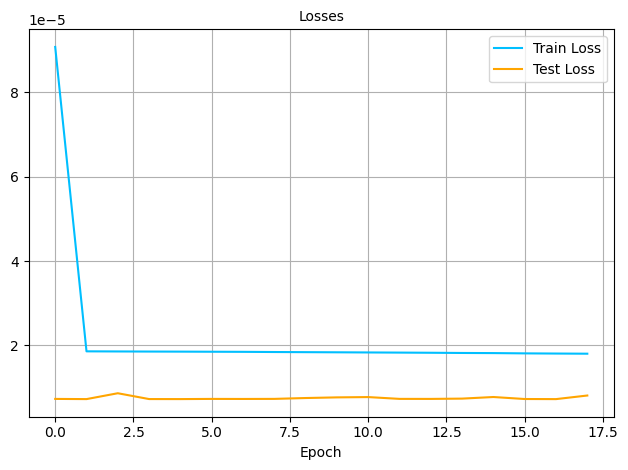

Epoch: 18, train_losses: 1.79850846490468e-05, test_losses: 7.340178399317665e-06, Duration: 0:00:12.311386


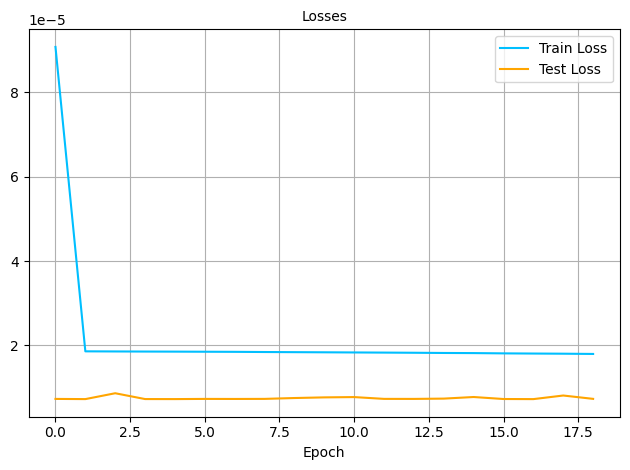

Epoch: 19, train_losses: 1.7933563344031142e-05, test_losses: 7.4144350037386175e-06, Duration: 0:00:12.556196


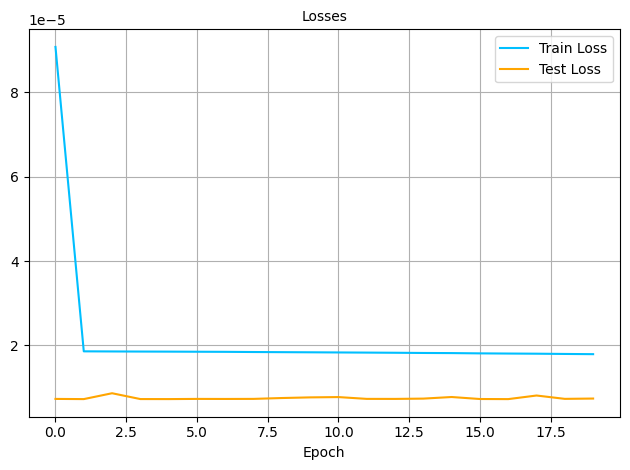

Epoch: 20, train_losses: 1.7883060031145868e-05, test_losses: 7.896337592683267e-06, Duration: 0:00:13.939812


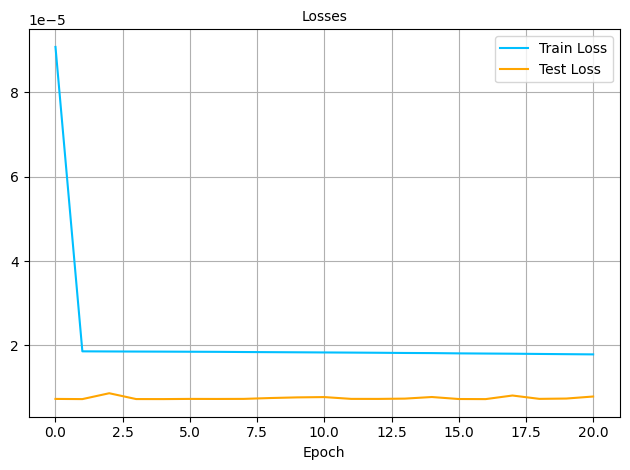

Epoch: 21, train_losses: 1.783072522116673e-05, test_losses: 7.290264420589665e-06, Duration: 0:00:13.462529


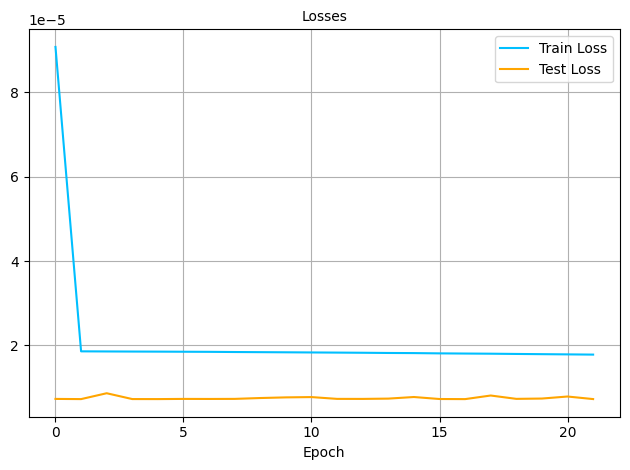

Epoch: 22, train_losses: 1.7782788088344173e-05, test_losses: 7.301628102140967e-06, Duration: 0:00:13.754222


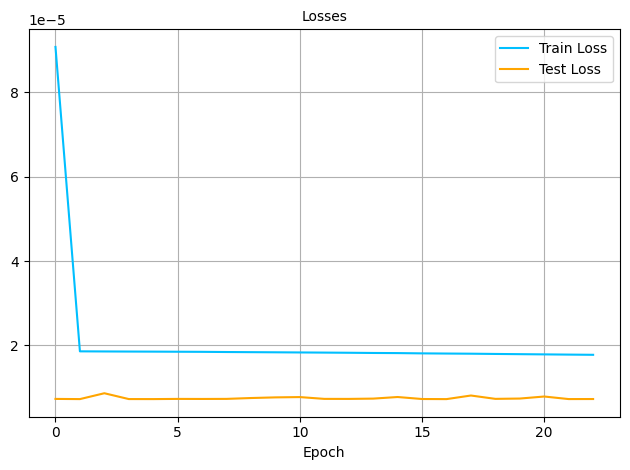

Epoch: 23, train_losses: 1.7740317259655334e-05, test_losses: 7.379905582638457e-06, Duration: 0:00:12.815092


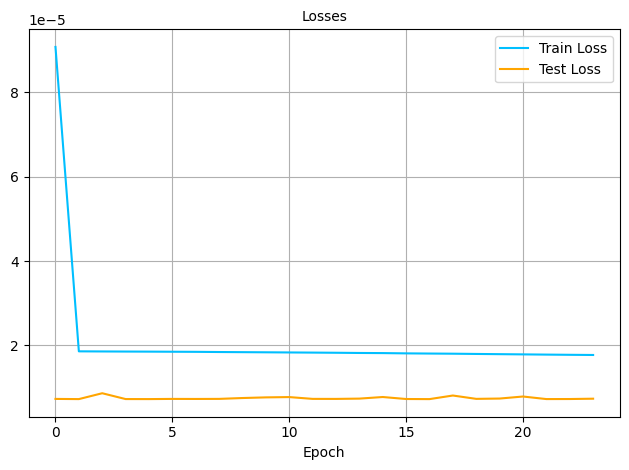

Epoch: 24, train_losses: 1.771486102372547e-05, test_losses: 7.4317863436590414e-06, Duration: 0:00:12.539851


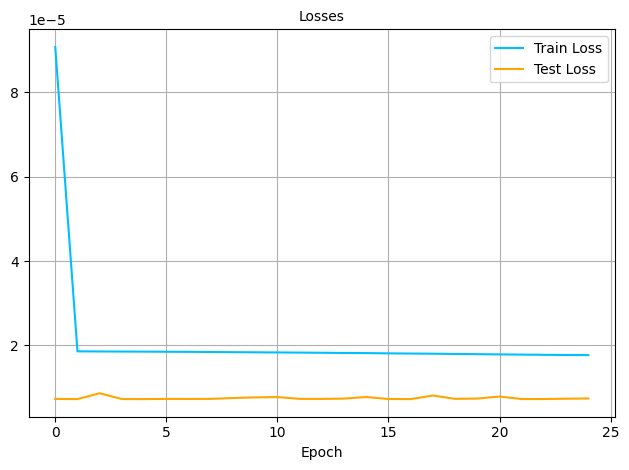

Epoch: 25, train_losses: 1.7666256143489845e-05, test_losses: 7.296270723600173e-06, Duration: 0:00:11.707093


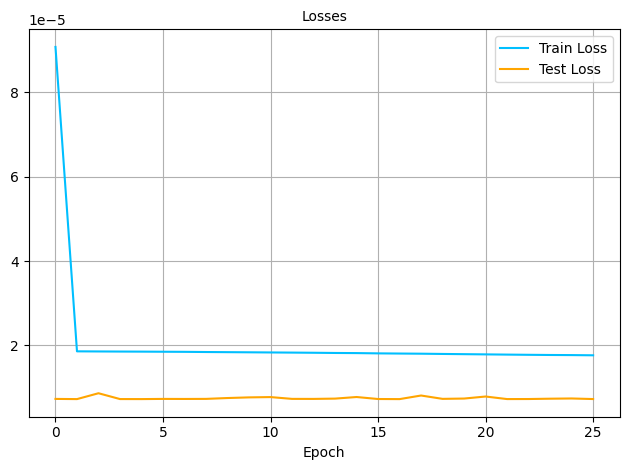

Epoch: 26, train_losses: 1.7641900179830236e-05, test_losses: 7.477246072085109e-06, Duration: 0:00:12.848013


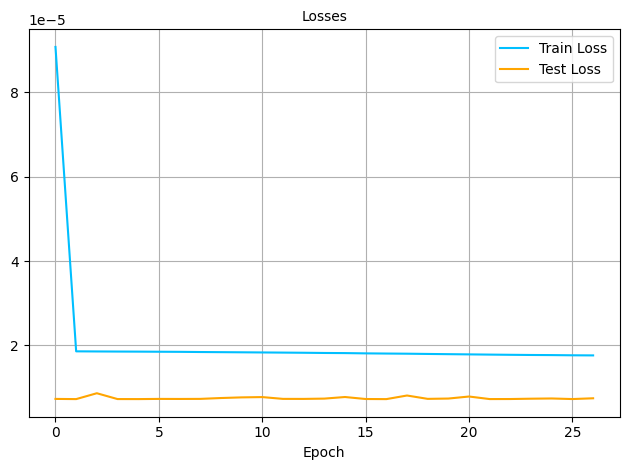

Epoch: 27, train_losses: 1.758951249719184e-05, test_losses: 7.328427727770759e-06, Duration: 0:00:12.639598


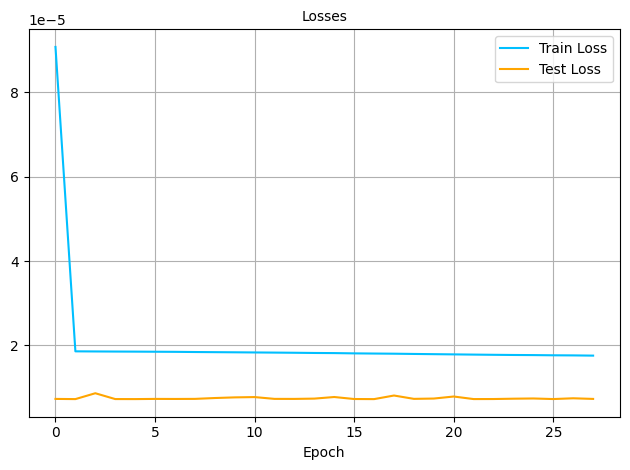

Epoch: 28, train_losses: 1.7553656131798646e-05, test_losses: 7.934185305202845e-06, Duration: 0:00:12.402021


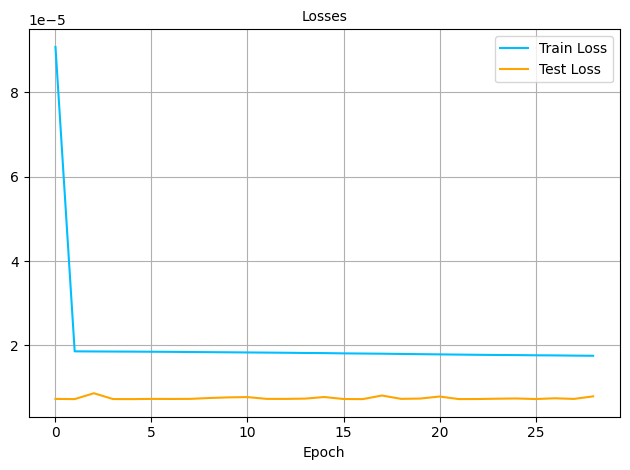

Epoch: 29, train_losses: 1.7534964304460564e-05, test_losses: 7.2717698458291125e-06, Duration: 0:00:15.091584


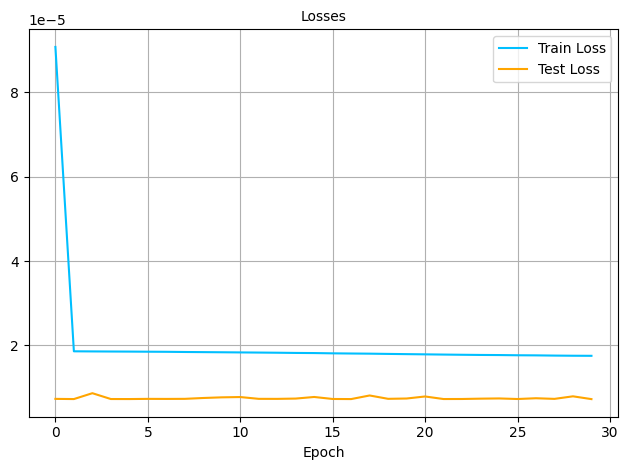

Epoch: 30, train_losses: 1.74869297223803e-05, test_losses: 7.2884076871559955e-06, Duration: 0:00:17.762228


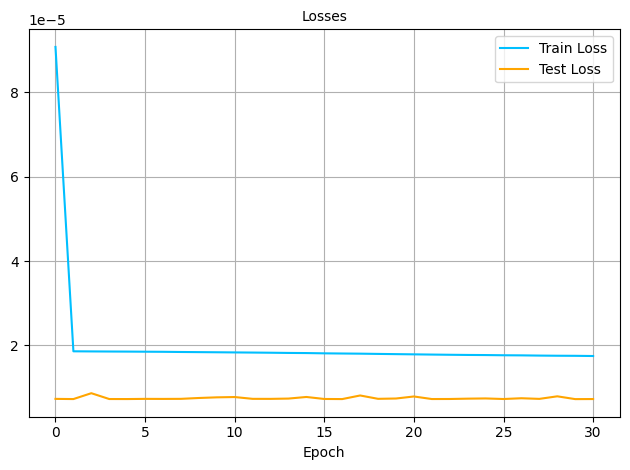

Epoch: 31, train_losses: 1.7450110572637855e-05, test_losses: 7.283502782229334e-06, Duration: 0:00:20.341005


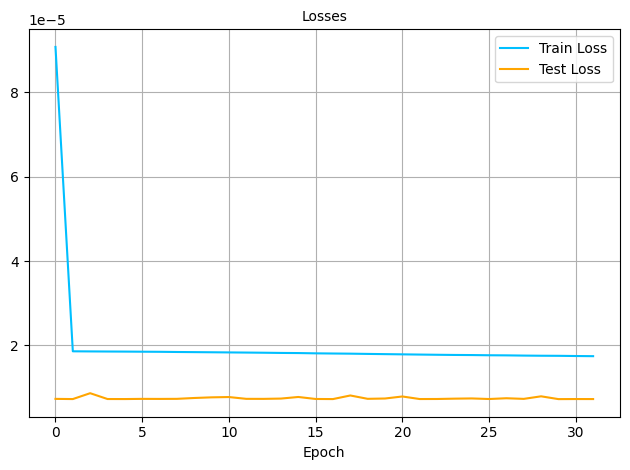

Epoch: 32, train_losses: 1.740261676886479e-05, test_losses: 7.3616051849967334e-06, Duration: 0:00:12.906515


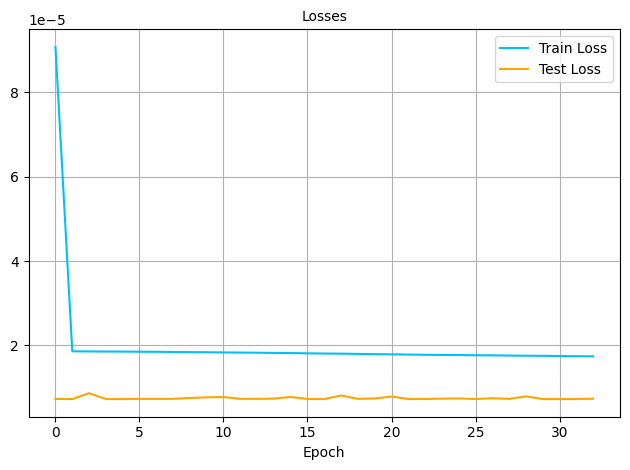

Epoch: 33, train_losses: 1.7375242074069027e-05, test_losses: 7.496578291465994e-06, Duration: 0:00:12.613278


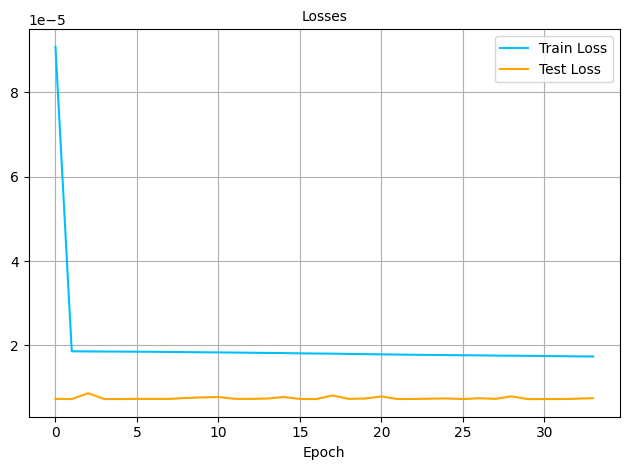

Epoch: 34, train_losses: 1.732350524828847e-05, test_losses: 7.294236183952307e-06, Duration: 0:00:10.991108


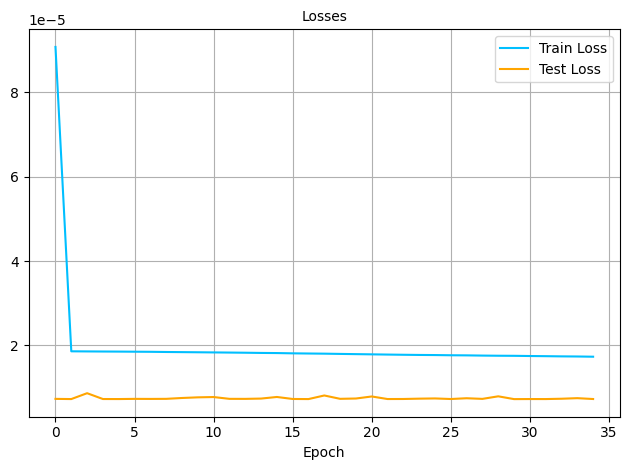

Epoch: 35, train_losses: 1.729360055183601e-05, test_losses: 7.609552994836122e-06, Duration: 0:00:10.573261


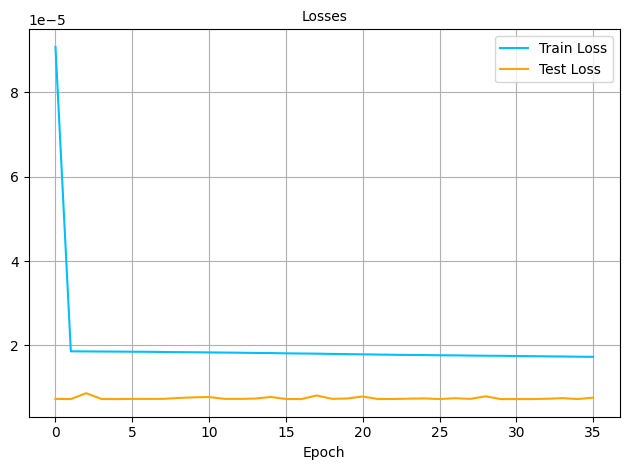

Epoch: 36, train_losses: 1.7253501614239107e-05, test_losses: 7.89758087194059e-06, Duration: 0:00:10.422690


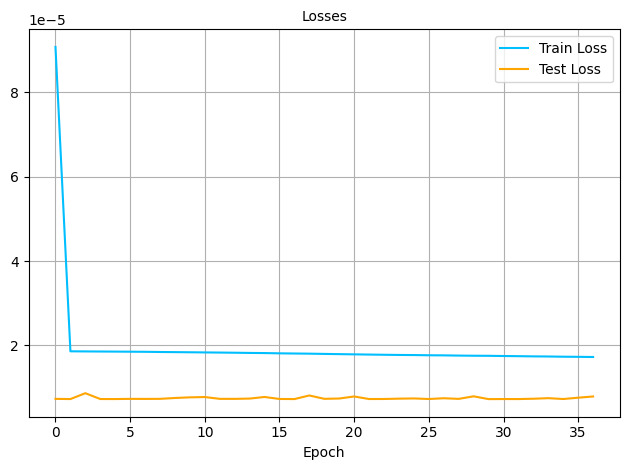

Epoch: 37, train_losses: 1.720850810774008e-05, test_losses: 7.294529495993629e-06, Duration: 0:00:10.397631


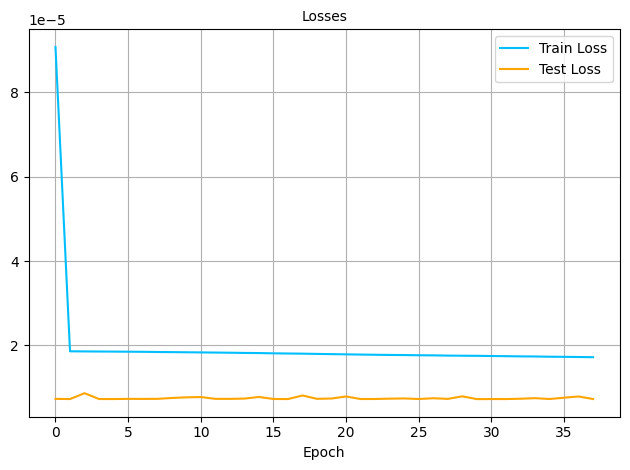

Epoch: 38, train_losses: 1.7178649175509403e-05, test_losses: 7.315310540434439e-06, Duration: 0:00:10.625051


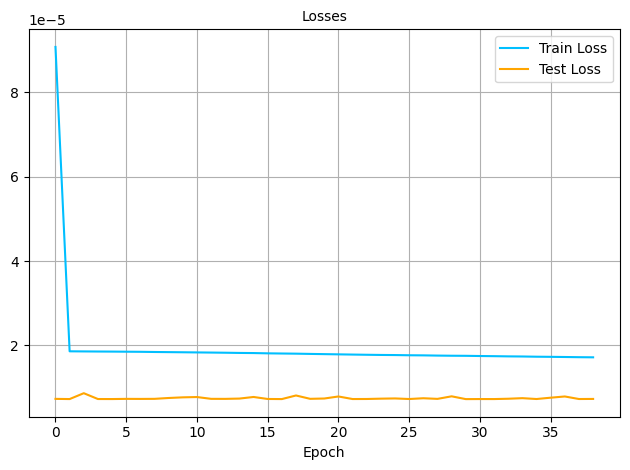

Epoch: 39, train_losses: 1.7131667937571263e-05, test_losses: 7.306598490686156e-06, Duration: 0:00:10.955183


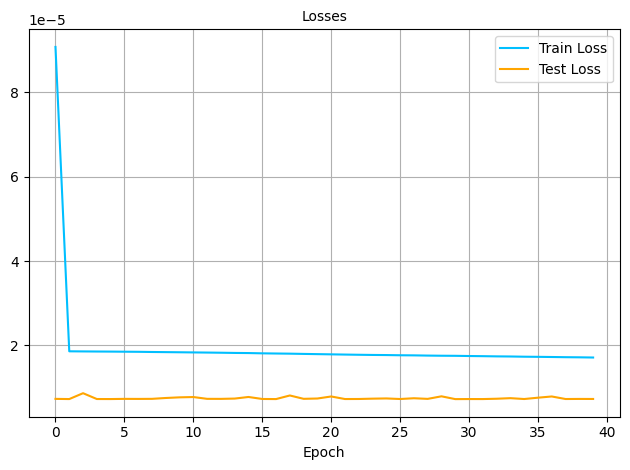

Epoch: 40, train_losses: 1.71089164556779e-05, test_losses: 7.289632776519284e-06, Duration: 0:00:10.571855


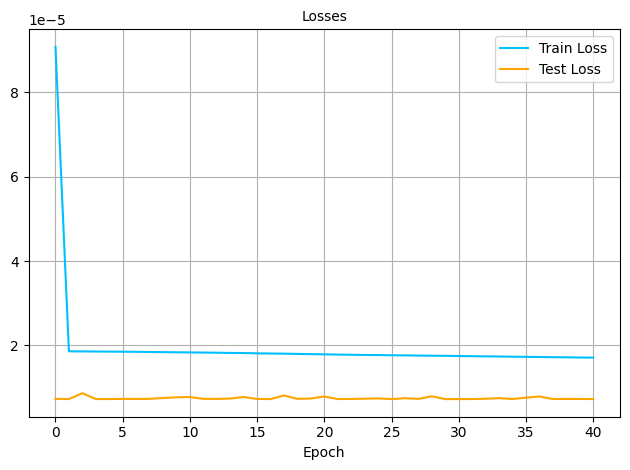

Epoch: 41, train_losses: 1.7054381802280163e-05, test_losses: 7.310958608286455e-06, Duration: 0:00:10.720947


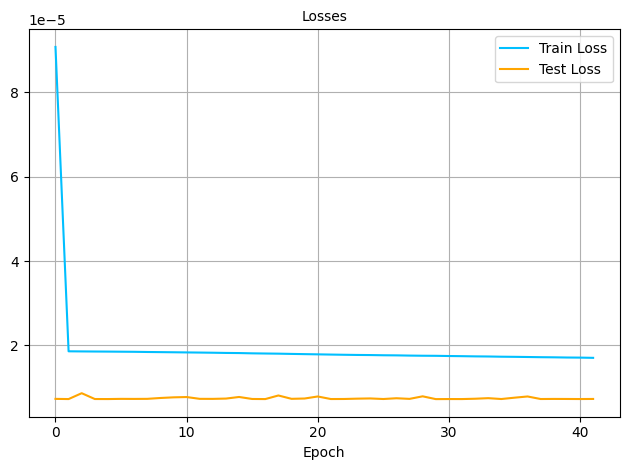

Epoch: 42, train_losses: 1.7047387730854078e-05, test_losses: 7.380723218375351e-06, Duration: 0:00:10.302443


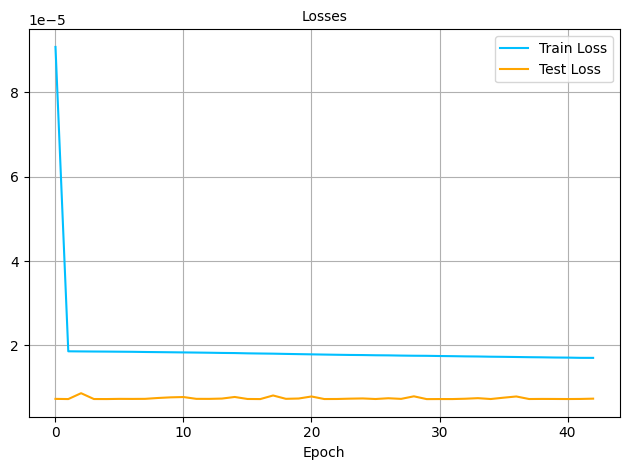

Epoch: 43, train_losses: 1.7009168454173353e-05, test_losses: 7.3326423262187745e-06, Duration: 0:00:10.401396


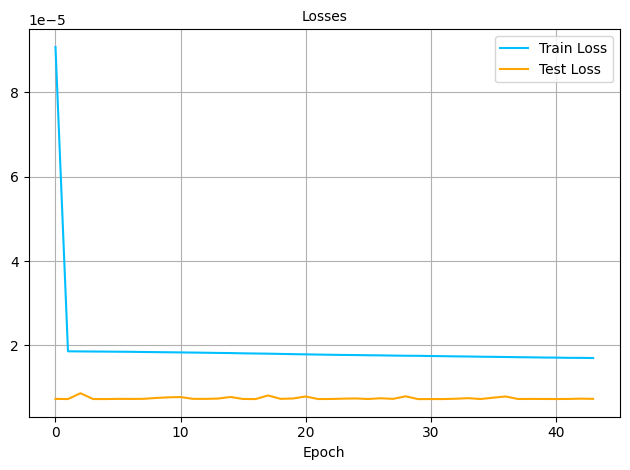

Epoch: 44, train_losses: 1.698872891412025e-05, test_losses: 7.453044418070931e-06, Duration: 0:00:10.340242


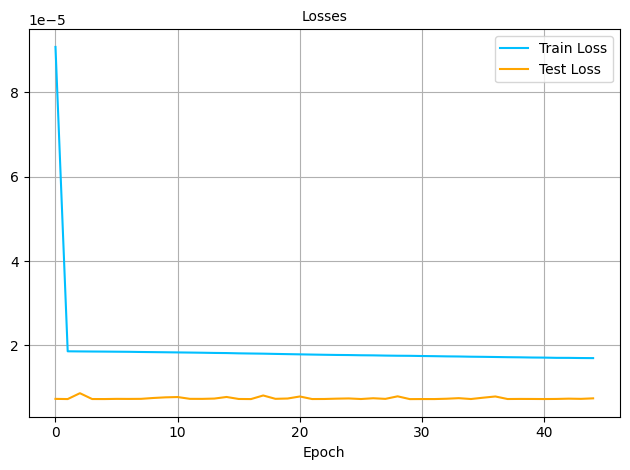

Epoch: 45, train_losses: 1.6966337178158264e-05, test_losses: 7.335031114052981e-06, Duration: 0:00:10.308764


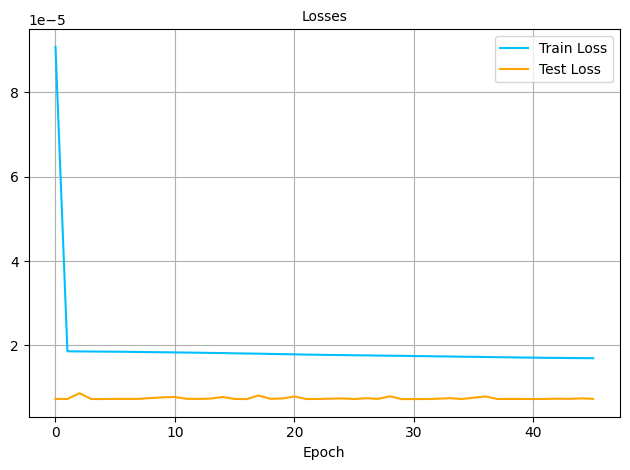

Epoch: 46, train_losses: 1.6920501485600795e-05, test_losses: 7.505000667151762e-06, Duration: 0:00:09.743687


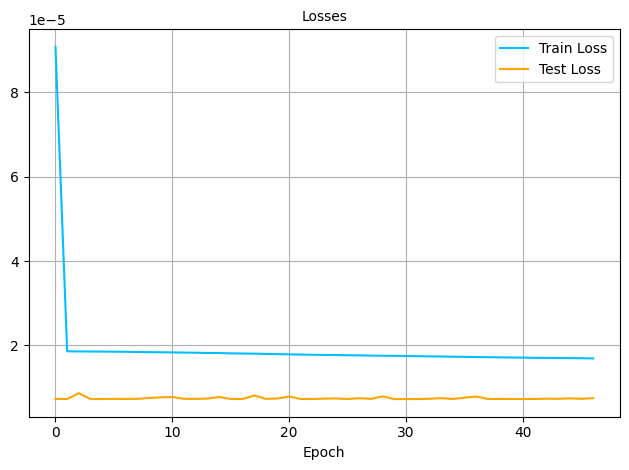

Epoch: 47, train_losses: 1.6912722589138542e-05, test_losses: 7.302124231500784e-06, Duration: 0:00:09.899761


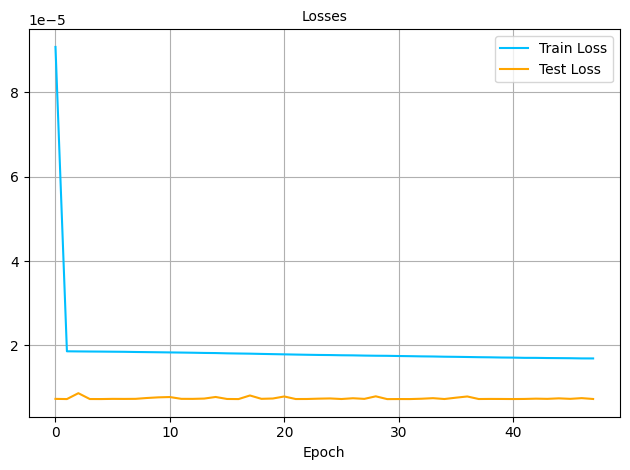

Epoch: 48, train_losses: 1.6871610240595027e-05, test_losses: 7.2902703323052265e-06, Duration: 0:00:10.090616


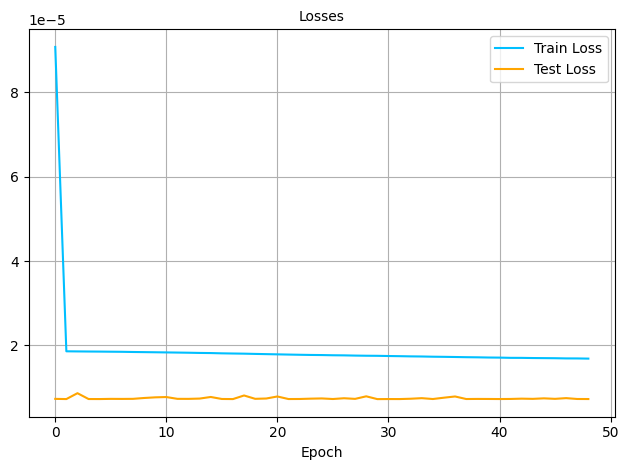

Epoch: 49, train_losses: 1.6854213342399328e-05, test_losses: 7.335907412198139e-06, Duration: 0:00:10.090596


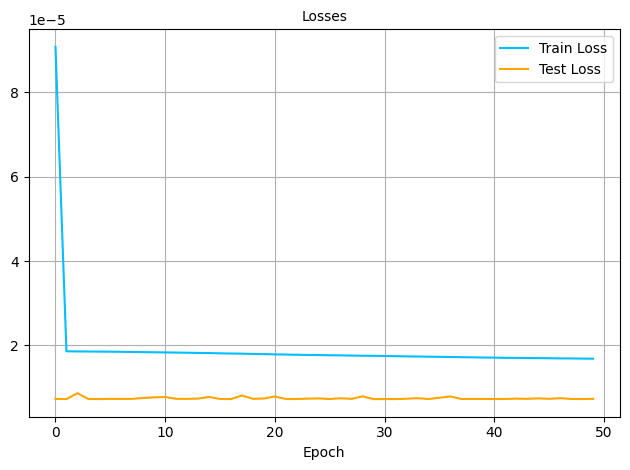

Epoch: 50, train_losses: 1.682111496890398e-05, test_losses: 7.642258424311876e-06, Duration: 0:00:10.124451


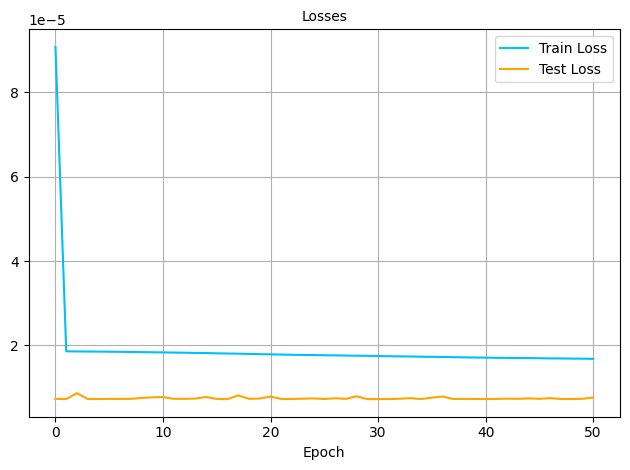

Epoch: 51, train_losses: 1.6828378271991823e-05, test_losses: 7.3212554525525775e-06, Duration: 0:00:09.586330


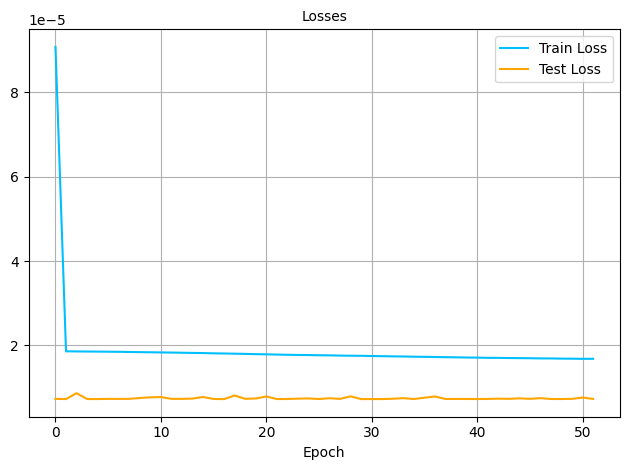

Epoch: 52, train_losses: 1.6808972211758784e-05, test_losses: 7.696135980950203e-06, Duration: 0:00:10.258584


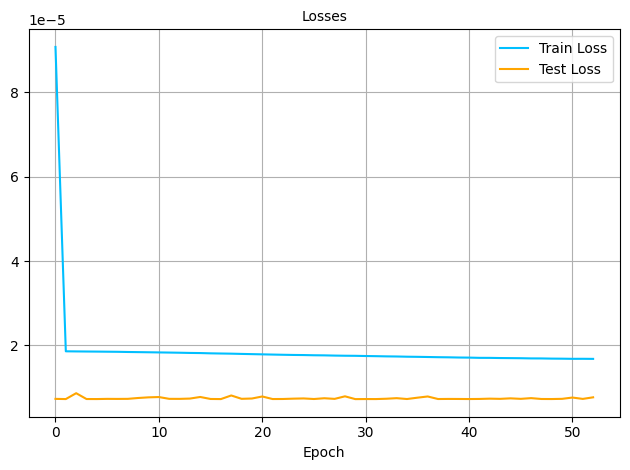

Epoch: 53, train_losses: 1.6784146124774082e-05, test_losses: 7.489244580938248e-06, Duration: 0:00:10.117651


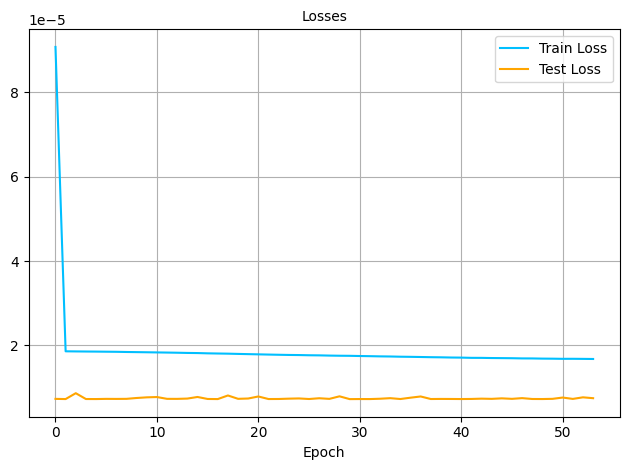

Epoch: 54, train_losses: 1.6760658976506306e-05, test_losses: 8.03093280410394e-06, Duration: 0:00:10.168767


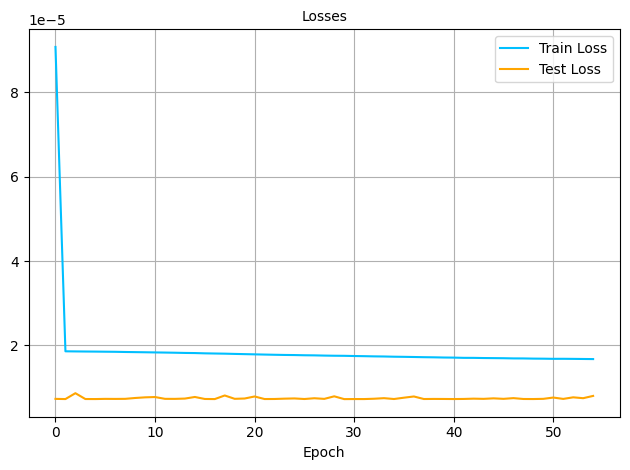

Epoch: 55, train_losses: 1.6726245209798025e-05, test_losses: 7.33003389541409e-06, Duration: 0:00:10.156123


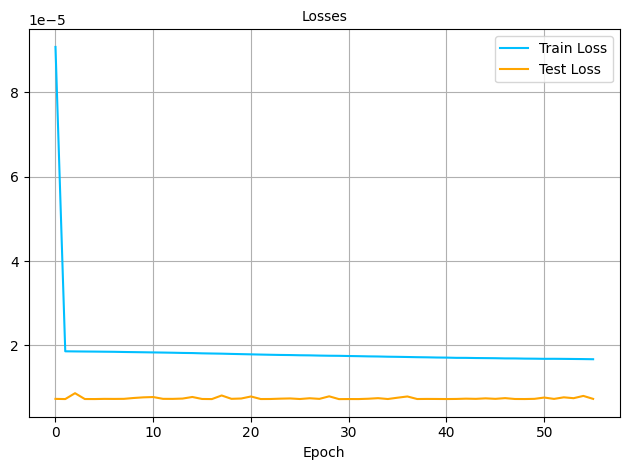

Epoch: 56, train_losses: 1.6723421385623815e-05, test_losses: 7.380316219496308e-06, Duration: 0:00:09.714804


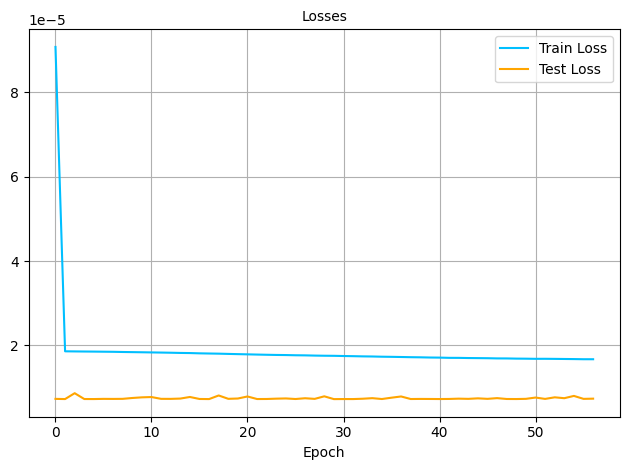

Epoch: 57, train_losses: 1.6714992062060295e-05, test_losses: 7.977290806593373e-06, Duration: 0:00:10.068188


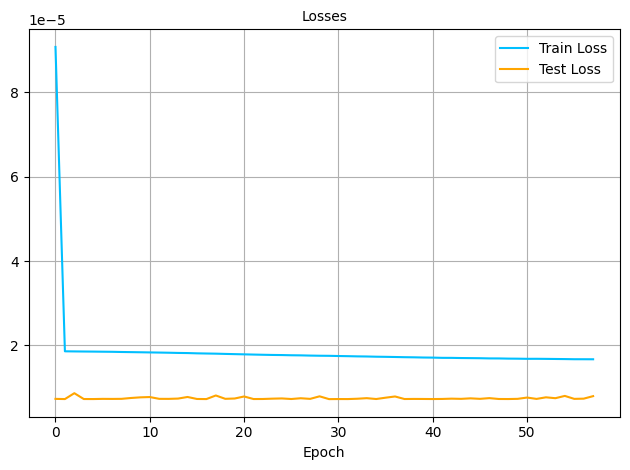

Epoch: 58, train_losses: 1.6683990936656325e-05, test_losses: 7.332541827054229e-06, Duration: 0:00:10.133380


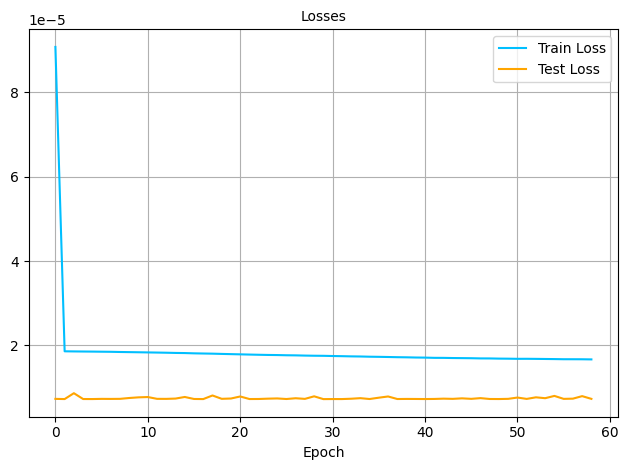

Epoch: 59, train_losses: 1.6663154491756644e-05, test_losses: 7.295034720300464e-06, Duration: 0:00:10.245120


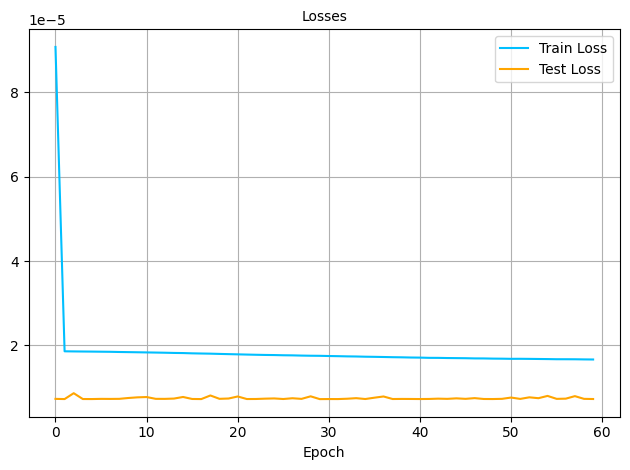

Epoch: 60, train_losses: 1.664975034725638e-05, test_losses: 7.542150797235081e-06, Duration: 0:00:10.302891


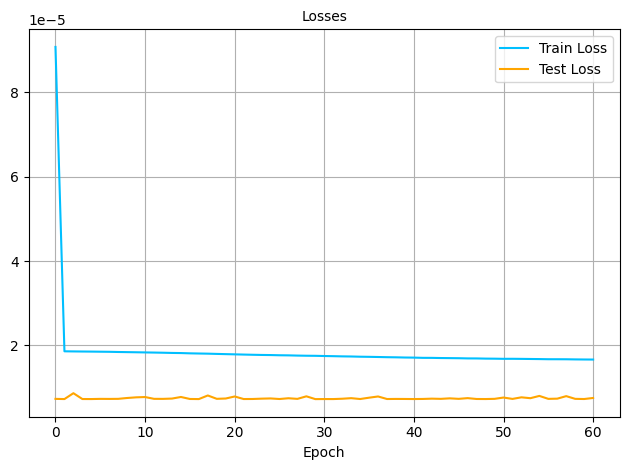

Epoch: 61, train_losses: 1.664095872368211e-05, test_losses: 7.358064976870082e-06, Duration: 0:00:09.583923


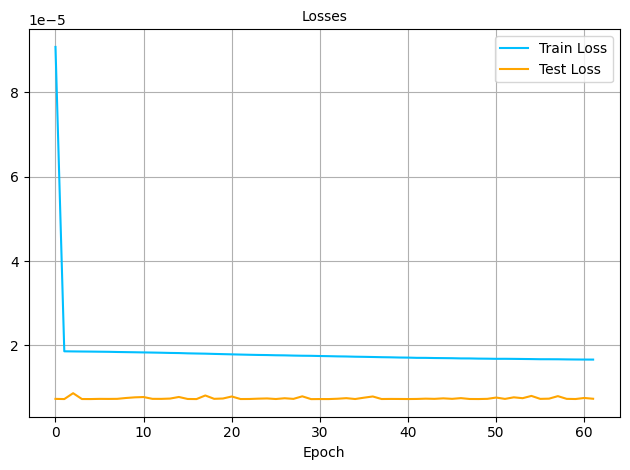

Epoch: 62, train_losses: 1.6606952428312138e-05, test_losses: 7.292722330021206e-06, Duration: 0:00:10.025586


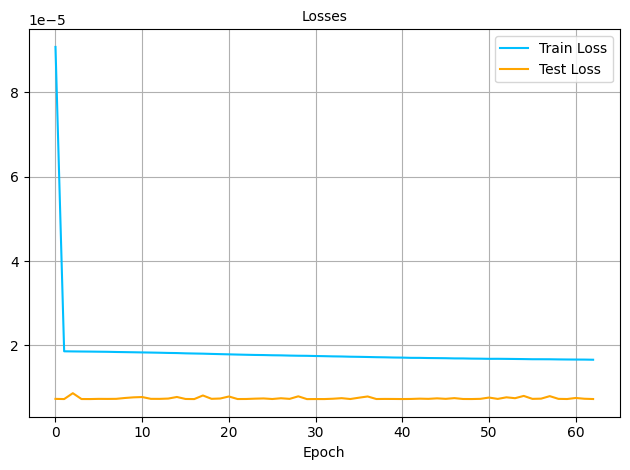

Epoch: 63, train_losses: 1.6600364782993915e-05, test_losses: 7.356866262853146e-06, Duration: 0:00:10.160952


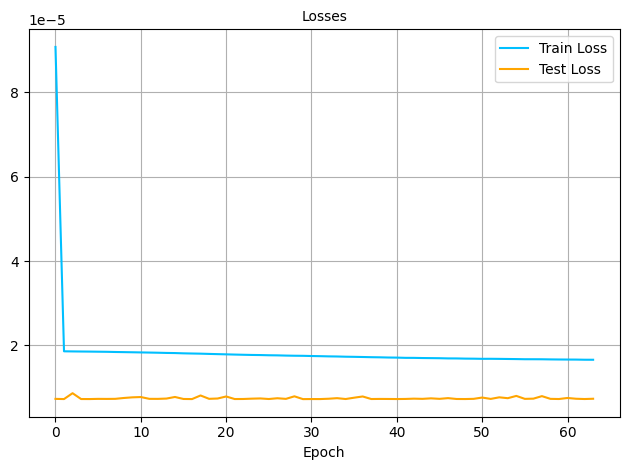

Epoch: 64, train_losses: 1.6602603982408867e-05, test_losses: 7.613060006406158e-06, Duration: 0:00:10.152235


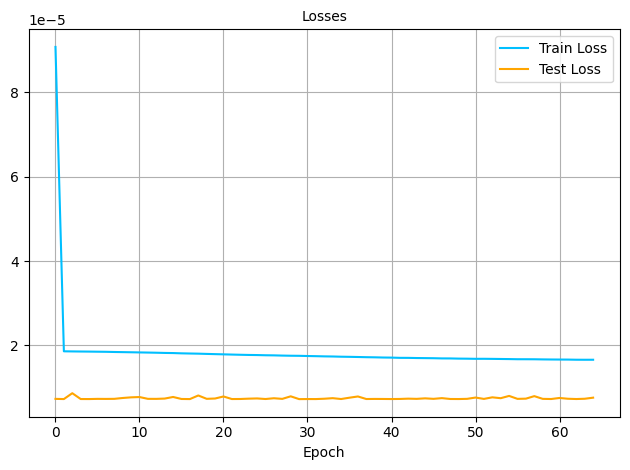

Epoch: 65, train_losses: 1.658865078458867e-05, test_losses: 7.6054084274801426e-06, Duration: 0:00:10.210835


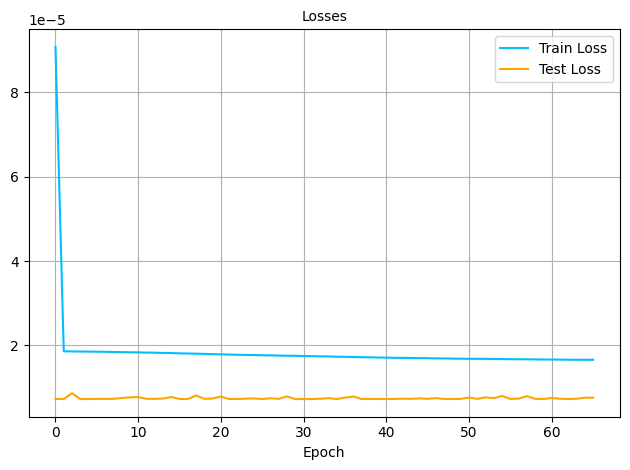

Epoch: 66, train_losses: 1.6559597229159924e-05, test_losses: 7.387785444734618e-06, Duration: 0:00:09.996208


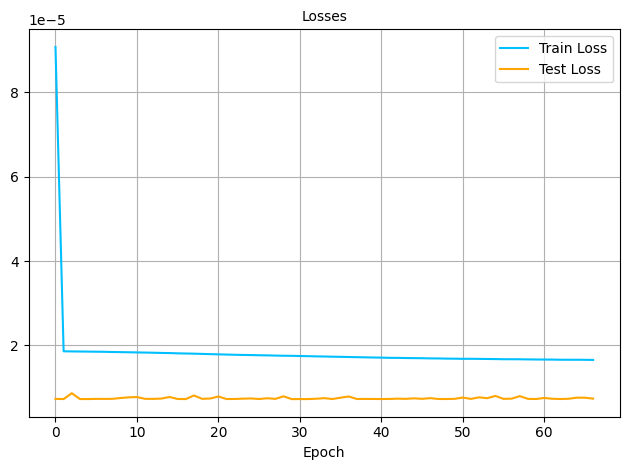

Epoch: 67, train_losses: 1.655293192913506e-05, test_losses: 7.384453510894673e-06, Duration: 0:00:09.920558


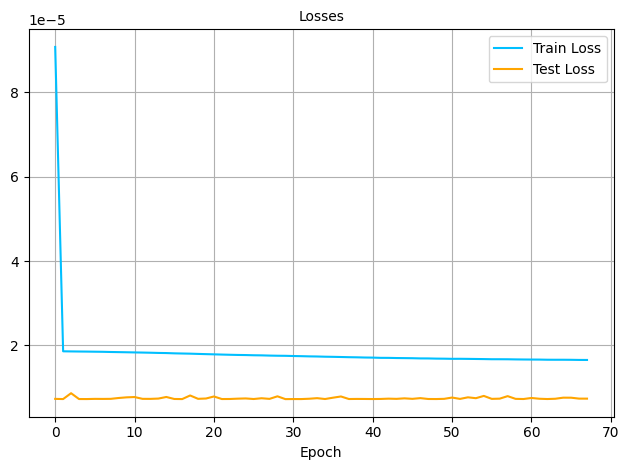

Epoch: 68, train_losses: 1.6540023969283692e-05, test_losses: 7.312124125746777e-06, Duration: 0:00:10.296130


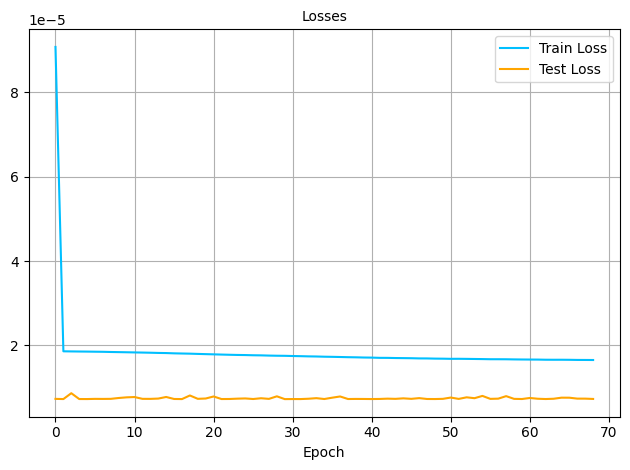

Epoch: 69, train_losses: 1.653341566738399e-05, test_losses: 7.365127203229349e-06, Duration: 0:00:10.174938


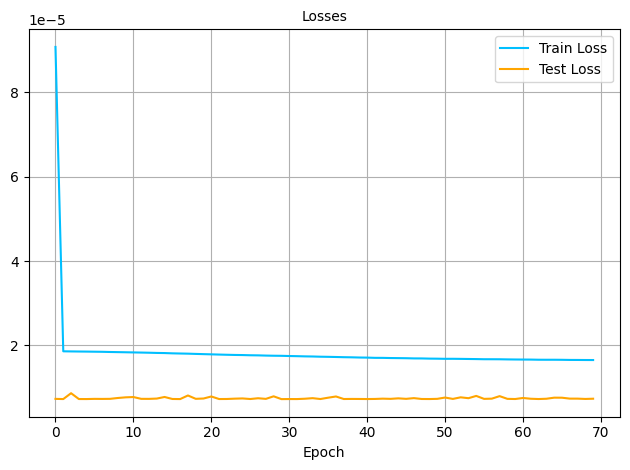

Epoch: 70, train_losses: 1.651722445519423e-05, test_losses: 7.3981773311970755e-06, Duration: 0:00:10.141258


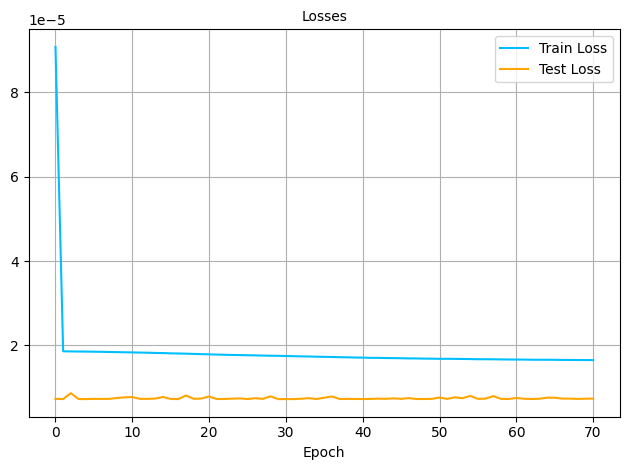

Epoch: 71, train_losses: 1.651064112213589e-05, test_losses: 7.3062597039097454e-06, Duration: 0:00:10.046570


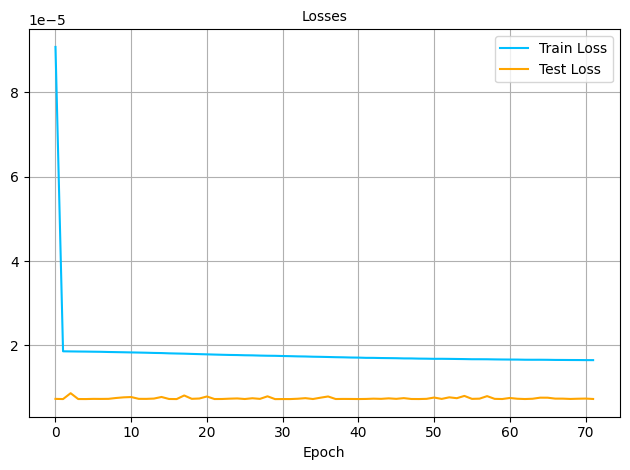

Epoch: 72, train_losses: 1.650420313672148e-05, test_losses: 7.361174539255444e-06, Duration: 0:00:09.577261


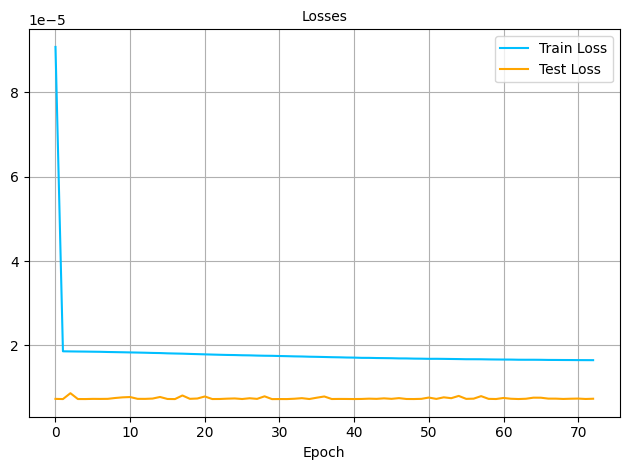

Epoch: 73, train_losses: 1.6483550877343082e-05, test_losses: 7.550702775915852e-06, Duration: 0:00:10.137330


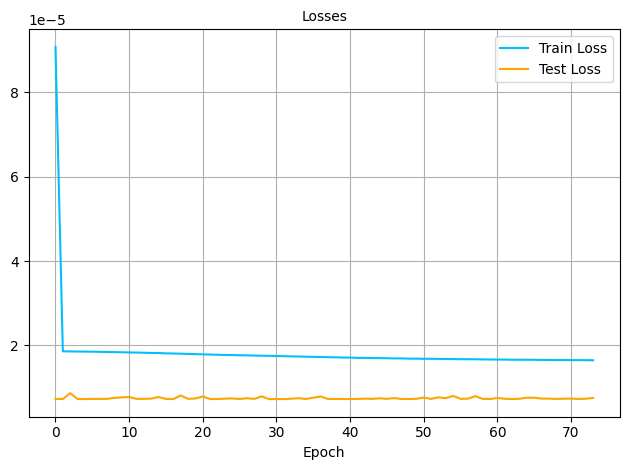

Epoch: 74, train_losses: 1.6489594672686484e-05, test_losses: 7.378790087386733e-06, Duration: 0:00:10.147760


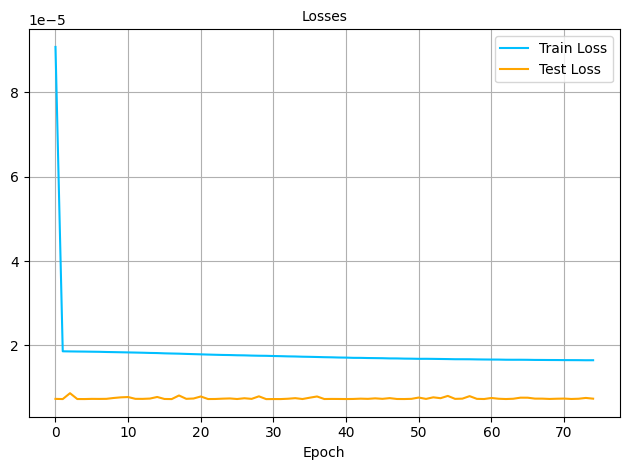

Epoch: 75, train_losses: 1.6459821934458787e-05, test_losses: 7.310780802072259e-06, Duration: 0:00:10.355705


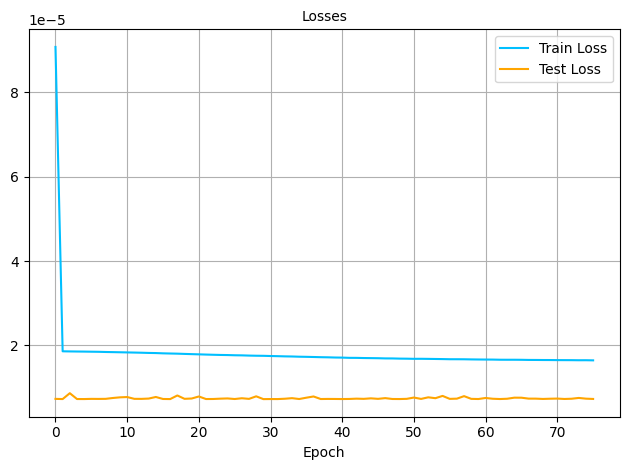

Epoch: 76, train_losses: 1.6471592878005088e-05, test_losses: 7.32277521819924e-06, Duration: 0:00:09.680445


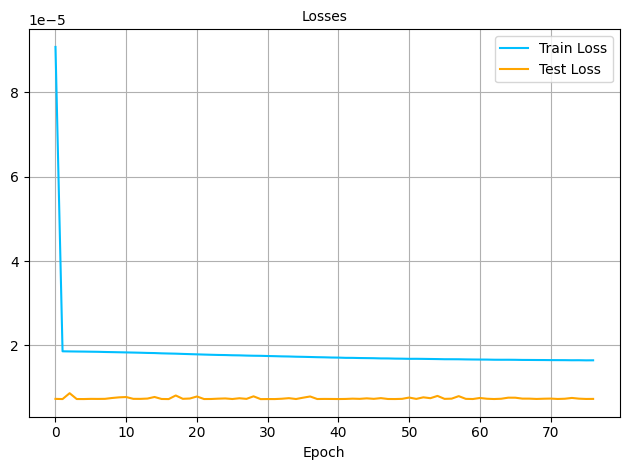

Epoch: 77, train_losses: 1.6454622280657195e-05, test_losses: 7.92312766861869e-06, Duration: 0:00:09.846444


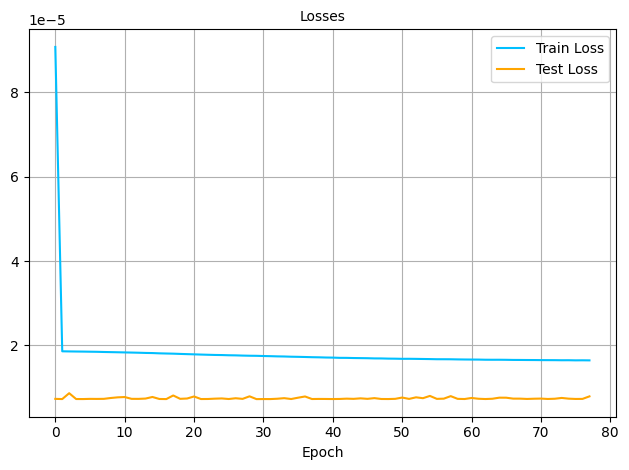

Epoch: 78, train_losses: 1.6441236673162043e-05, test_losses: 7.308376098080771e-06, Duration: 0:00:10.259568


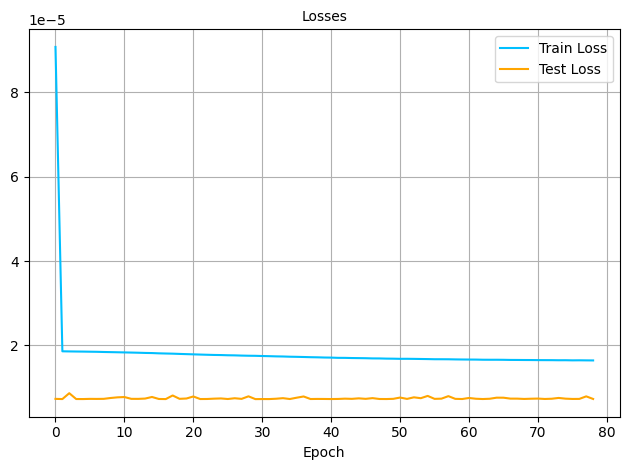

Epoch: 79, train_losses: 1.6429687569788697e-05, test_losses: 7.313263722608099e-06, Duration: 0:00:10.206995


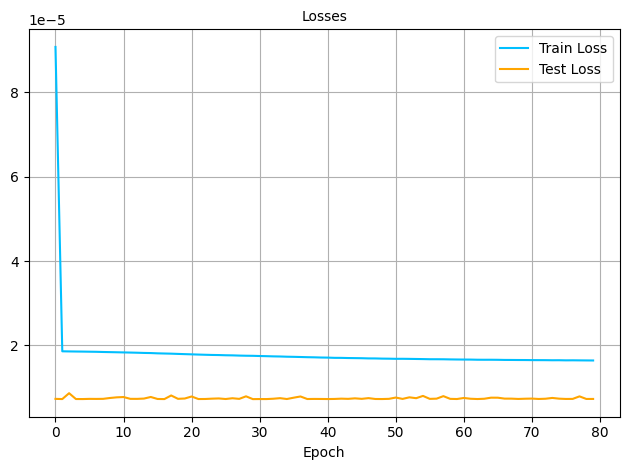

Epoch: 80, train_losses: 1.642707230335249e-05, test_losses: 7.314740287256427e-06, Duration: 0:00:10.274784


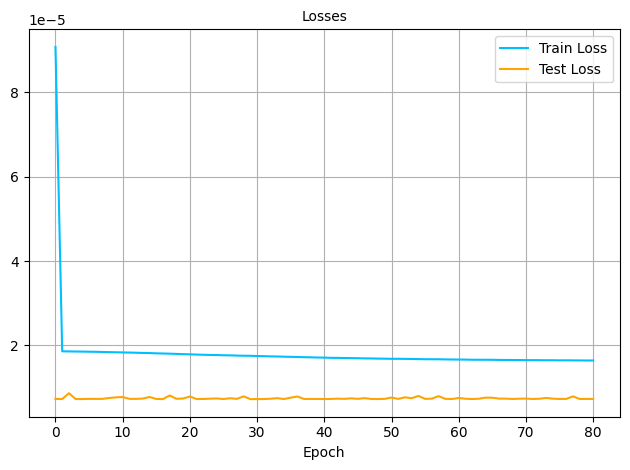

Epoch: 81, train_losses: 1.640632780540102e-05, test_losses: 7.483533863705816e-06, Duration: 0:00:09.746212


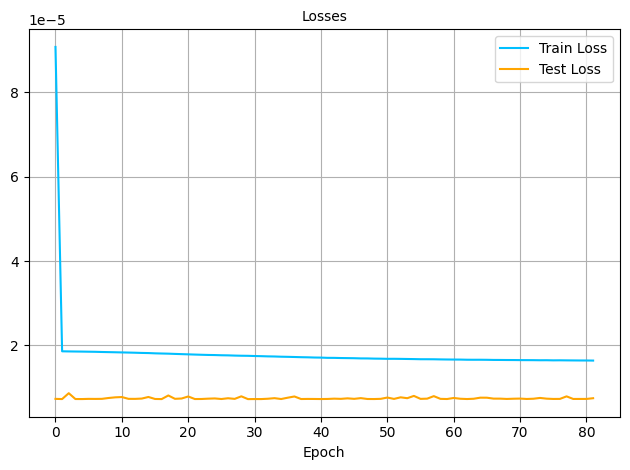

Epoch: 82, train_losses: 1.6380226655900976e-05, test_losses: 7.344983259827131e-06, Duration: 0:00:09.557102


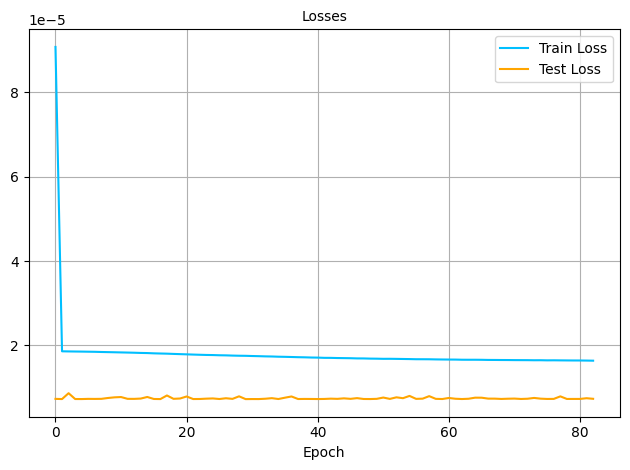

Epoch: 83, train_losses: 1.638417084872695e-05, test_losses: 7.3376490945520345e-06, Duration: 0:00:10.158690


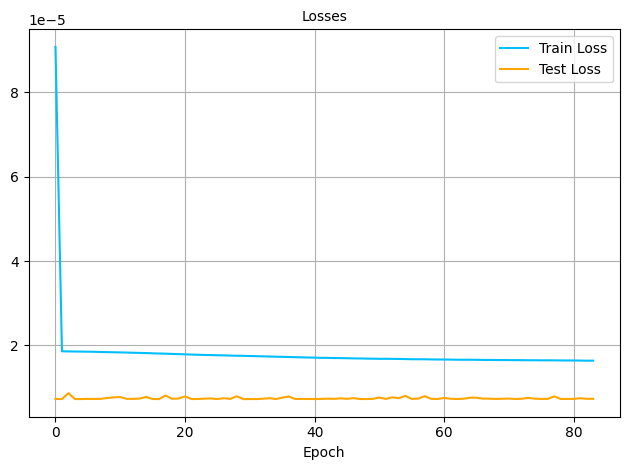

Epoch: 84, train_losses: 1.6352348729040032e-05, test_losses: 7.334409474424319e-06, Duration: 0:00:10.097988


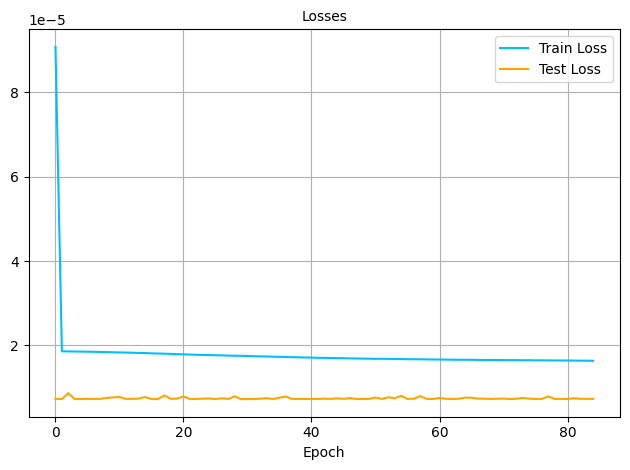

Epoch: 85, train_losses: 1.636068492515924e-05, test_losses: 7.3574715315771755e-06, Duration: 0:00:10.325209


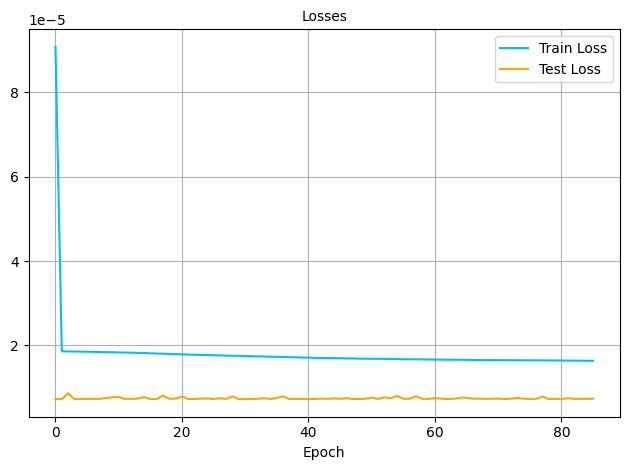

Epoch: 86, train_losses: 1.635142631076672e-05, test_losses: 7.541014383605216e-06, Duration: 0:00:09.727860


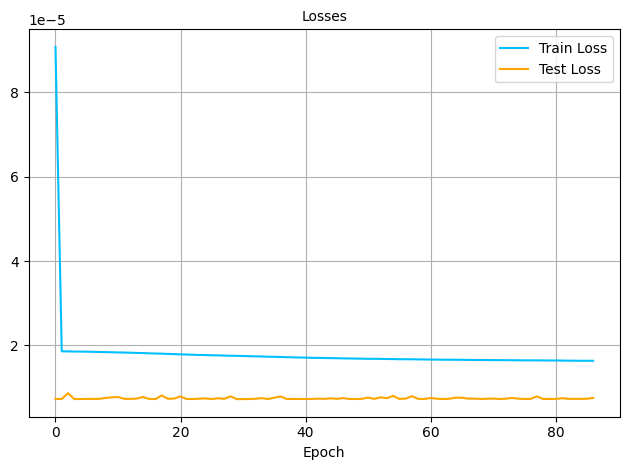

Epoch: 87, train_losses: 1.6337365873367162e-05, test_losses: 7.315086349990452e-06, Duration: 0:00:09.750541


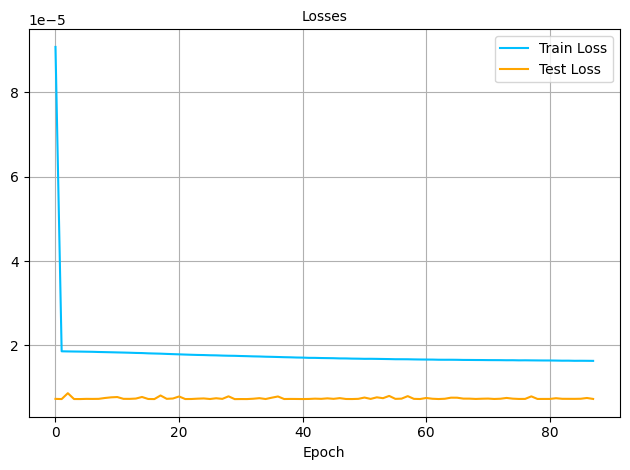

Epoch: 88, train_losses: 1.632669433266052e-05, test_losses: 7.3195969889638945e-06, Duration: 0:00:10.062388


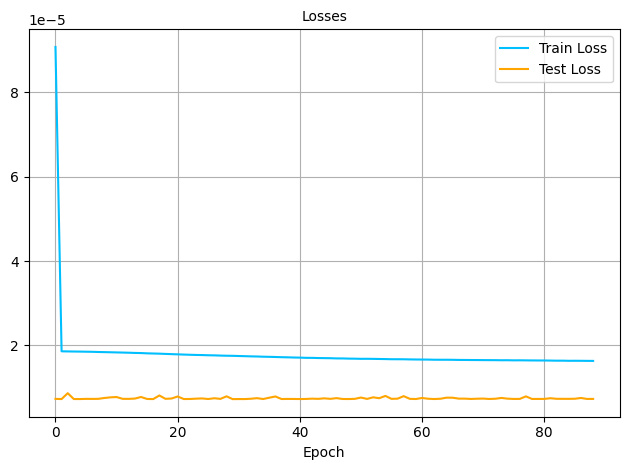

Epoch: 89, train_losses: 1.632023350312182e-05, test_losses: 7.33087017579237e-06, Duration: 0:00:10.393802


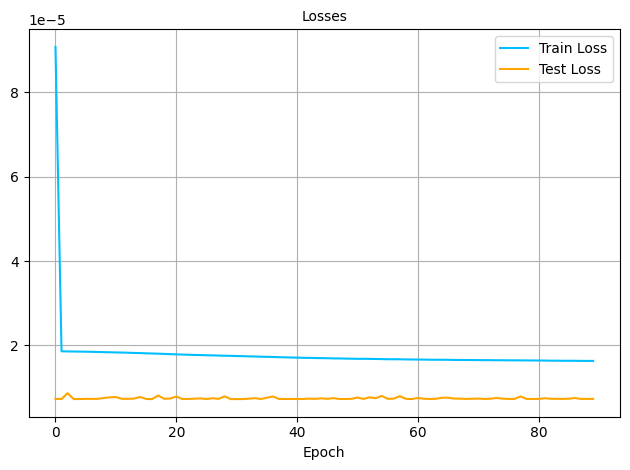

Epoch: 90, train_losses: 1.631152166467304e-05, test_losses: 7.348223789449548e-06, Duration: 0:00:10.241872


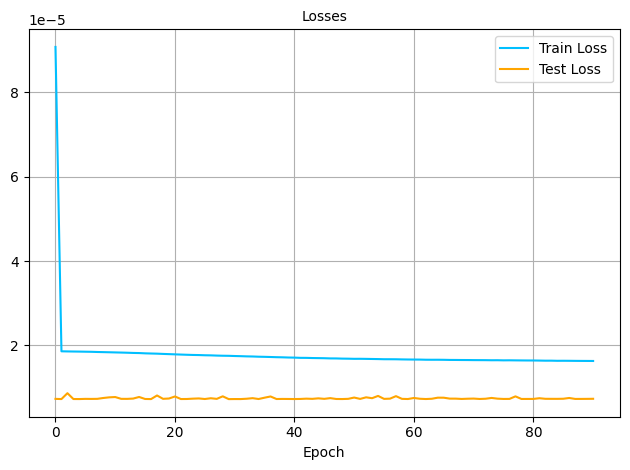

Epoch: 91, train_losses: 1.630020045649095e-05, test_losses: 7.3401283771090675e-06, Duration: 0:00:09.797304


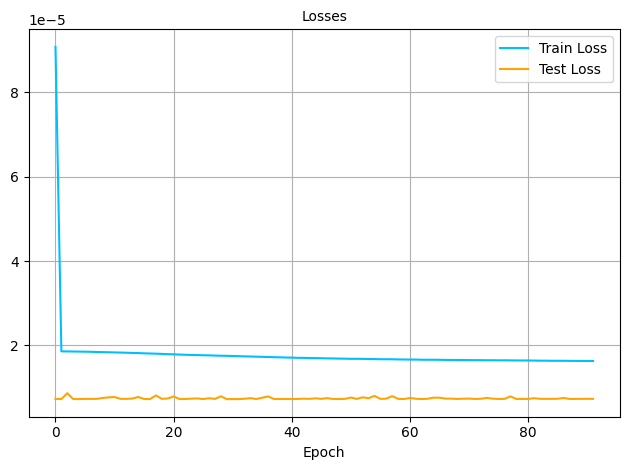

Epoch: 92, train_losses: 1.630130849749826e-05, test_losses: 7.394125077553326e-06, Duration: 0:00:09.834194


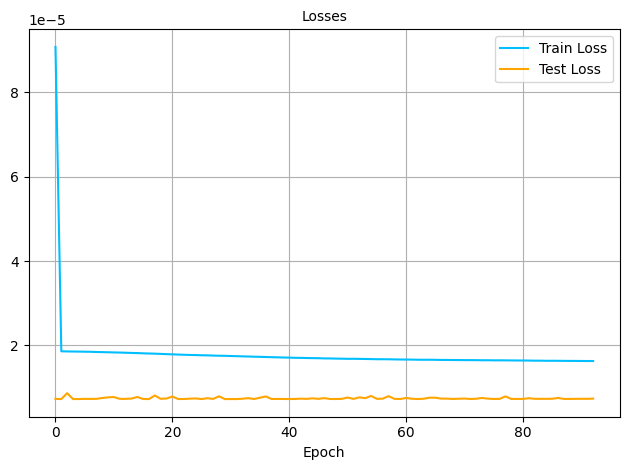

Epoch: 93, train_losses: 1.6285615739705934e-05, test_losses: 8.274930223706178e-06, Duration: 0:00:10.210107


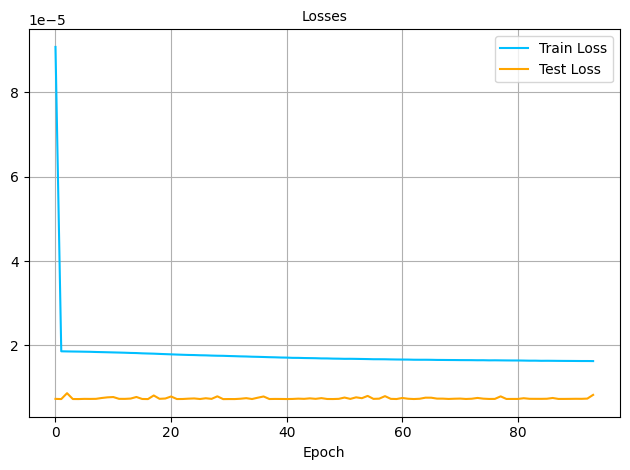

Epoch: 94, train_losses: 1.6271591651386718e-05, test_losses: 7.336305770877516e-06, Duration: 0:00:10.404270


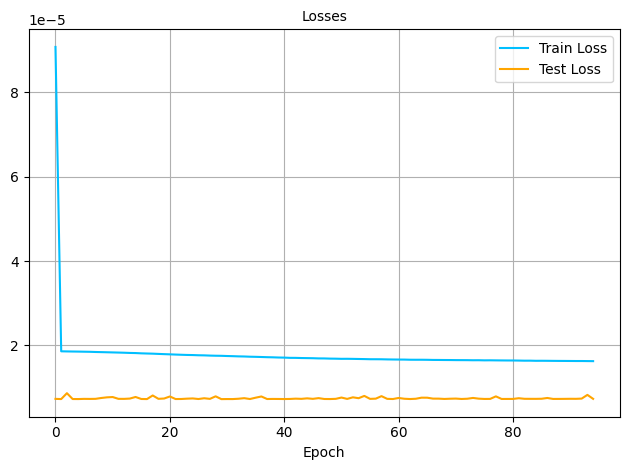

Epoch: 95, train_losses: 1.6256469208385e-05, test_losses: 7.509613169531804e-06, Duration: 0:00:10.244036


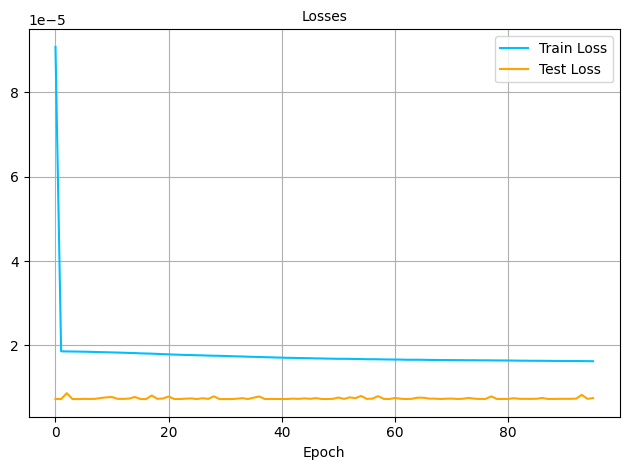

Epoch: 96, train_losses: 1.626544816055691e-05, test_losses: 7.522026862716302e-06, Duration: 0:00:09.887184


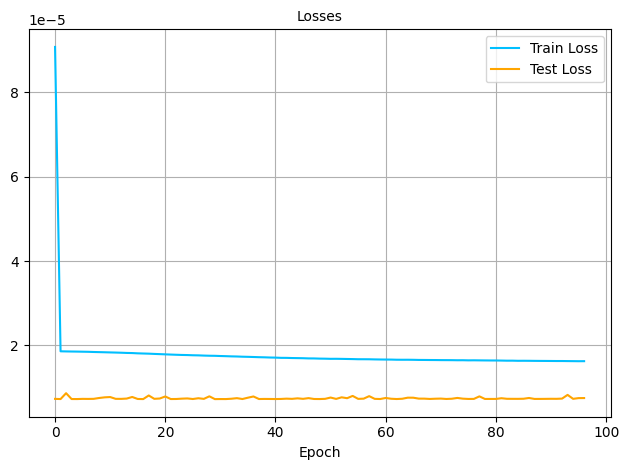

Epoch: 97, train_losses: 1.6241312627911513e-05, test_losses: 7.316259143408388e-06, Duration: 0:00:09.793394


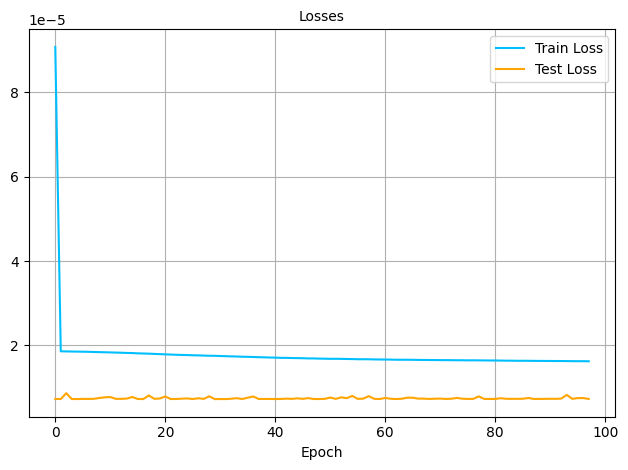

Epoch: 98, train_losses: 1.6241028964572347e-05, test_losses: 7.353792625508504e-06, Duration: 0:00:10.212521


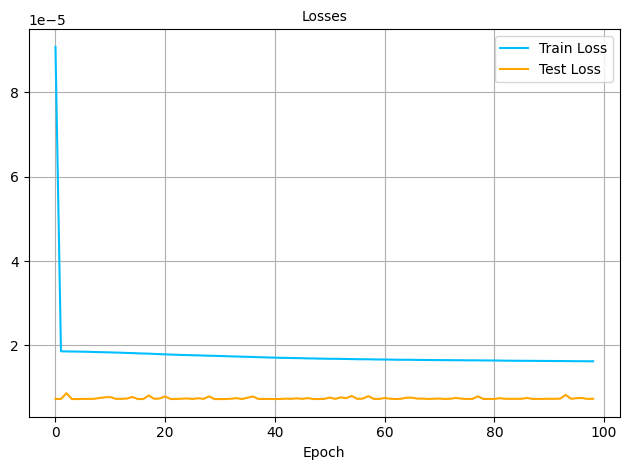

Epoch: 99, train_losses: 1.6221300225821664e-05, test_losses: 7.326741069846321e-06, Duration: 0:00:10.394800


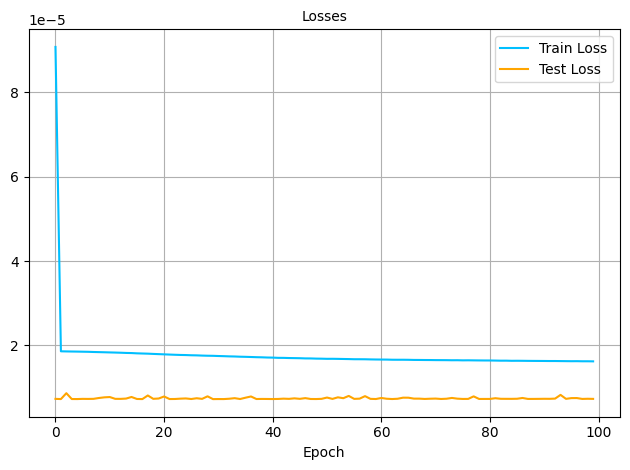

Epoch: 100, train_losses: 1.6212521420426974e-05, test_losses: 7.4906001827912405e-06, Duration: 0:00:10.149862


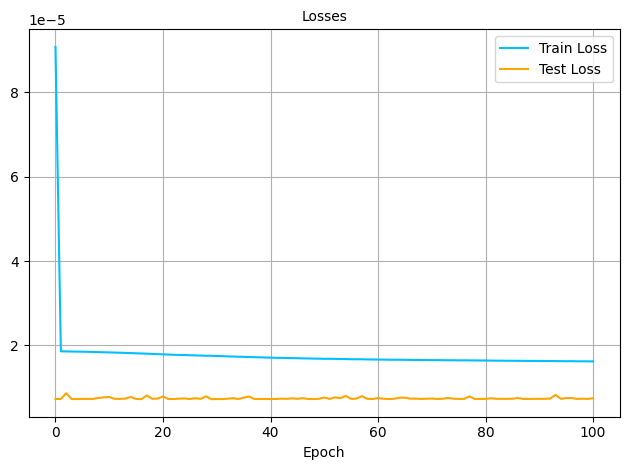

Epoch: 101, train_losses: 1.6222844463011286e-05, test_losses: 7.629581887158565e-06, Duration: 0:00:09.817631


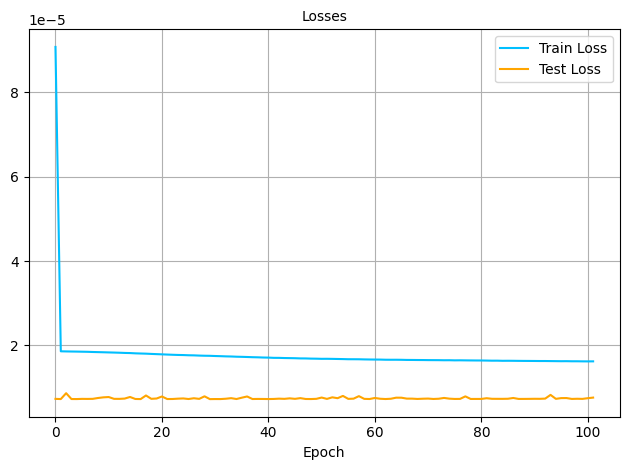

Epoch: 102, train_losses: 1.6190788223380682e-05, test_losses: 7.585139428556431e-06, Duration: 0:00:09.770605


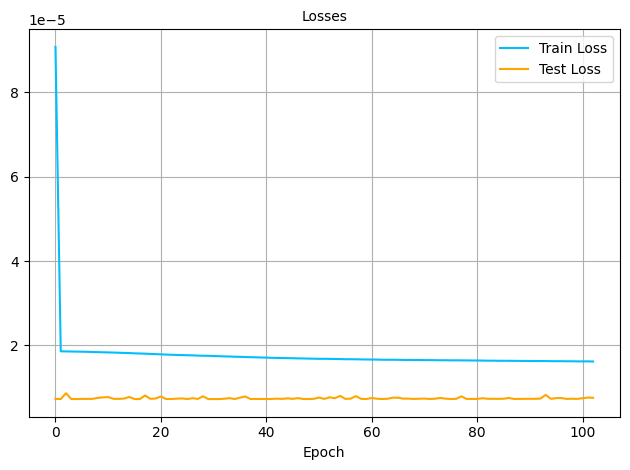

Epoch: 103, train_losses: 1.6188844871115866e-05, test_losses: 7.3669839366630185e-06, Duration: 0:00:10.465314


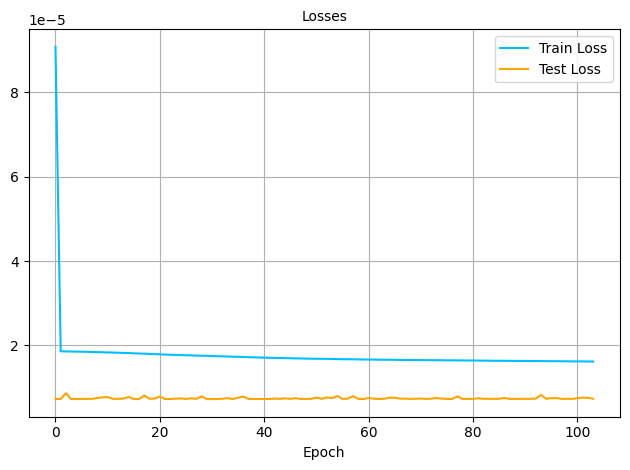

Epoch: 104, train_losses: 1.6199488105619632e-05, test_losses: 7.608702162542613e-06, Duration: 0:00:10.508083


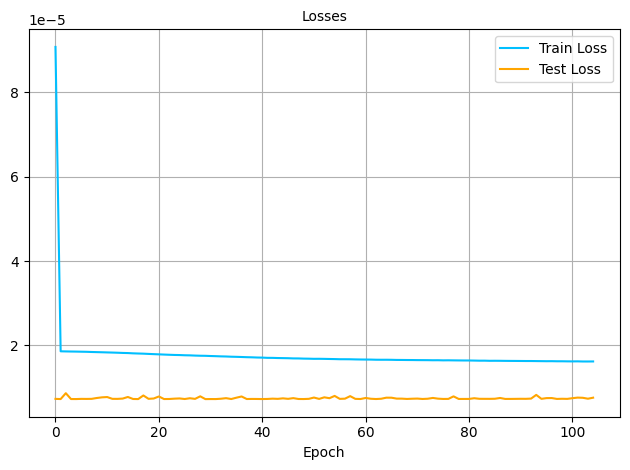

Epoch: 105, train_losses: 1.620503503828748e-05, test_losses: 7.436162377416622e-06, Duration: 0:00:10.246351


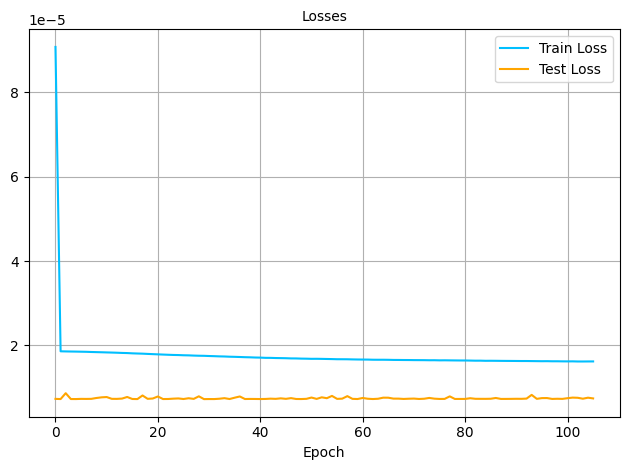

Epoch: 106, train_losses: 1.6183429430597694e-05, test_losses: 7.549152996944031e-06, Duration: 0:00:09.905157


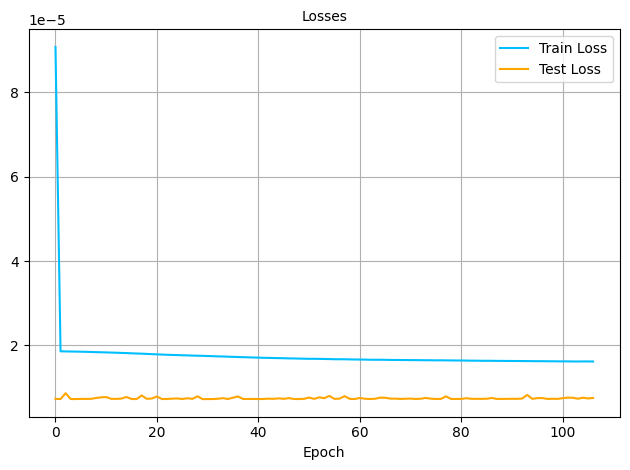

Epoch: 107, train_losses: 1.617725886686324e-05, test_losses: 7.351922704401659e-06, Duration: 0:00:09.482263


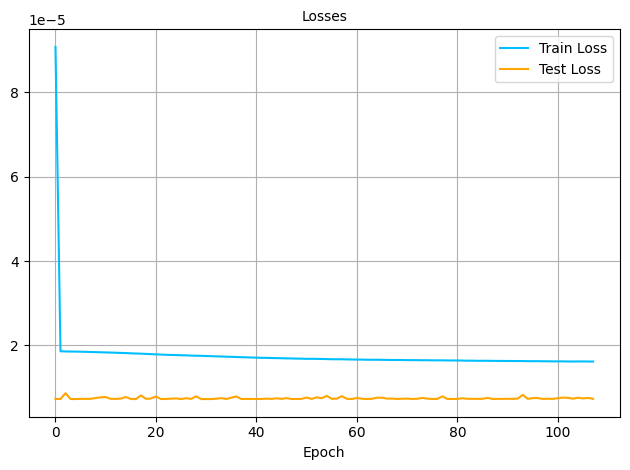

Epoch: 108, train_losses: 1.6161655992869156e-05, test_losses: 7.376042503892677e-06, Duration: 0:00:10.465824


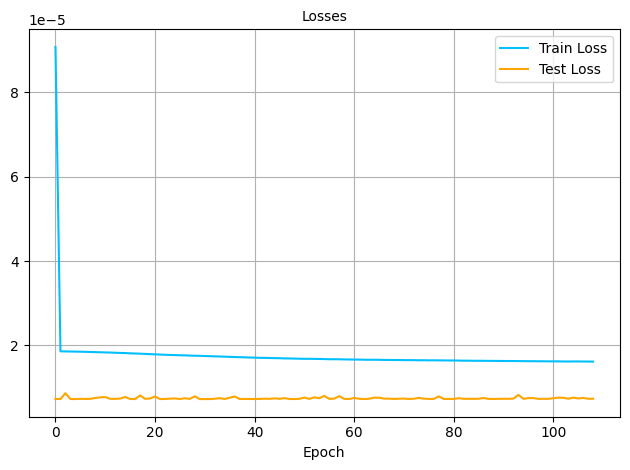

Epoch: 109, train_losses: 1.6154103614345126e-05, test_losses: 7.328067567868857e-06, Duration: 0:00:10.141817


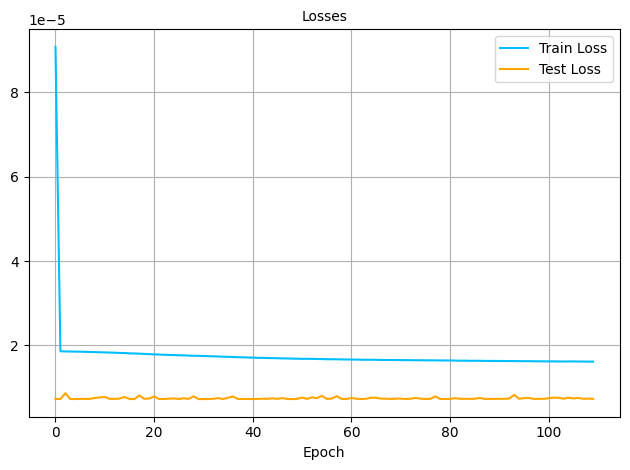

Epoch: 110, train_losses: 1.616258174727567e-05, test_losses: 7.3919454735005274e-06, Duration: 0:00:10.247326


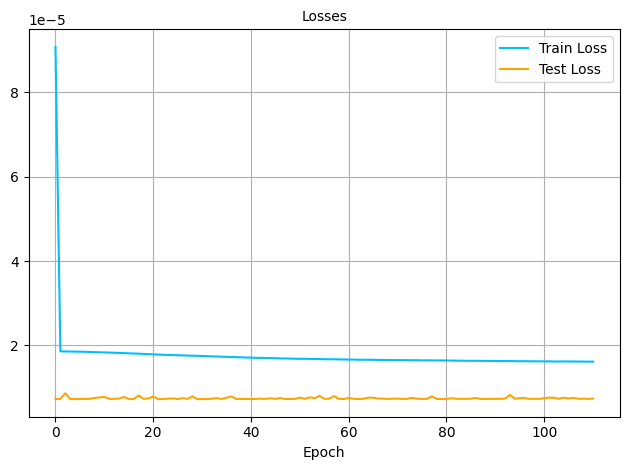

Epoch: 111, train_losses: 1.613427665790045e-05, test_losses: 7.37862956157187e-06, Duration: 0:00:09.866160


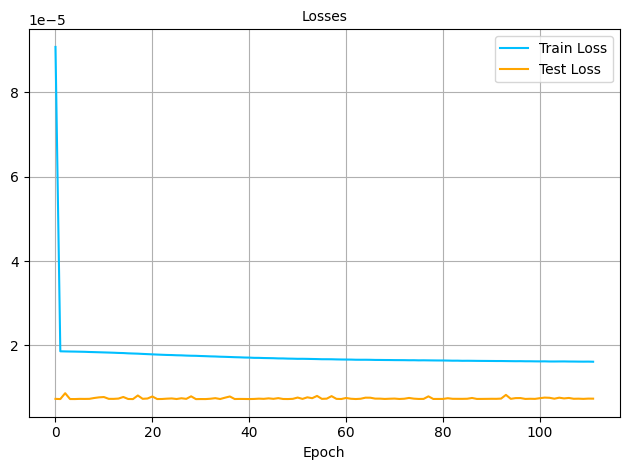

Epoch: 112, train_losses: 1.6129843660895628e-05, test_losses: 7.322607416426763e-06, Duration: 0:00:09.680173


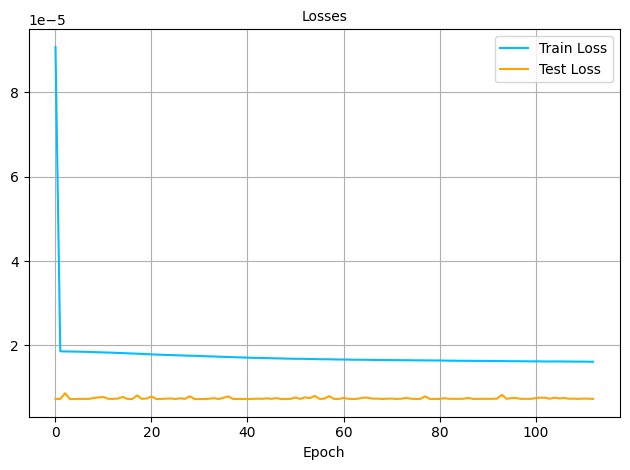

Epoch: 113, train_losses: 1.6130264375924076e-05, test_losses: 7.374344932031818e-06, Duration: 0:00:10.381635


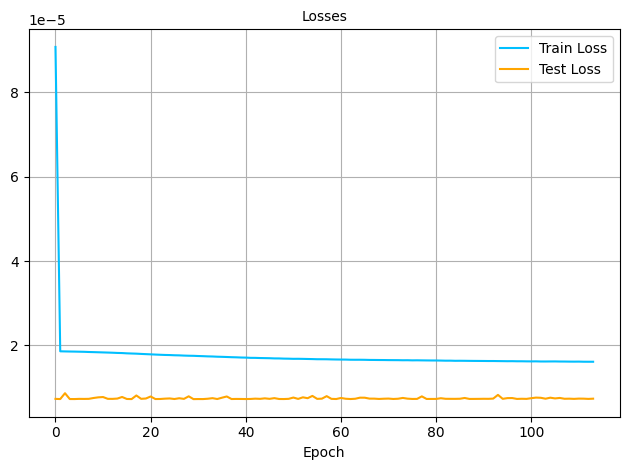

Epoch: 114, train_losses: 1.6105828195684002e-05, test_losses: 7.44713406675146e-06, Duration: 0:00:10.630077


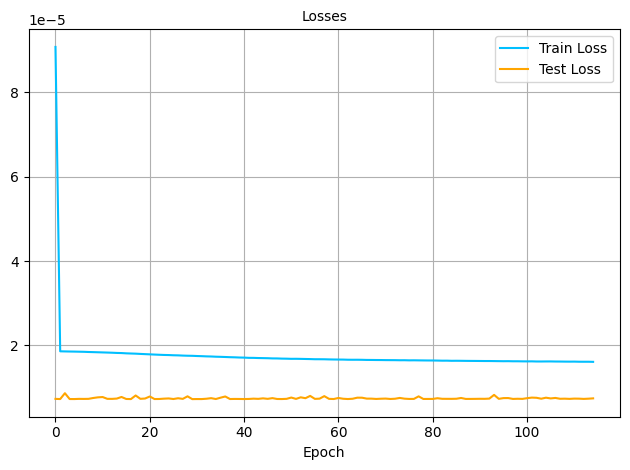

Epoch: 115, train_losses: 1.6115727282384026e-05, test_losses: 7.340186584769981e-06, Duration: 0:00:10.482158


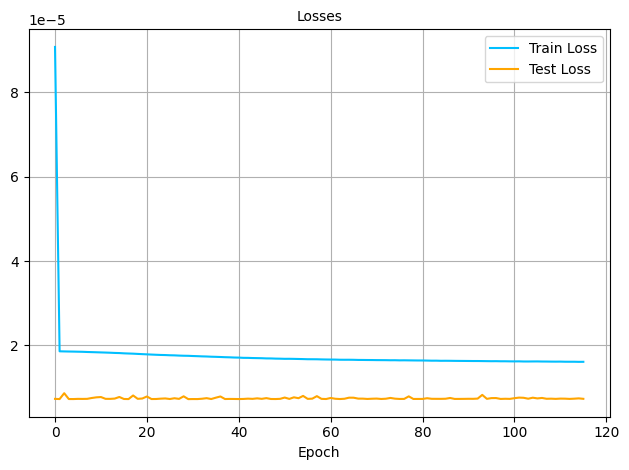

Epoch: 116, train_losses: 1.611091182869364e-05, test_losses: 7.381037903542165e-06, Duration: 0:00:11.143035


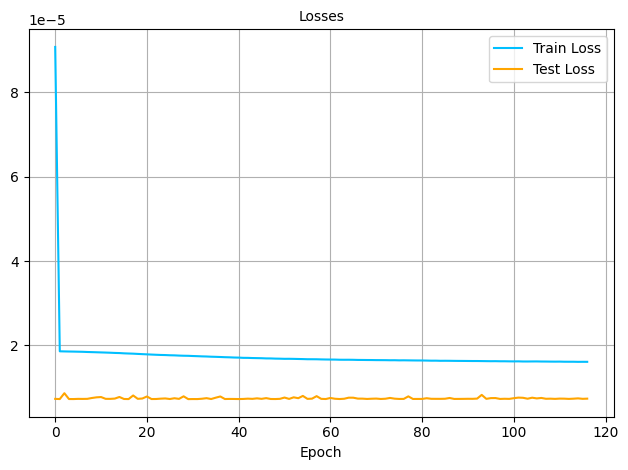

Epoch: 117, train_losses: 1.6096170913699927e-05, test_losses: 7.33215256332187e-06, Duration: 0:00:10.985120


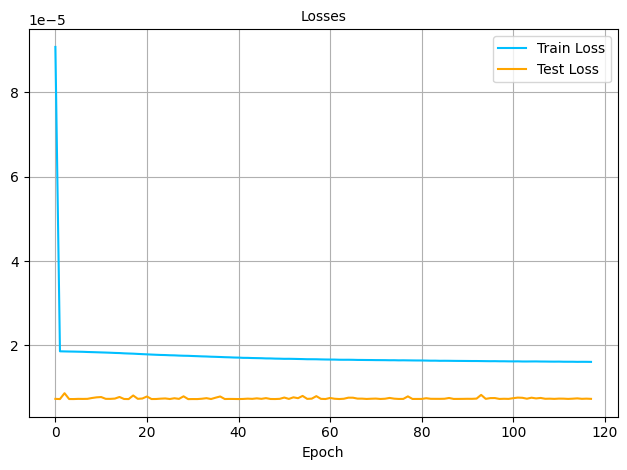

Epoch: 118, train_losses: 1.6098120260158993e-05, test_losses: 7.3382016125833616e-06, Duration: 0:00:09.737630


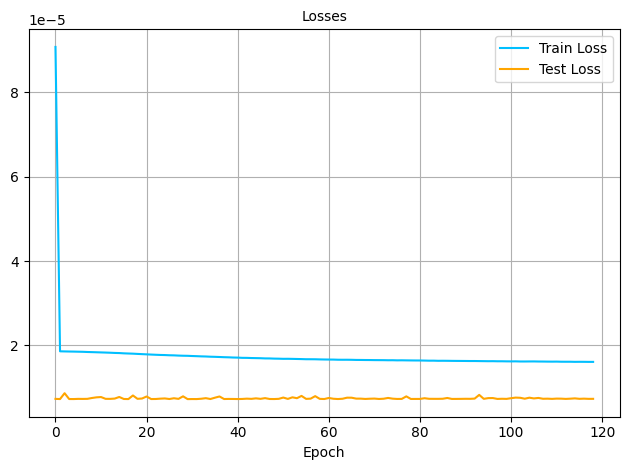

Epoch: 119, train_losses: 1.608566916342864e-05, test_losses: 7.339774583670078e-06, Duration: 0:00:10.840714


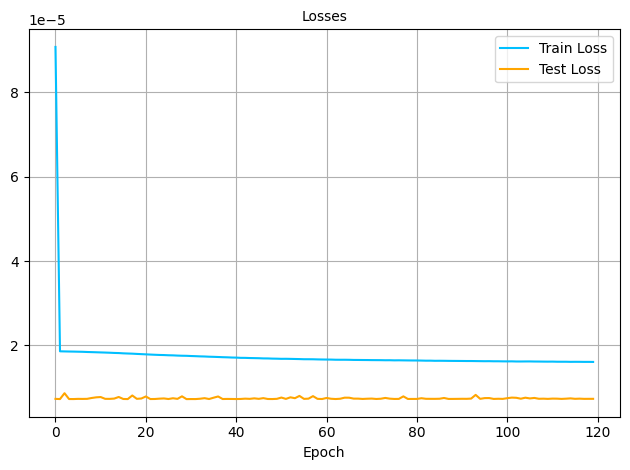

Epoch: 120, train_losses: 1.6076989794013505e-05, test_losses: 7.333155735977925e-06, Duration: 0:00:10.835078


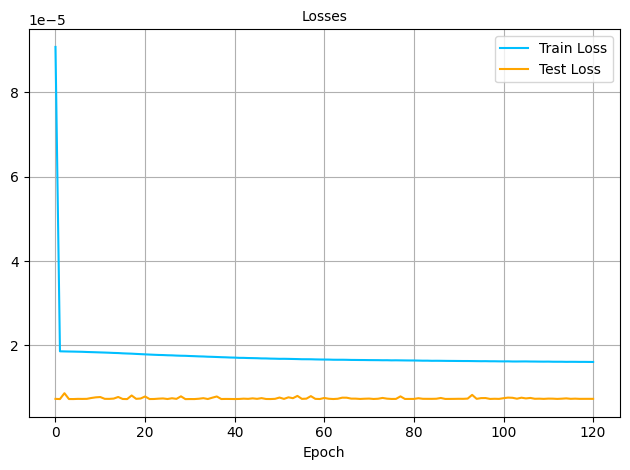

Epoch: 121, train_losses: 1.6074661978385047e-05, test_losses: 7.3928586061811075e-06, Duration: 0:00:10.866094


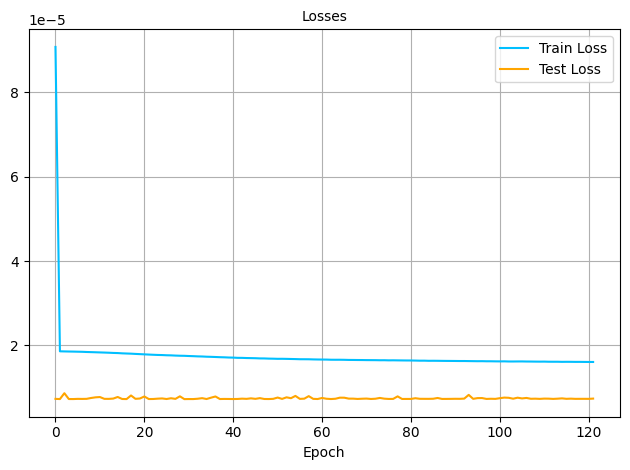

Epoch: 122, train_losses: 1.6054151568274413e-05, test_losses: 7.387236564682098e-06, Duration: 0:00:11.447773


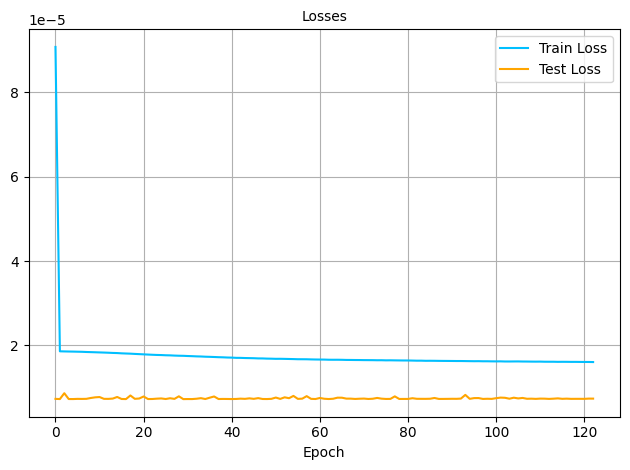

Epoch: 123, train_losses: 1.606174256884216e-05, test_losses: 7.361963071161881e-06, Duration: 0:00:10.590991


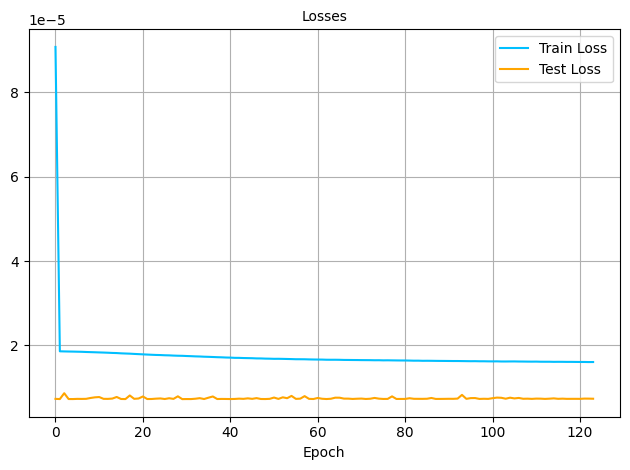

Epoch: 124, train_losses: 1.605984990906364e-05, test_losses: 7.444471521012019e-06, Duration: 0:00:09.959057


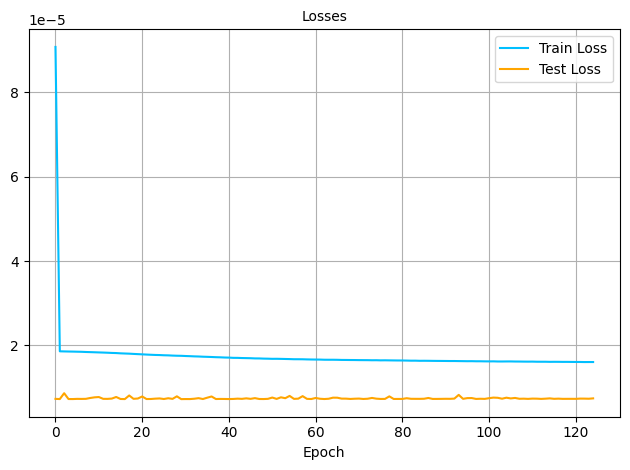

Epoch: 125, train_losses: 1.603905009279837e-05, test_losses: 7.339474450418493e-06, Duration: 0:00:10.174932


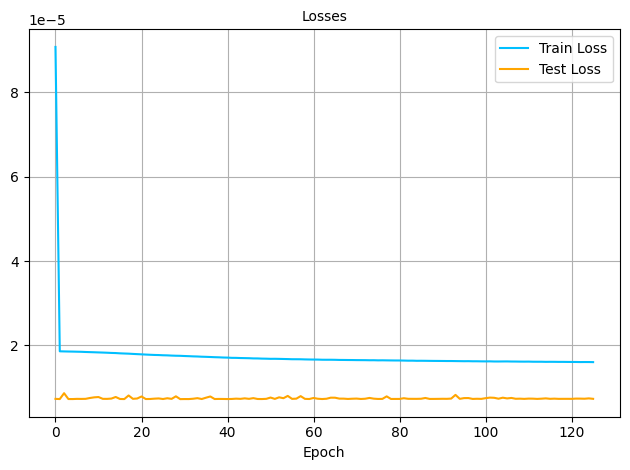

Epoch: 126, train_losses: 1.6040576858002754e-05, test_losses: 7.676103450648952e-06, Duration: 0:00:10.506932


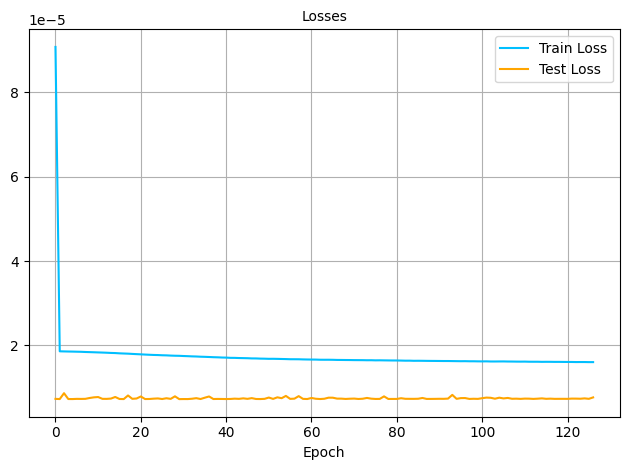

Epoch: 127, train_losses: 1.6020573662393426e-05, test_losses: 7.876667950768024e-06, Duration: 0:00:10.693107


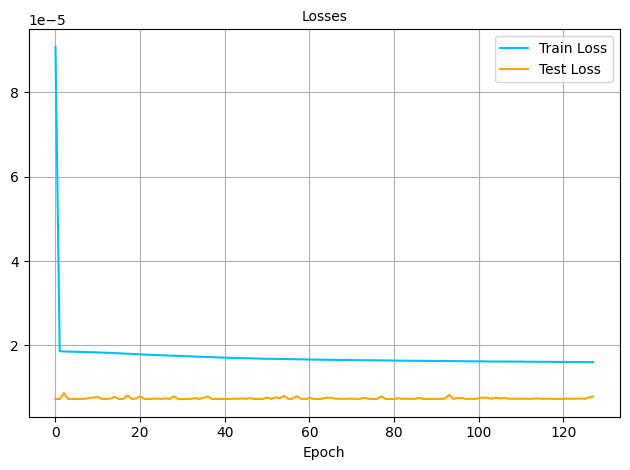

Epoch: 128, train_losses: 1.6014816051622662e-05, test_losses: 7.334511337830918e-06, Duration: 0:00:10.429464


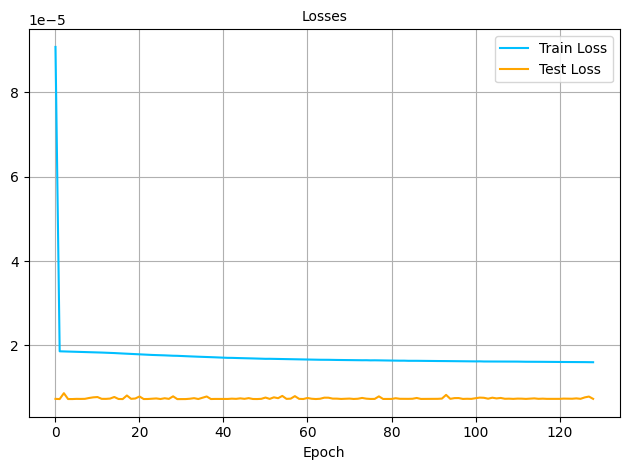

Epoch: 129, train_losses: 1.602270014598697e-05, test_losses: 7.3205023909395095e-06, Duration: 0:00:10.444060


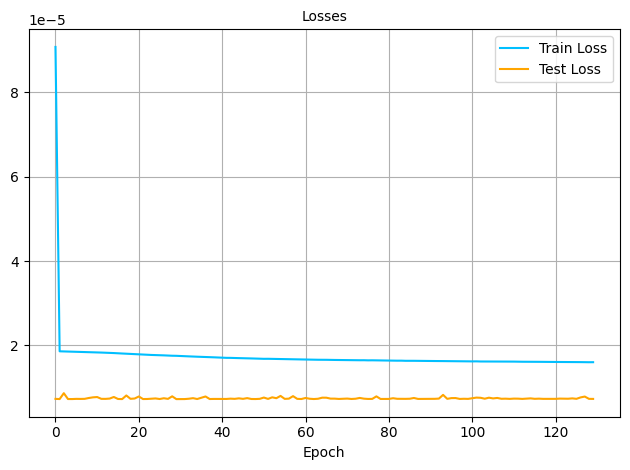

Epoch: 130, train_losses: 1.601799435388933e-05, test_losses: 7.510193427151535e-06, Duration: 0:00:09.667034


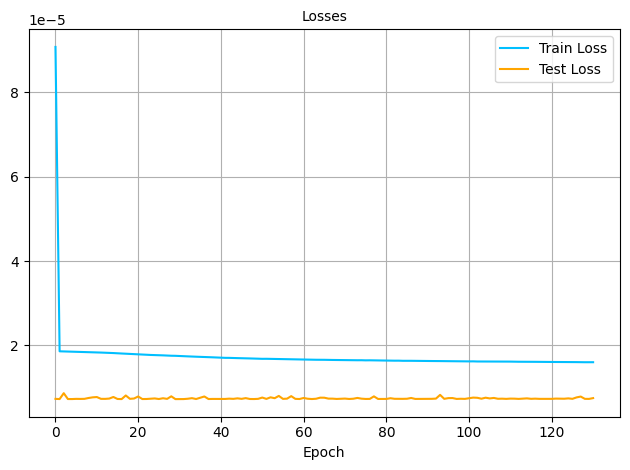

Epoch: 131, train_losses: 1.600303747219383e-05, test_losses: 7.344323421420995e-06, Duration: 0:00:10.688034


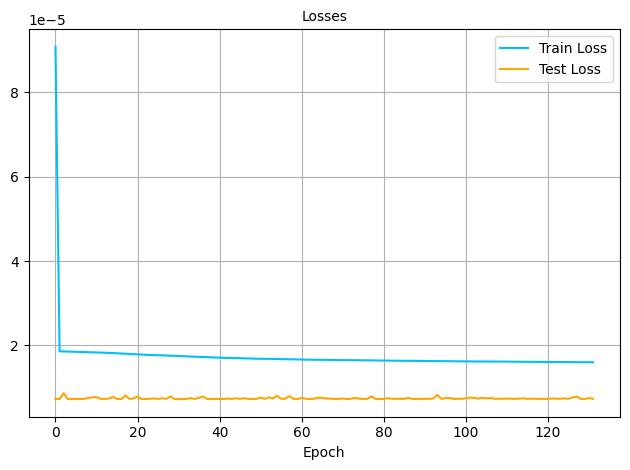

Epoch: 132, train_losses: 1.6008001273999332e-05, test_losses: 7.345952781179221e-06, Duration: 0:00:11.017046


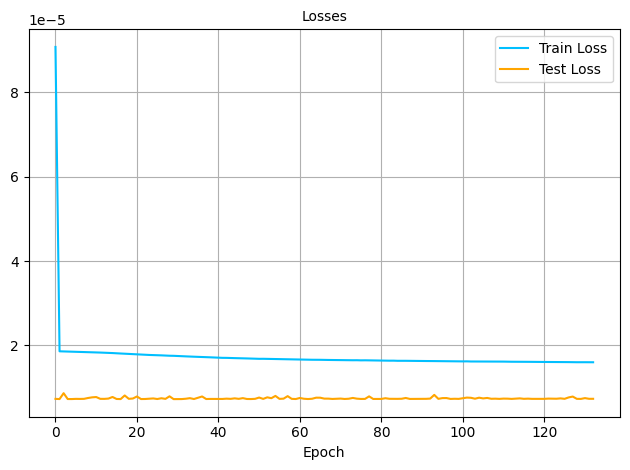

Epoch: 133, train_losses: 1.60042510726052e-05, test_losses: 7.414183528453577e-06, Duration: 0:00:10.706781


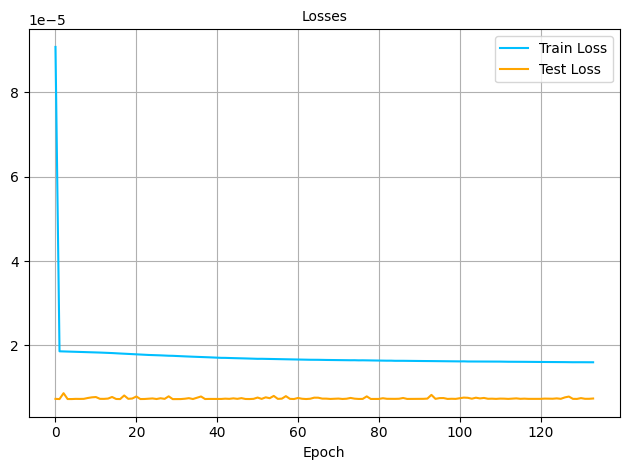

Epoch: 134, train_losses: 1.5980400458418643e-05, test_losses: 7.469230240531033e-06, Duration: 0:00:10.351413


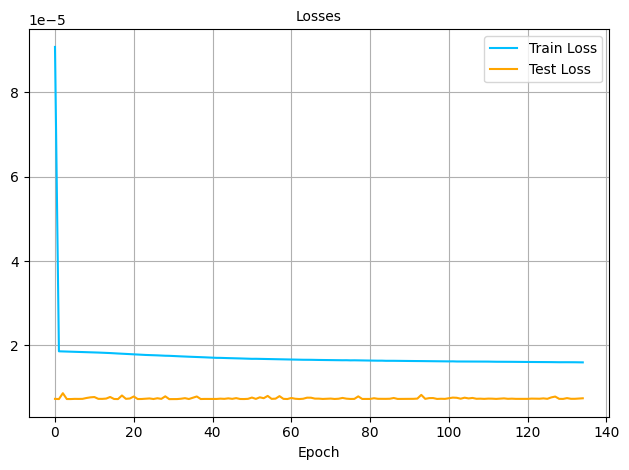

Epoch: 135, train_losses: 1.598860129077284e-05, test_losses: 7.435385668941308e-06, Duration: 0:00:10.447931


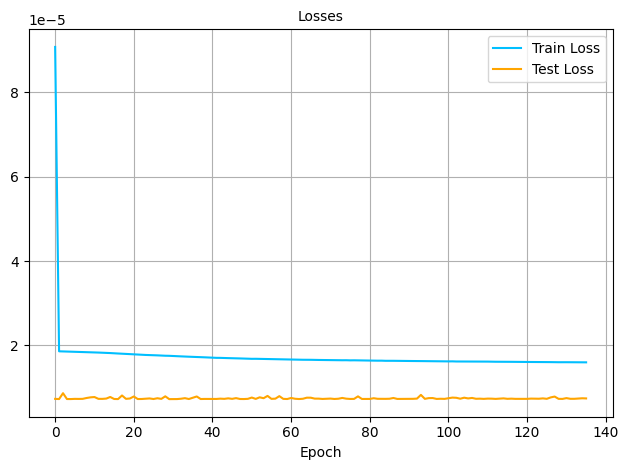

Epoch: 136, train_losses: 1.5973607674626372e-05, test_losses: 7.341966011154e-06, Duration: 0:00:10.033890


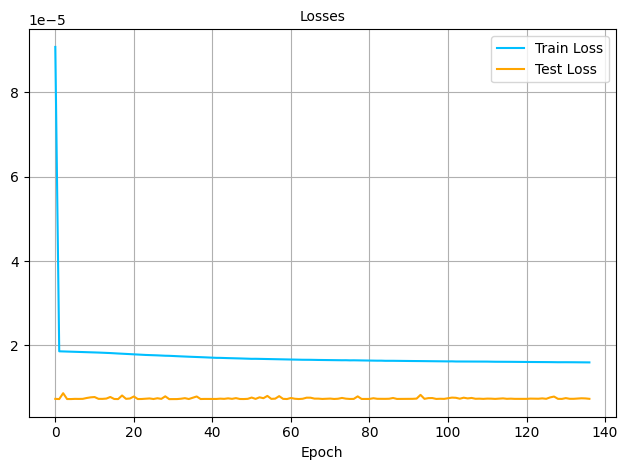

Epoch: 137, train_losses: 1.5966042991386326e-05, test_losses: 7.327377716137562e-06, Duration: 0:00:10.399299


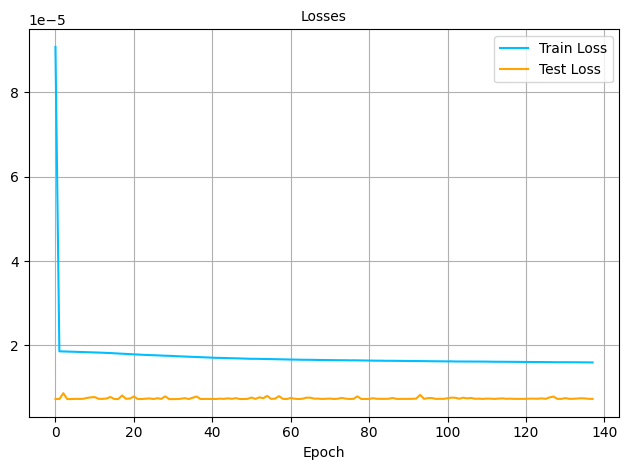

Epoch: 138, train_losses: 1.59742369850913e-05, test_losses: 7.36244464860647e-06, Duration: 0:00:10.603215


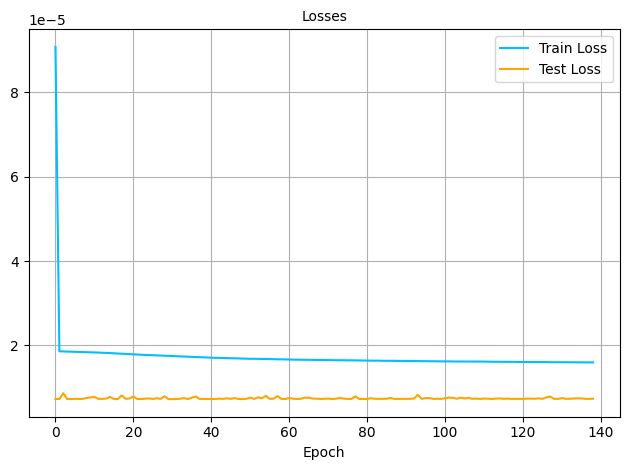

Epoch: 139, train_losses: 1.5954813677562614e-05, test_losses: 7.347641258093063e-06, Duration: 0:00:10.388051


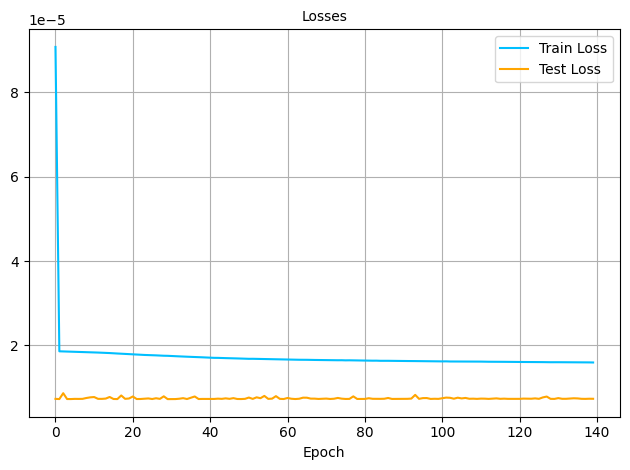

Epoch: 140, train_losses: 1.595676456197091e-05, test_losses: 7.469446245522704e-06, Duration: 0:00:10.246790


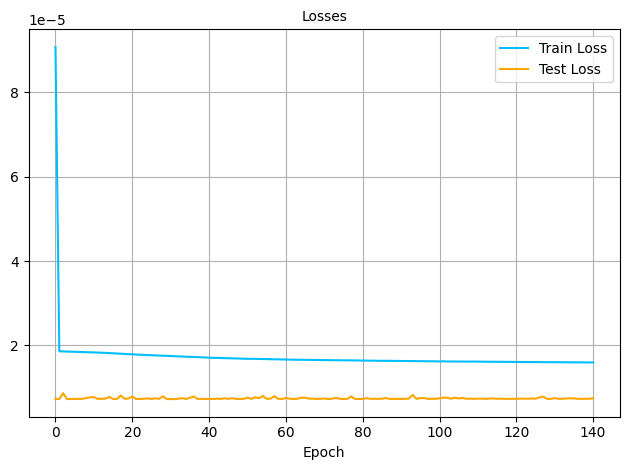

Epoch: 141, train_losses: 1.5946078812456737e-05, test_losses: 7.36439915272058e-06, Duration: 0:00:10.227146


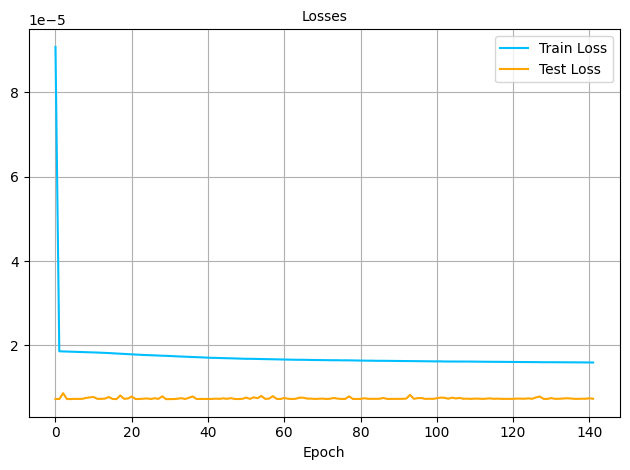

Epoch: 142, train_losses: 1.5952979035542343e-05, test_losses: 7.3986097959277686e-06, Duration: 0:00:09.783405


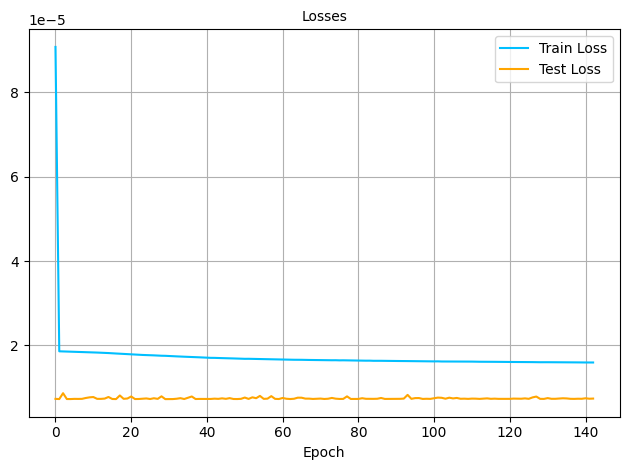

Epoch: 143, train_losses: 1.5951315190458223e-05, test_losses: 7.334528618230252e-06, Duration: 0:00:10.193045


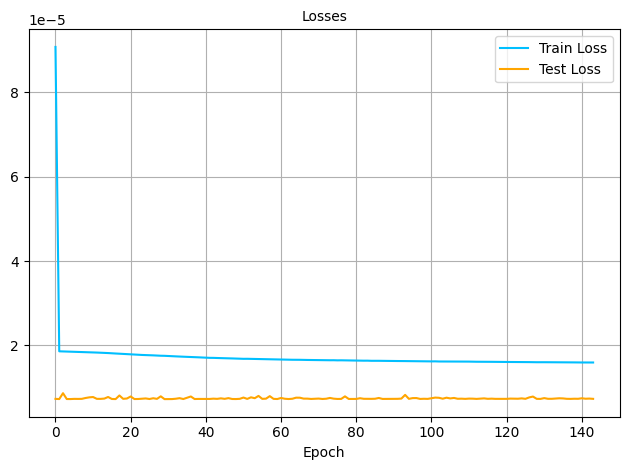

Epoch: 144, train_losses: 1.5945873114525772e-05, test_losses: 7.3955820880655665e-06, Duration: 0:00:10.451530


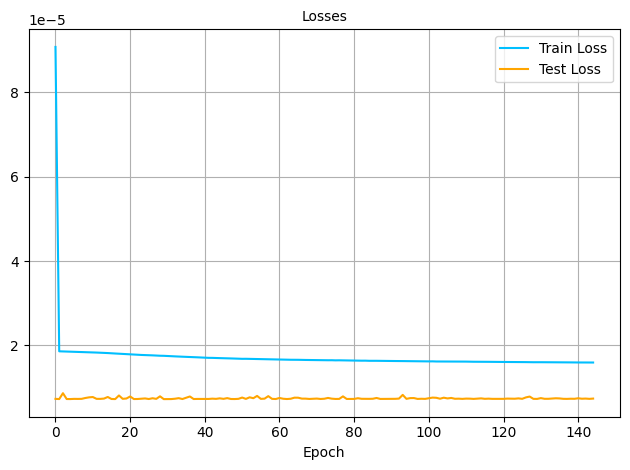

Epoch: 145, train_losses: 1.5927861019455968e-05, test_losses: 7.4889258030452766e-06, Duration: 0:00:10.335298


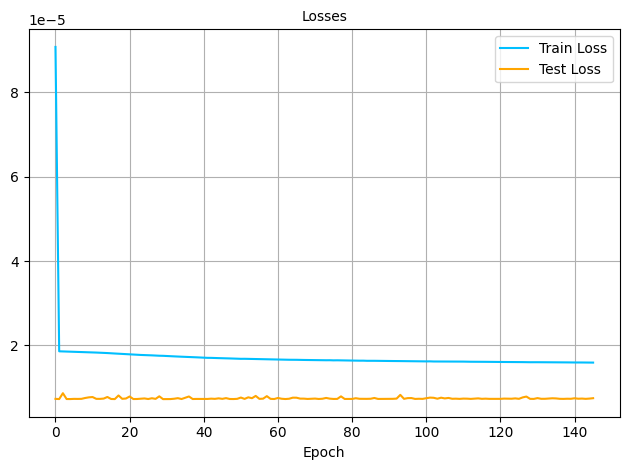

Epoch: 146, train_losses: 1.594343553618894e-05, test_losses: 7.612082754349103e-06, Duration: 0:00:10.747493


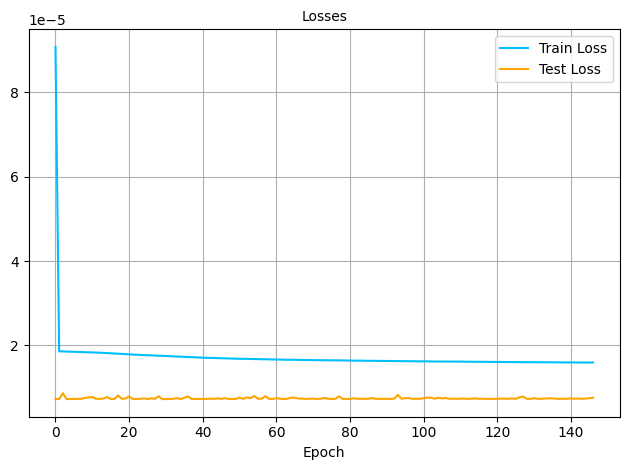

Epoch: 147, train_losses: 1.5921136843858126e-05, test_losses: 7.550124337285524e-06, Duration: 0:00:09.550131


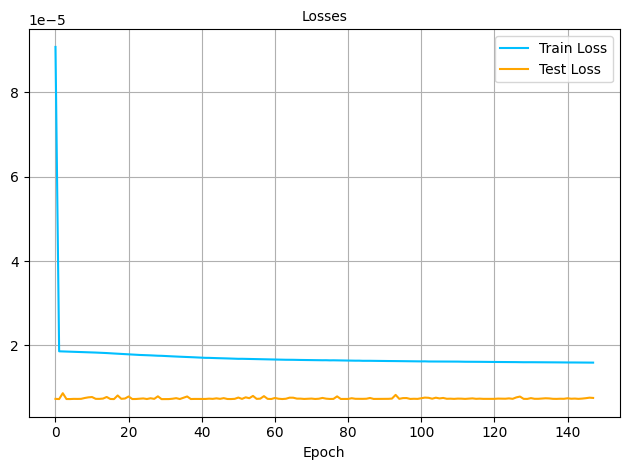

Epoch: 148, train_losses: 1.5922843369774392e-05, test_losses: 7.3716623774089385e-06, Duration: 0:00:10.920845


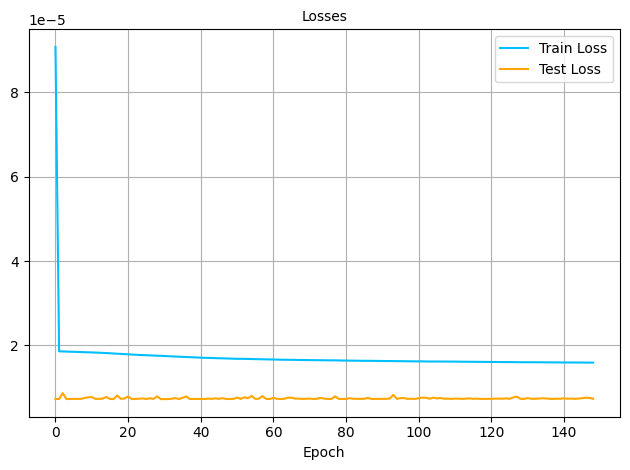

Epoch: 149, train_losses: 1.591658328588187e-05, test_losses: 7.507427653763443e-06, Duration: 0:00:10.827118


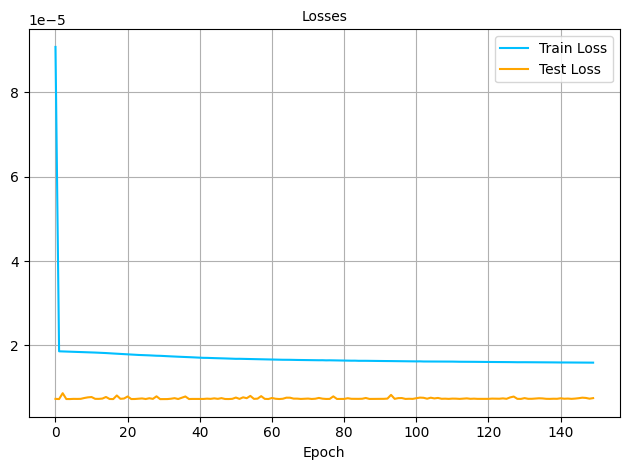

Epoch: 150, train_losses: 1.5912236970867546e-05, test_losses: 7.556669061159482e-06, Duration: 0:00:10.989562


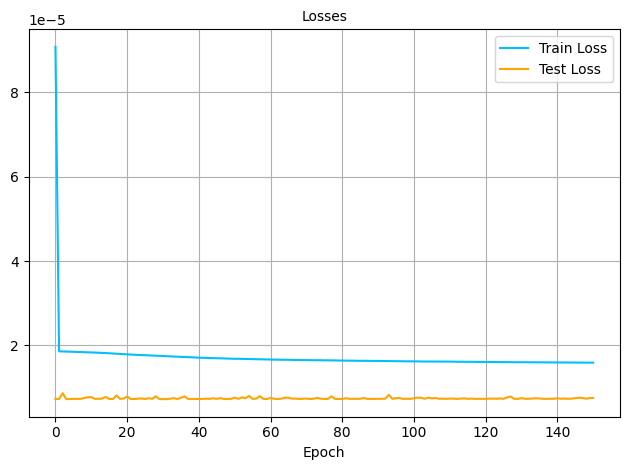

Epoch: 151, train_losses: 1.5926799663962976e-05, test_losses: 7.4085314736294094e-06, Duration: 0:00:10.711356


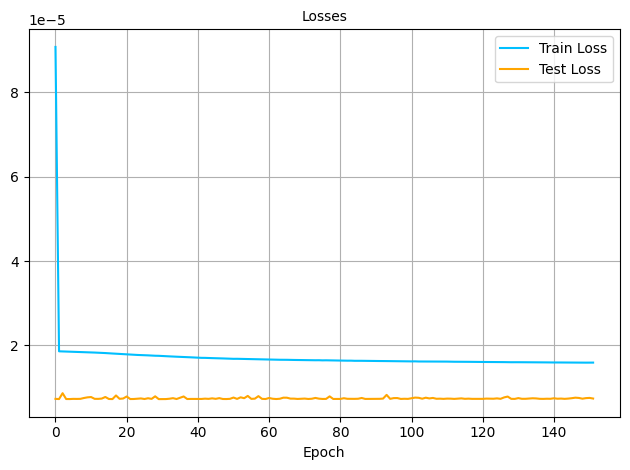

Epoch: 152, train_losses: 1.5897967408524108e-05, test_losses: 7.411213573504938e-06, Duration: 0:00:10.818615


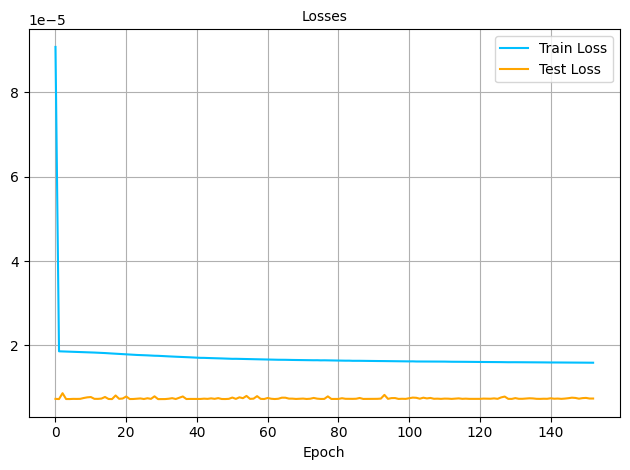

Epoch: 153, train_losses: 1.5892886933103075e-05, test_losses: 7.4234544626961e-06, Duration: 0:00:10.115498


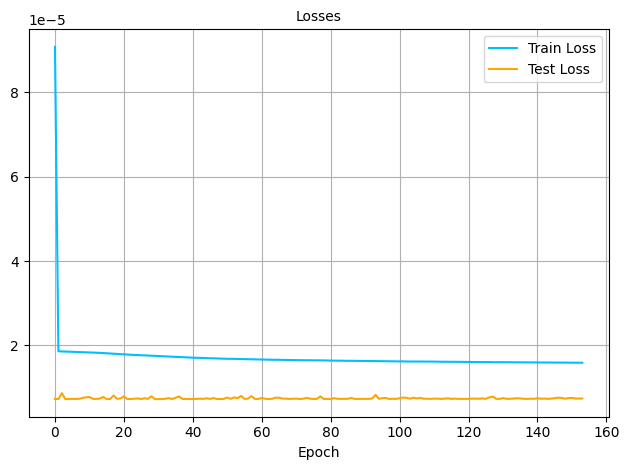

Epoch: 154, train_losses: 1.589153807736668e-05, test_losses: 7.395507964247372e-06, Duration: 0:00:10.058572


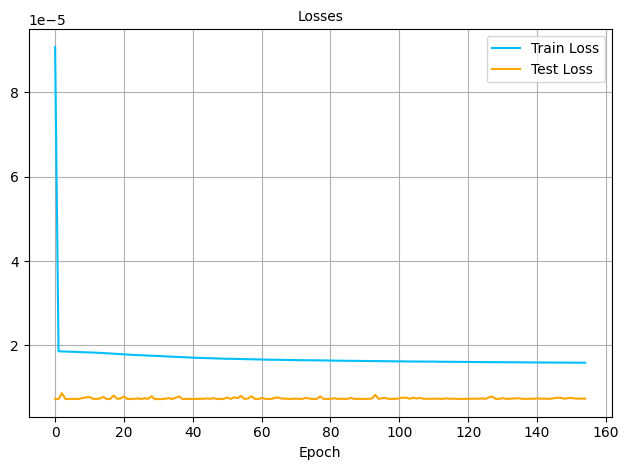

Epoch: 155, train_losses: 1.5897778081679745e-05, test_losses: 7.386975084955338e-06, Duration: 0:00:10.435811


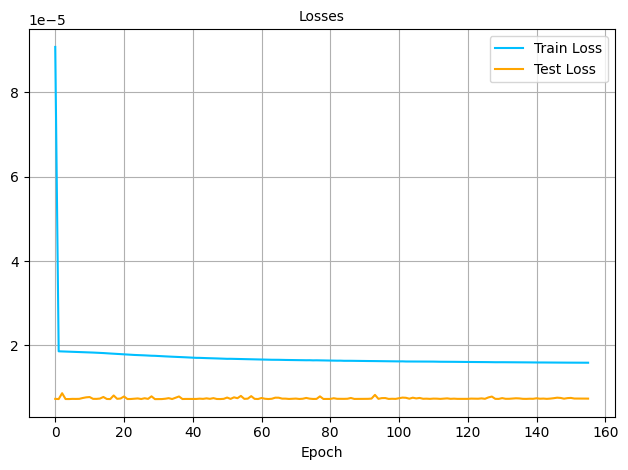

Epoch: 156, train_losses: 1.588605250953892e-05, test_losses: 7.771577656967565e-06, Duration: 0:00:10.444276


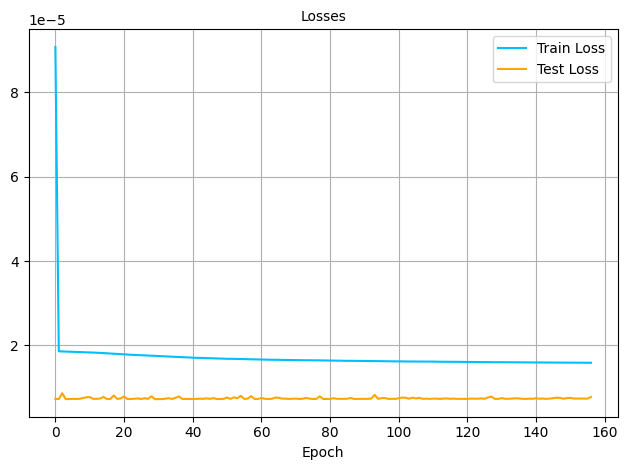

Epoch: 157, train_losses: 1.5884602987572765e-05, test_losses: 7.663439646421466e-06, Duration: 0:00:10.390074


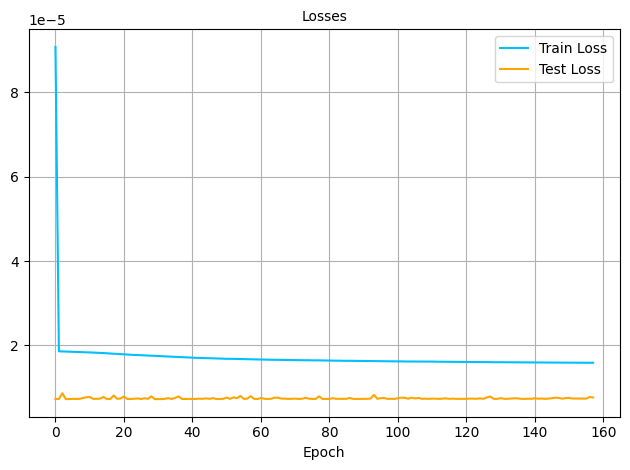

Epoch: 158, train_losses: 1.5881454335537e-05, test_losses: 7.3584965321060736e-06, Duration: 0:00:10.424128


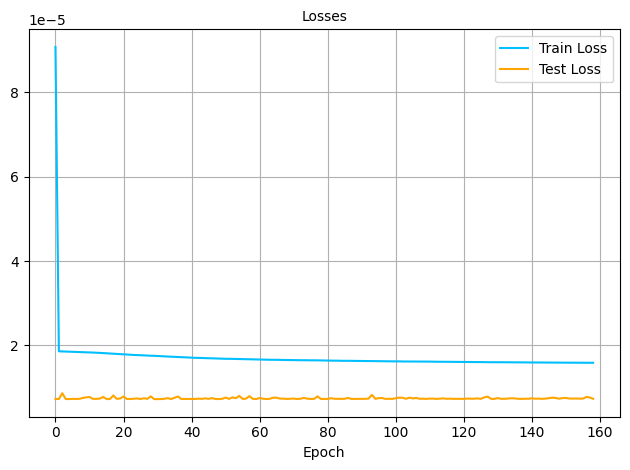

Epoch: 159, train_losses: 1.5877360518064235e-05, test_losses: 7.485007245122688e-06, Duration: 0:00:09.582435


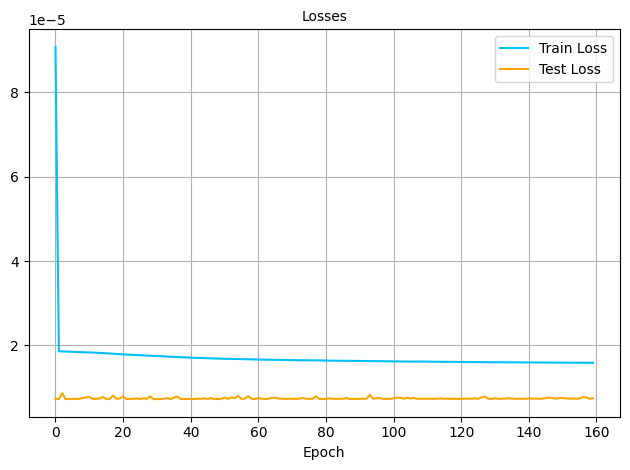

Epoch: 160, train_losses: 1.5874869391103838e-05, test_losses: 7.478896350221476e-06, Duration: 0:00:10.892440


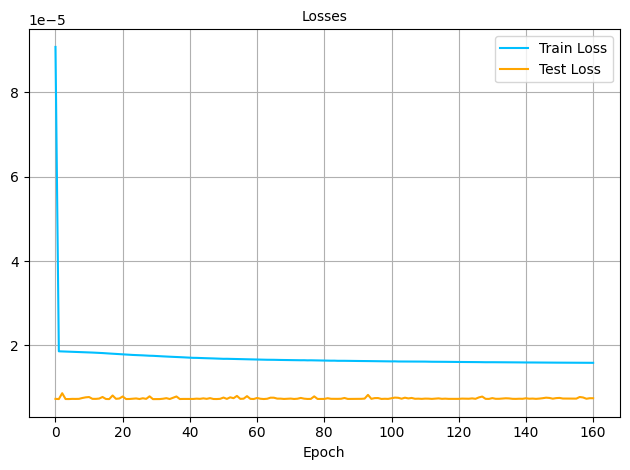

Epoch: 161, train_losses: 1.5876298689732868e-05, test_losses: 7.350323357968591e-06, Duration: 0:00:10.542338


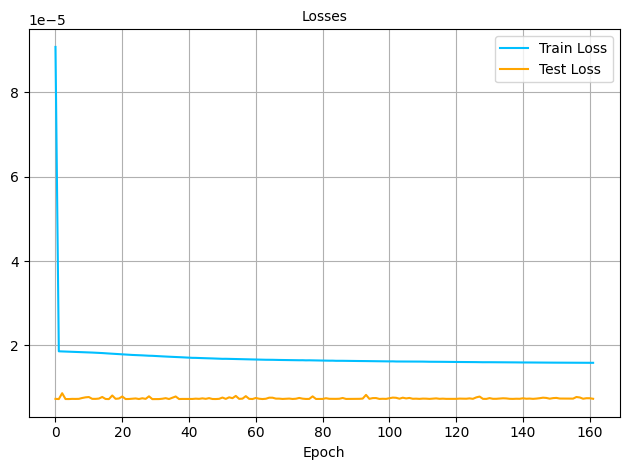

Epoch: 162, train_losses: 1.587489008133492e-05, test_losses: 7.56575809646165e-06, Duration: 0:00:10.356160


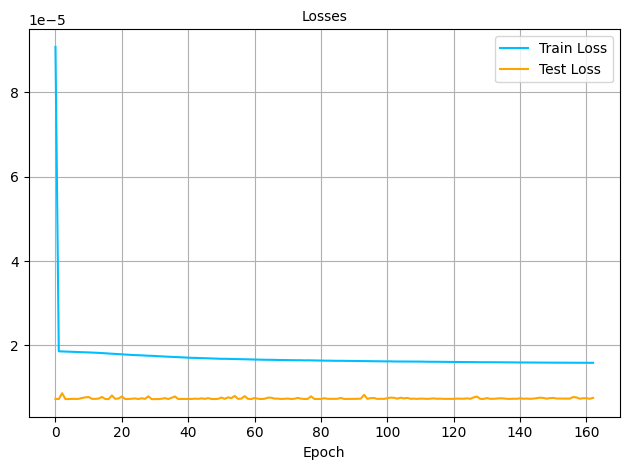

Epoch: 163, train_losses: 1.58805269926841e-05, test_losses: 7.640266630914994e-06, Duration: 0:00:10.529258


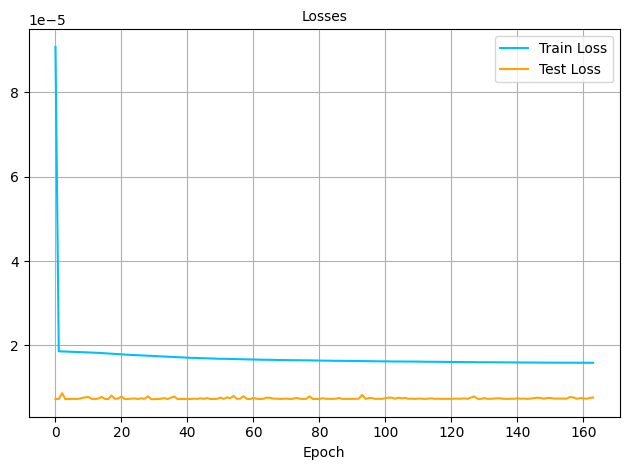

Epoch: 164, train_losses: 1.5863121010914614e-05, test_losses: 7.93952312960755e-06, Duration: 0:00:10.469805


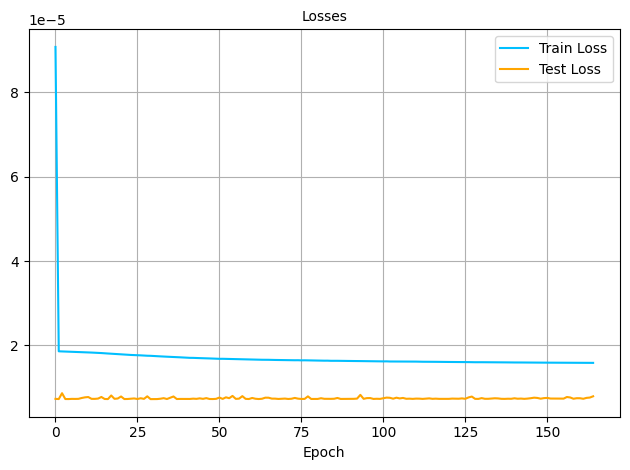

Epoch: 165, train_losses: 1.5849031989031914e-05, test_losses: 7.540887509094318e-06, Duration: 0:00:09.427812


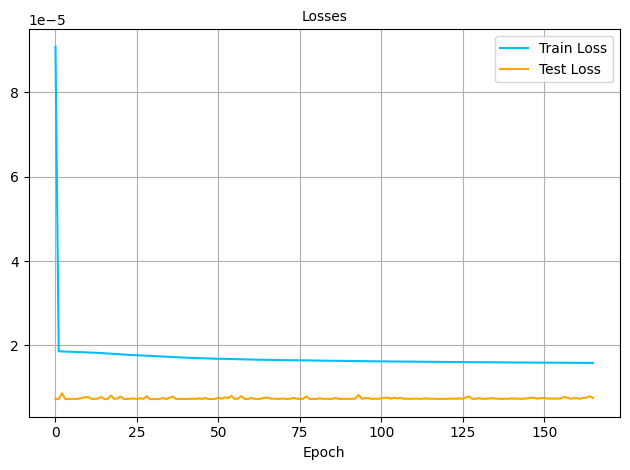

Epoch: 166, train_losses: 1.586035443792758e-05, test_losses: 7.390126029349631e-06, Duration: 0:00:10.336836


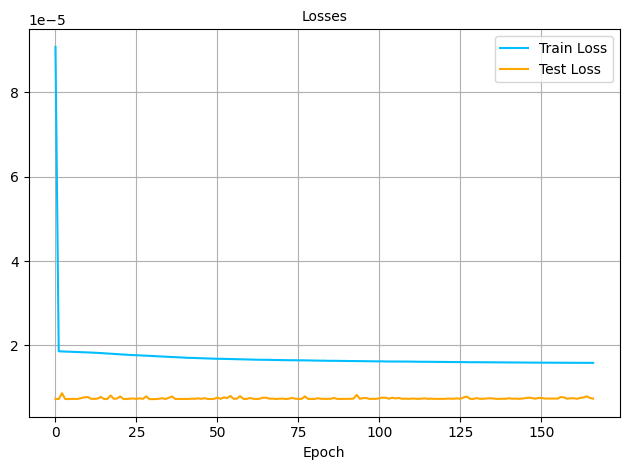

Epoch: 167, train_losses: 1.583976880094679e-05, test_losses: 7.397965873678913e-06, Duration: 0:00:10.274231


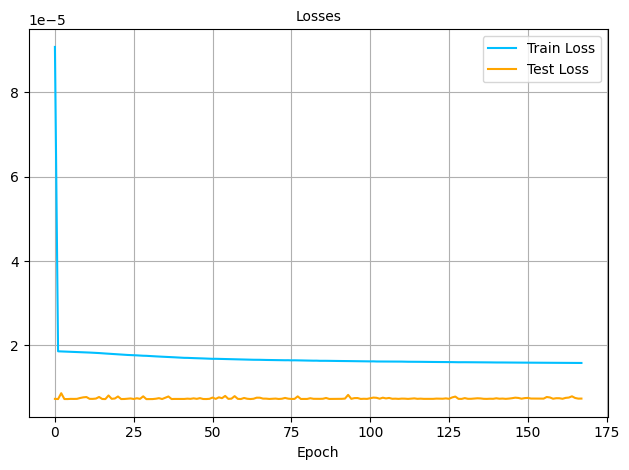

Epoch: 168, train_losses: 1.5845505268392025e-05, test_losses: 7.4547683652781416e-06, Duration: 0:00:10.174068


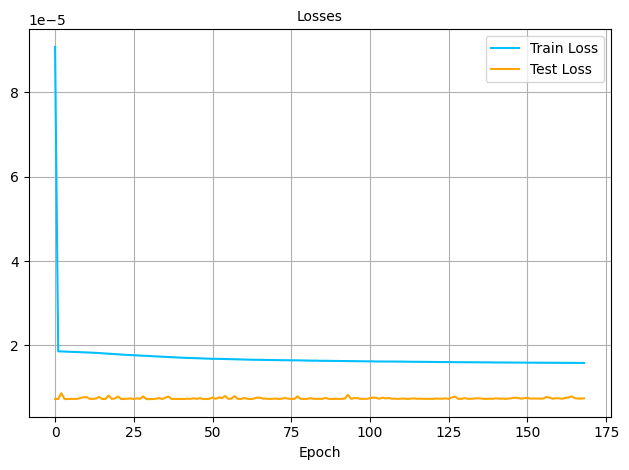

Epoch: 169, train_losses: 1.5836430753099377e-05, test_losses: 7.327954790525837e-06, Duration: 0:00:10.539877


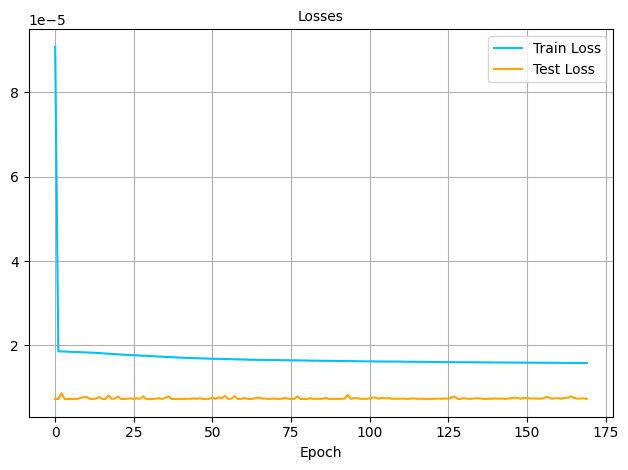

Epoch: 170, train_losses: 1.5848842985520986e-05, test_losses: 7.412700142594986e-06, Duration: 0:00:09.525061


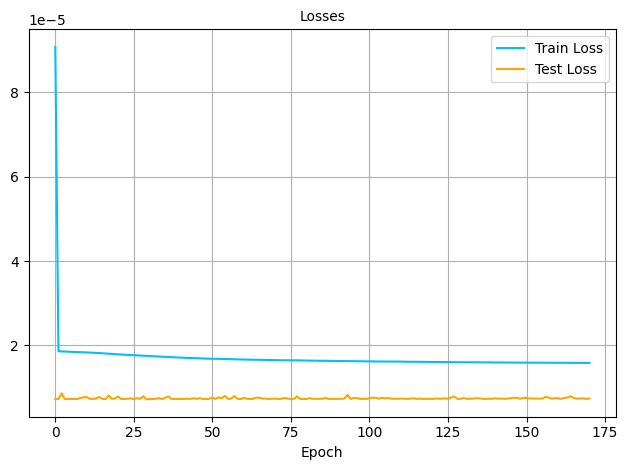

Epoch: 171, train_losses: 1.5832653946786394e-05, test_losses: 7.459986591129564e-06, Duration: 0:00:10.426318


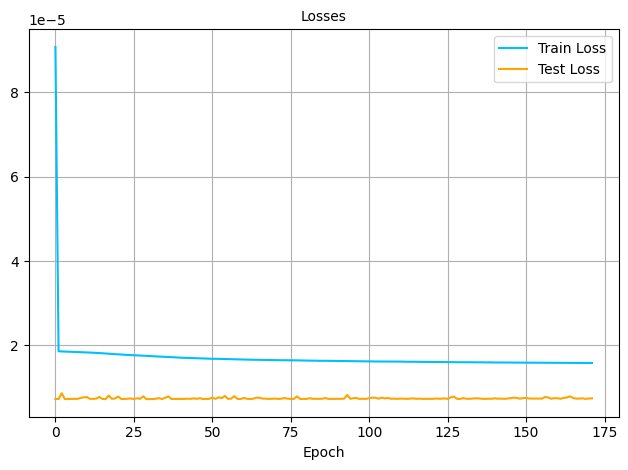

Epoch: 172, train_losses: 1.5831095546721937e-05, test_losses: 7.560442554677138e-06, Duration: 0:00:10.426171


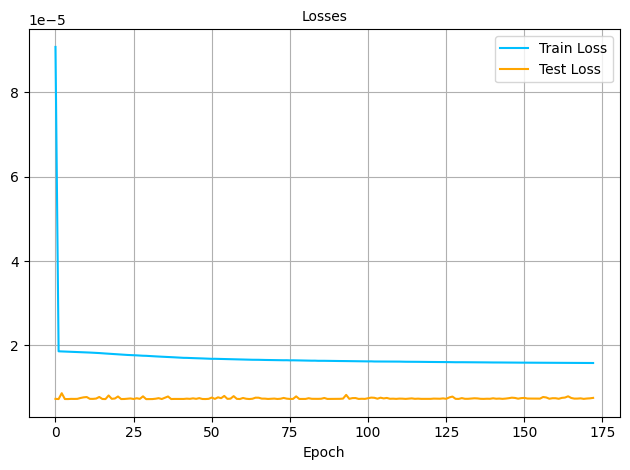

Epoch: 173, train_losses: 1.5823519781418757e-05, test_losses: 7.487174570997013e-06, Duration: 0:00:10.551204


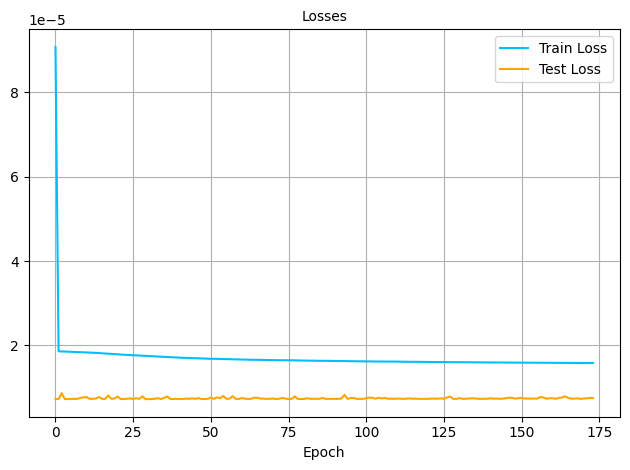

Epoch: 174, train_losses: 1.5823700366417077e-05, test_losses: 7.364118573605083e-06, Duration: 0:00:10.670736


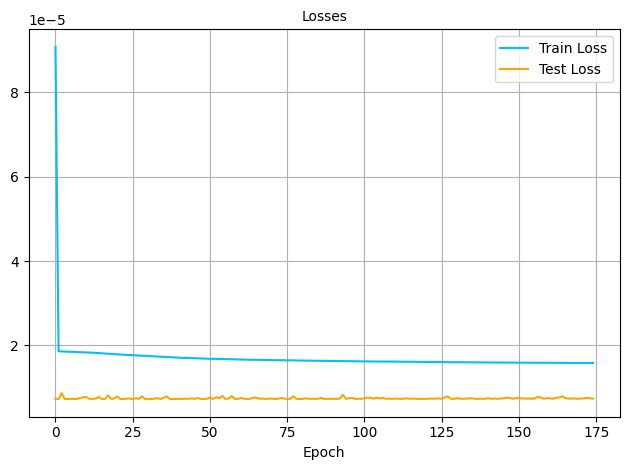

Epoch: 175, train_losses: 1.583314400423487e-05, test_losses: 8.008726581465453e-06, Duration: 0:00:10.505665


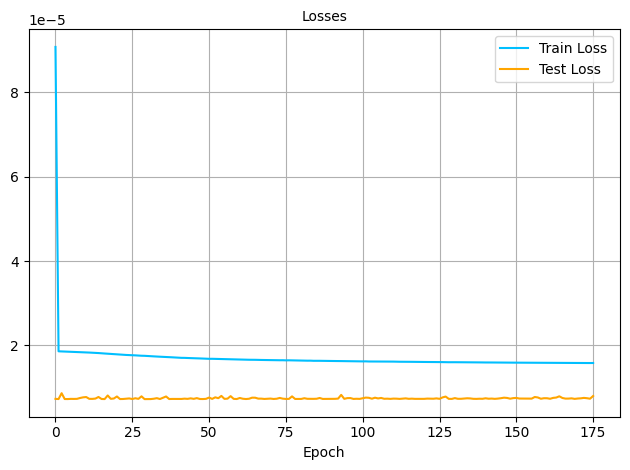

Epoch: 176, train_losses: 1.58091750921228e-05, test_losses: 7.434736289724242e-06, Duration: 0:00:09.918175


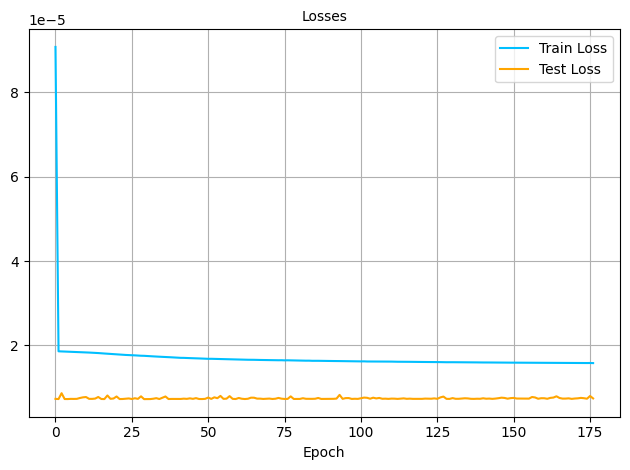

Epoch: 177, train_losses: 1.58300223803842e-05, test_losses: 7.762472705508117e-06, Duration: 0:00:10.270131


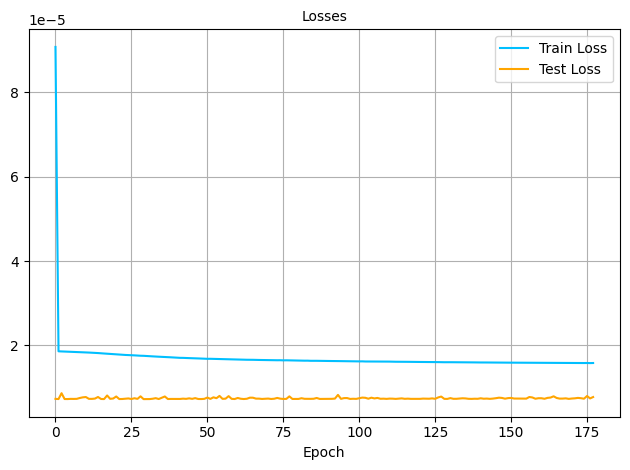

Epoch: 178, train_losses: 1.5789008054961406e-05, test_losses: 7.616717994096689e-06, Duration: 0:00:10.645199


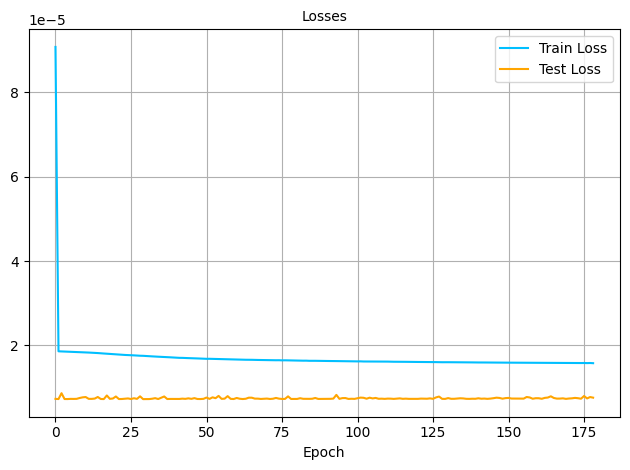

Epoch: 179, train_losses: 1.5806939993016158e-05, test_losses: 7.347175596805755e-06, Duration: 0:00:10.404257


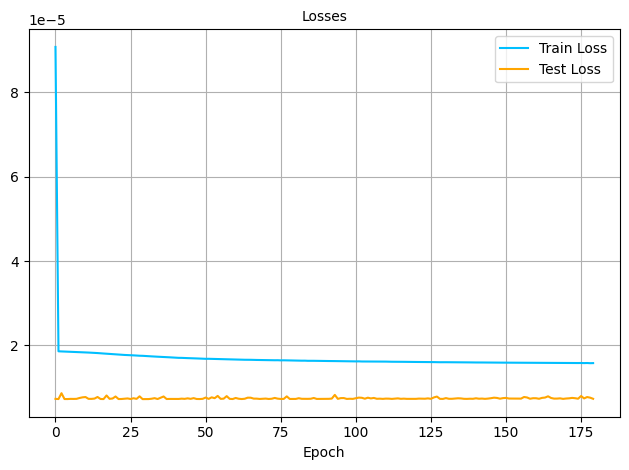

Epoch: 180, train_losses: 1.5795396482877522e-05, test_losses: 7.584045306430198e-06, Duration: 0:00:10.248167


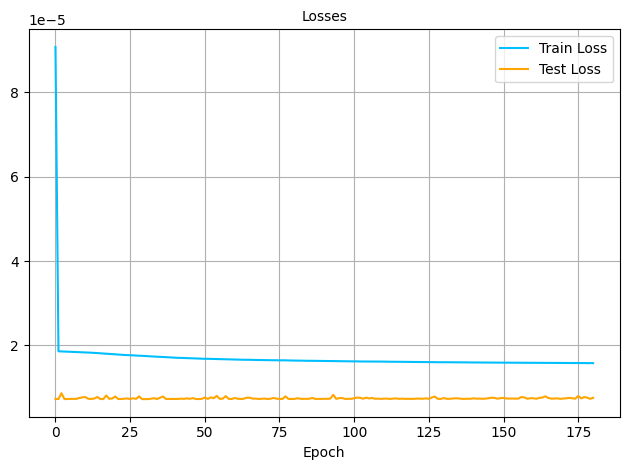

Epoch: 181, train_losses: 1.5803613323087583e-05, test_losses: 7.429185188811971e-06, Duration: 0:00:09.467810


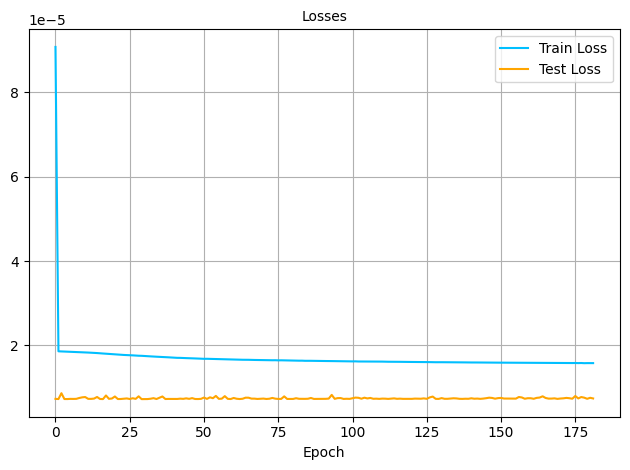

Epoch: 182, train_losses: 1.5803392516635363e-05, test_losses: 7.393885425699409e-06, Duration: 0:00:10.564944


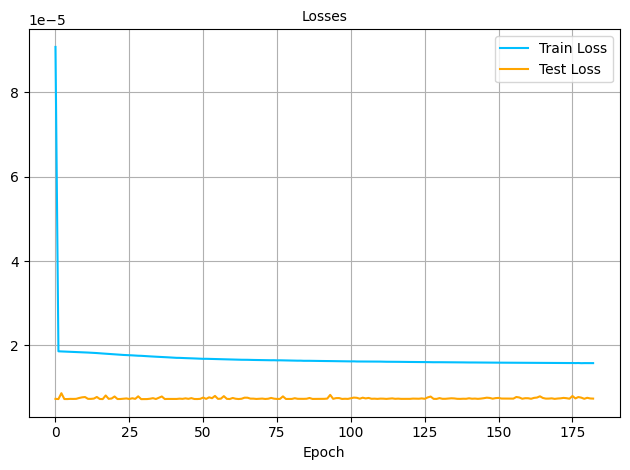

Epoch: 183, train_losses: 1.579775498078954e-05, test_losses: 7.373478183581028e-06, Duration: 0:00:10.647591


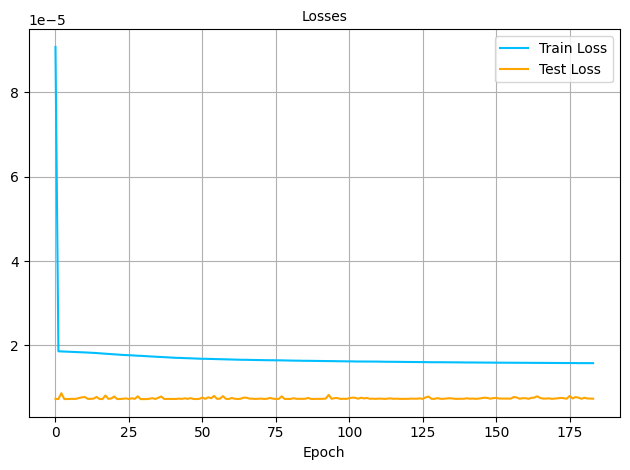

Epoch: 184, train_losses: 1.5785213446657456e-05, test_losses: 7.350585292442702e-06, Duration: 0:00:10.365359


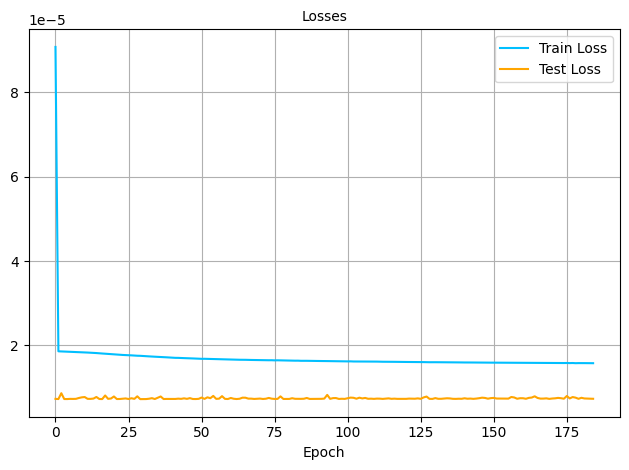

Epoch: 185, train_losses: 1.5768466970210024e-05, test_losses: 7.367070338659687e-06, Duration: 0:00:10.278604


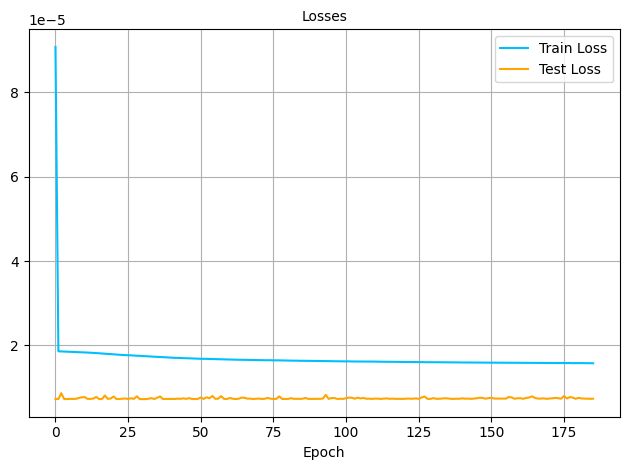

Epoch: 186, train_losses: 1.5790168776374837e-05, test_losses: 7.57792622607667e-06, Duration: 0:00:09.707696


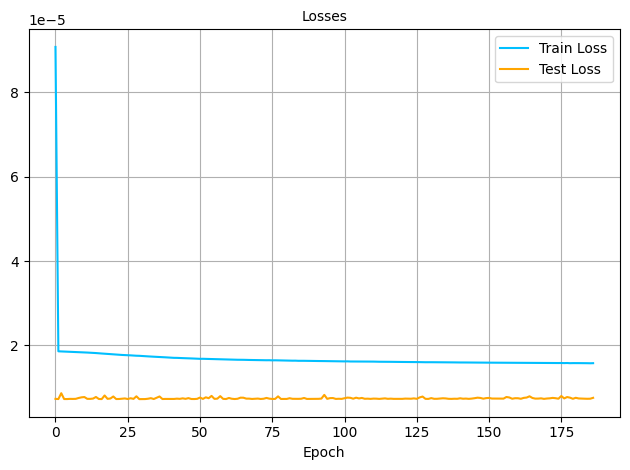

Epoch: 187, train_losses: 1.578121341885445e-05, test_losses: 7.3669921221153345e-06, Duration: 0:00:09.861297


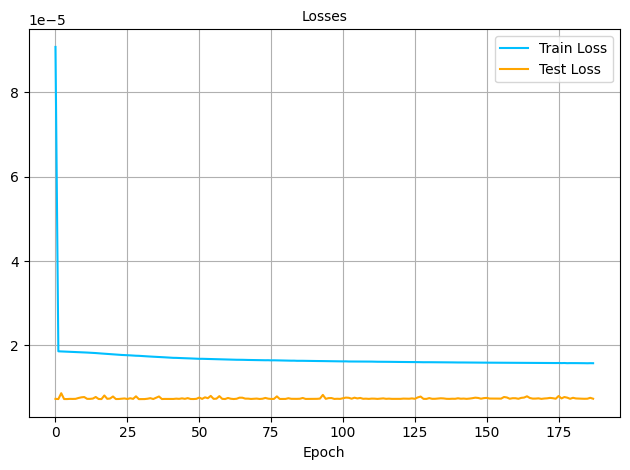

Epoch: 188, train_losses: 1.5765659420935193e-05, test_losses: 7.44217868486885e-06, Duration: 0:00:10.575656


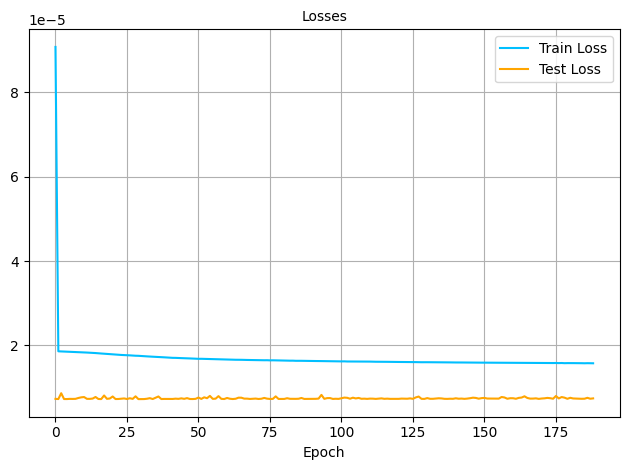

Epoch: 189, train_losses: 1.5764426040181714e-05, test_losses: 7.355512479989557e-06, Duration: 0:00:10.276078


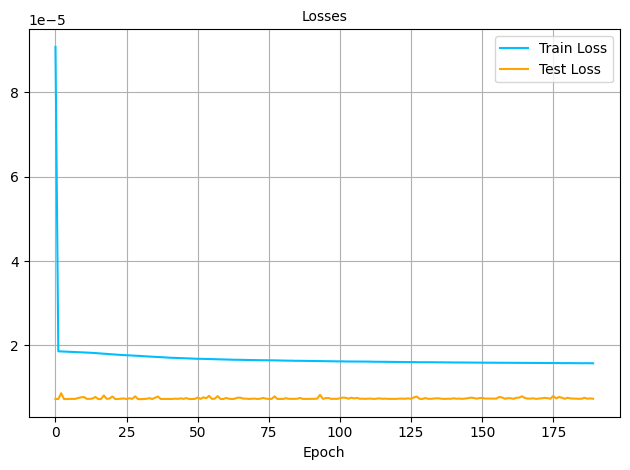

Epoch: 190, train_losses: 1.5762641562535454e-05, test_losses: 7.420165729854489e-06, Duration: 0:00:10.253876


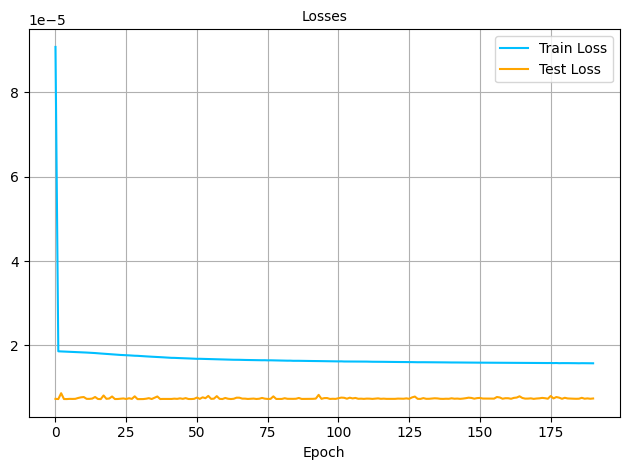

Epoch: 191, train_losses: 1.576839848337557e-05, test_losses: 7.340692718571518e-06, Duration: 0:00:09.880204


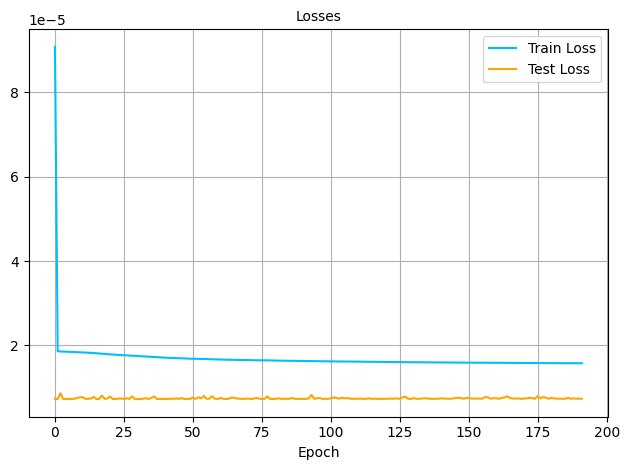

Epoch: 192, train_losses: 1.5747301964799187e-05, test_losses: 7.383437605312793e-06, Duration: 0:00:09.978436


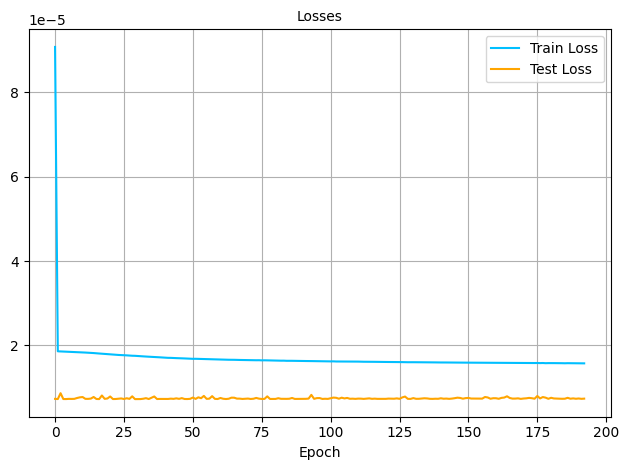

Epoch: 193, train_losses: 1.5747501413047598e-05, test_losses: 7.378618192888098e-06, Duration: 0:00:10.286445


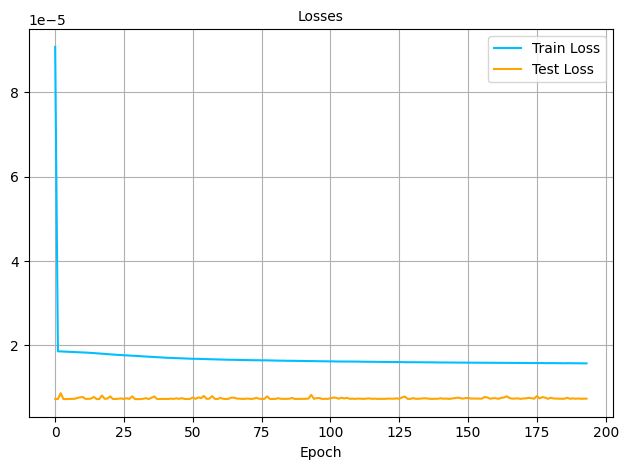

Epoch: 194, train_losses: 1.574598467971717e-05, test_losses: 7.350568012043368e-06, Duration: 0:00:10.585085


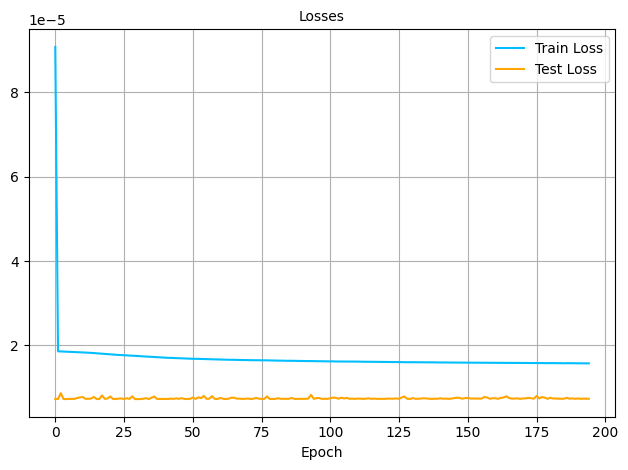

Epoch: 195, train_losses: 1.575260661295229e-05, test_losses: 7.462409939762438e-06, Duration: 0:00:10.307871


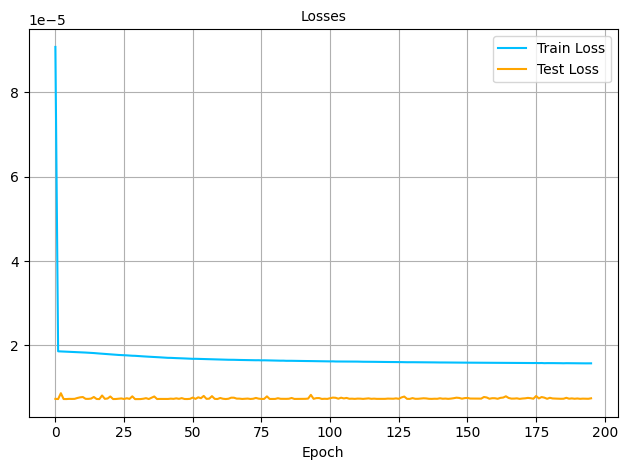

Epoch: 196, train_losses: 1.5729040384623652e-05, test_losses: 7.3807382250379305e-06, Duration: 0:00:10.375529


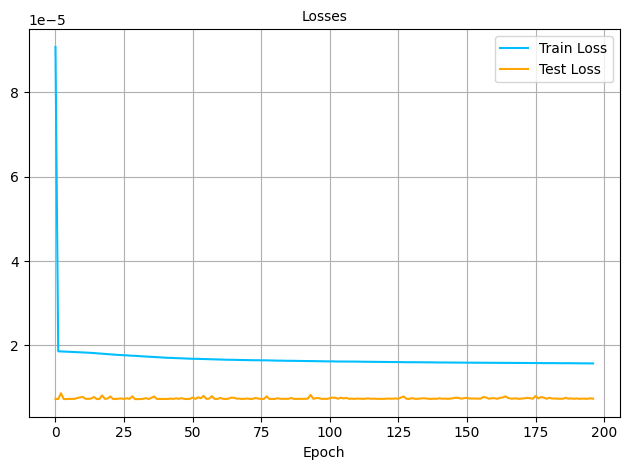

Epoch: 197, train_losses: 1.575161007742693e-05, test_losses: 7.336359885812271e-06, Duration: 0:00:10.052827


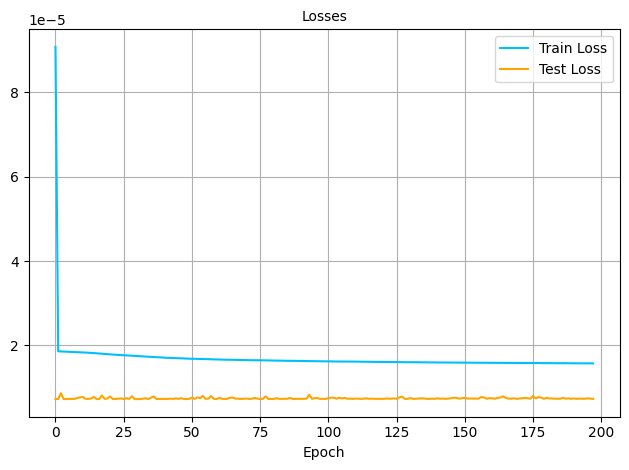

Epoch: 198, train_losses: 1.573908158852965e-05, test_losses: 7.34225341147976e-06, Duration: 0:00:10.660433


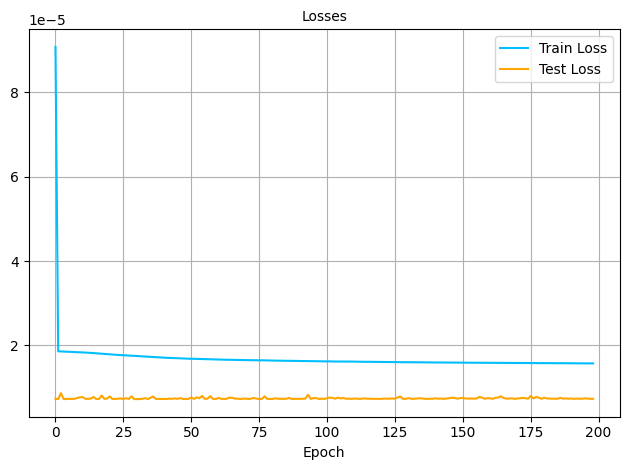

Epoch: 199, train_losses: 1.572670301459989e-05, test_losses: 7.371155788860051e-06, Duration: 0:00:10.663031


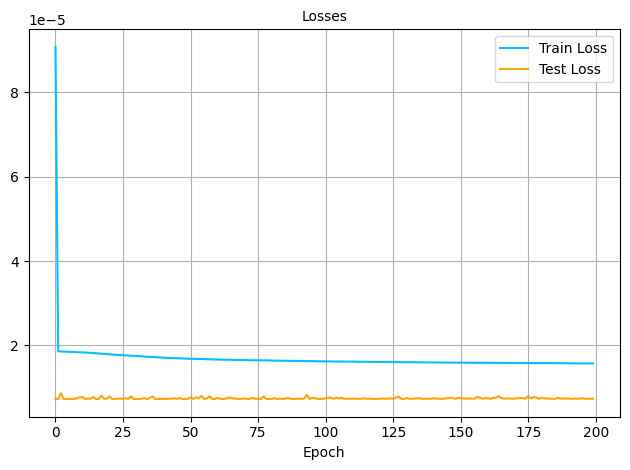

In [16]:
for epoch in range(num_epochs):
    # Track duration
    dt0_epoch = datetime.now()

    # Create mini batches
    mini_batches = create_minibatches(X_train, Y_train, batch_size, shuffle=True)

    train_losses_batch = []

    for X_train_batch, Y_train_batch in mini_batches:
        # Set train mode
        model.train()

        # Reset the gradients
        optimizer.zero_grad()

        # Forward propagation
        Y_hat_train = model(X_train_batch) # Shape: (batch_size, num_features)

        # Calculate loss (train)
        train_loss = criterion(Y_hat_train, Y_train_batch)

        # Backprop
        train_loss.backward()

        # Update optimizer
        optimizer.step()

        # Keep track of training losses
        train_losses_batch.append(train_loss.item())

    # Predict on test data
    with torch.no_grad():

        # Set evaluation mode
        model.eval()

        # Forward propagation
        Y_pred_test = model(X_test)

        # Calculate test loss
        test_loss = criterion(Y_pred_test, Y_test)

    # Convert 'Y_pred_test' to numpy
    Y_pred_test_cpu = Y_pred_test.detach().cpu().numpy()

    train_losses.append(np.mean(train_losses_batch))
    test_losses.append(test_loss.item())

    print(f'Epoch: {epoch}, train_losses: {train_losses[-1]}, test_losses: {test_losses[-1]}, Duration: {datetime.now() - dt0_epoch}')

    # Plot Train Loss and Test Loss
    plt.title(f"Losses", fontsize=10)
    plt.plot(train_losses, label="Train Loss", color='deepskyblue')
    plt.plot(test_losses, label="Test Loss", color='orange')
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()
    # Display
    plt.tight_layout()
    plt.show()
    plt.close()